In [92]:
# Set to True to output analysis summaries, False to skip
SHOW_SUMMARY = False

# Datasource
https://docs.google.com/document/d/1B3Itxfko-DzyzQlF4_Qc73aSTrcPyLpaySRRyD7-EY0/edit?tab=t.0

- Github URL: https://github.com/darknet-doll/BKS_survey

# Import

In [93]:
import re
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator
from scipy.stats import kruskal, mannwhitneyu, pointbiserialr

# pd.set_option("display.max_colwidth", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)

# Expand display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [94]:
df = pd.read_csv("../database/cgl_BKS_data.csv")
df = df.drop(columns='role_Nazis')
pd.set_option("display.max_info_columns", df.shape[1])

## Review Schema

# CGL Personality

In [95]:
df['cgl'].value_counts(dropna=False)

cgl
NaN    11363
0.0     1295
1.0      744
3.0      606
2.0      597
4.0      488
5.0      410
Name: count, dtype: int64

## CGL Sample Size

In [96]:
# Replace CGL NaN values with 0 and create a boolean flag for CGL presence.
df['cgl'] = df['cgl']

df['cgl_flag'] = np.where(
    df['cgl'] >= 1, True,
    np.where(df['cgl'] == 0, False, "Unknown")
)
# Extracting DF for CGL and non-CGL records.
cgl_df = df[df['cgl_flag'] == "True"]
non_cgl_df = df[df['cgl_flag'] == "False"]

In [97]:
cgl_count = cgl_df.shape[0]
non_cgl_count = non_cgl_df.shape[0]
unknown_count = (df['cgl_flag'] == 'Unknown').sum()

print(
    "Total records: ",
    df.shape[0],
    "\nTotal CGL positive records (True): ", 
    cgl_count,
    f'({cgl_count/df.shape[0]*100:.2f}%)',
    "\nTotal CGL negative records (False): ",
    non_cgl_count,
    f'({non_cgl_count/df.shape[0]*100:.2f}%)',
    "\nTotal records with unknown CGL data: ",
    unknown_count,
    f'({unknown_count/df.shape[0]*100:.2f}%)',
)


Total records:  15503 
Total CGL positive records (True):  2845 (18.35%) 
Total CGL negative records (False):  1295 (8.35%) 
Total records with unknown CGL data:  11363 (73.30%)


In [98]:
df.ds_preference.value_counts(dropna=False)
cgl_df.diagnosis.value_counts(dropna=False)

diagnosis
NaN                                 1873
Anxiety                              218
Depression                           167
ADHD                                 153
Social anxiety                       109
Body Dysmorphia                       51
Autism                                44
OCD                                   33
Borderline                            23
C-PTSD                                23
PTSD                                  22
Bipolar I                             21
Anorexia                              17
Bipolar II                            17
Substance Abuse Disorder              16
Sociopathy                            16
Disassociative Identity Disorder      14
Bulimia                               11
Depersonalization/derealization       10
Schizophrenia                          7
Name: count, dtype: int64

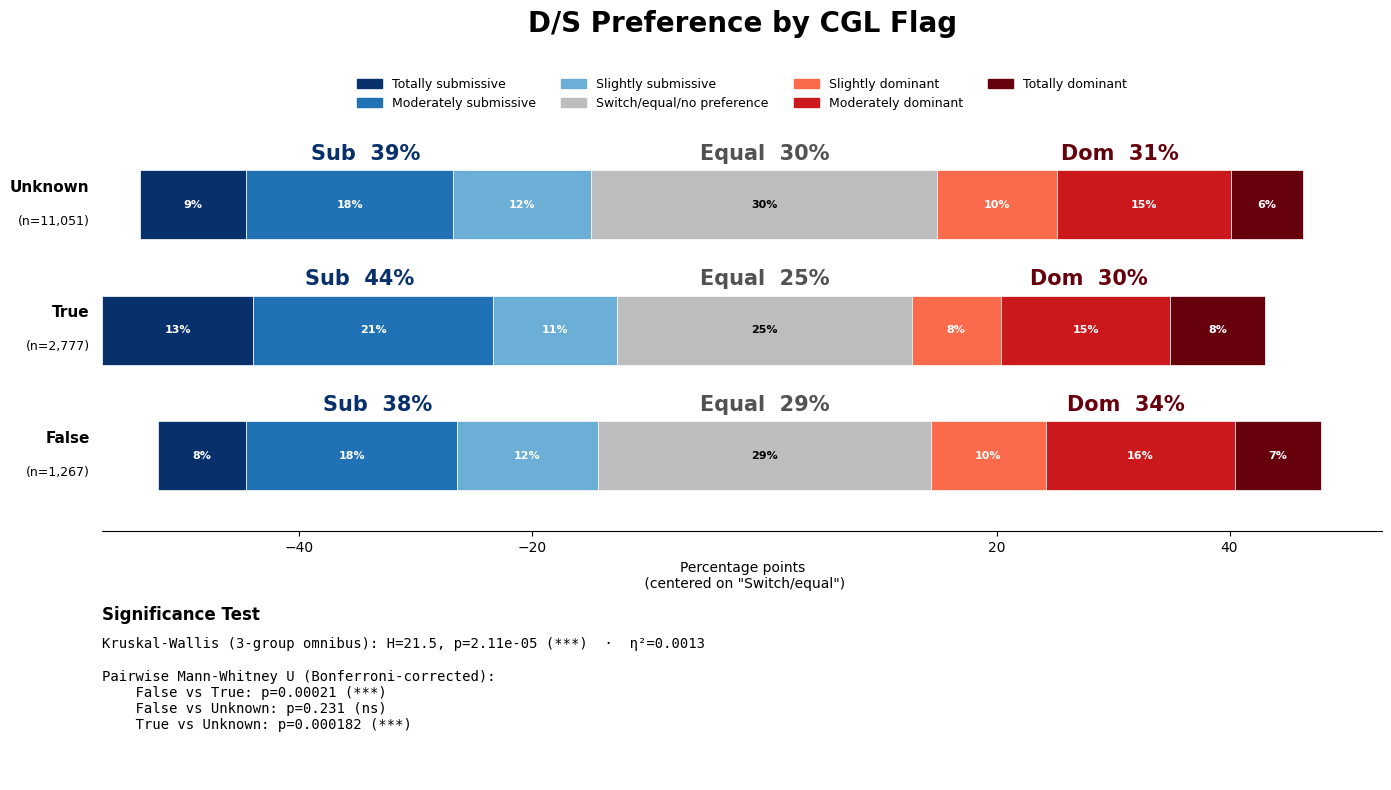

In [99]:
ds_order = [
    'Totally submissive',
    'Moderately submissive',
    'Slightly submissive',
    'Switch/equal/no preference',
    'Slightly dominant',
    'Moderately dominant',
    'Totally dominant',
]
ds_rank = {cat: i + 1 for i, cat in enumerate(ds_order)}

ds_colors = [
    '#08306b', '#2171b5', '#6baed6',
    '#bdbdbd',
    '#fb6a4a', '#cb181d', '#67000d',
]
color_map = dict(zip(ds_order, ds_colors))

plot_df = df.copy()
plot_df['cgl_flag'] = plot_df['cgl_flag'].astype(str)
plot_df = plot_df.dropna(subset=['ds_preference'])

flag_order = ['False', 'True', 'Unknown']
n_per_flag = plot_df['cgl_flag'].value_counts()

pivot = (
    pd.crosstab(plot_df['cgl_flag'], plot_df['ds_preference'], normalize='index')
    .mul(100)
    .reindex(index=flag_order, columns=ds_order, fill_value=0)
)

switch_idx = ds_order.index('Switch/equal/no preference')

fig, (ax_chart, ax_stats) = plt.subplots(
    2, 1, figsize=(14, 8),
    gridspec_kw={'height_ratios': [3, 1.3]},
)

# --- Diverging Likert chart ---
bar_height = 0.55
y_pos = np.arange(len(flag_order))

for row_i, flag in enumerate(flag_order):
    row = pivot.loc[flag]
    sub_total = row.iloc[:switch_idx].sum()
    equal_total = row.iloc[switch_idx]
    dom_total = row.iloc[switch_idx + 1:].sum()

    left_edge = -equal_total / 2 - sub_total
    cursor = left_edge
    for cat in ds_order:
        width = row[cat]
        ax_chart.barh(
            row_i, width, left=cursor, height=bar_height,
            color=color_map[cat], edgecolor='white', linewidth=0.5,
        )
        if width > 3:
            ax_chart.text(
                cursor + width / 2, row_i, f'{width:.0f}%',
                ha='center', va='center',
                fontsize=8, fontweight='bold',
                color='white' if cat != 'Switch/equal/no preference' else 'black',
            )
        cursor += width

    sub_center = -equal_total / 2 - sub_total / 2
    equal_center = 0
    dom_center = equal_total / 2 + dom_total / 2
    label_y = row_i + bar_height / 2 + 0.05

    ax_chart.text(sub_center, label_y, f'Sub  {sub_total:.0f}%',
                  ha='center', va='bottom',
                  fontsize=15, fontweight='bold', color='#08306b')
    ax_chart.text(equal_center, label_y, f'Equal  {equal_total:.0f}%',
                  ha='center', va='bottom',
                  fontsize=15, fontweight='bold', color='#525252')
    ax_chart.text(dom_center, label_y, f'Dom  {dom_total:.0f}%',
                  ha='center', va='bottom',
                  fontsize=15, fontweight='bold', color='#67000d')

# Y-axis: hide default tick labels, manually place bold flag + regular (n=)
ax_chart.set_yticks(y_pos)
ax_chart.set_yticklabels([])
ax_chart.tick_params(axis='y', length=0)
ax_chart.set_ylim(-0.6, len(flag_order) - 0.4)

trans = ax_chart.get_yaxis_transform()
for i, flag in enumerate(flag_order):
    n = int(n_per_flag.get(flag, 0))
    ax_chart.text(-0.01, i + 0.08, flag,
                  transform=trans,
                  ha='right', va='bottom',
                  fontsize=11, fontweight='bold')
    ax_chart.text(-0.01, i - 0.08, f'(n={n:,})',
                  transform=trans,
                  ha='right', va='top',
                  fontsize=9, fontweight='normal')

# X-axis: remove the 0 tick mark/label
existing_ticks = ax_chart.get_xticks()
filtered_ticks = [t for t in existing_ticks if t != 0]
ax_chart.xaxis.set_major_locator(FixedLocator(filtered_ticks))

ax_chart.set_xlabel('Percentage points\n (centered on "Switch/equal")')
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
ax_chart.spines['left'].set_visible(False)

ax_chart.set_title(
    'D/S Preference by CGL Flag',
    fontsize=20, fontweight='bold', loc='center', pad=70
)

legend_handles = [Patch(color=ds_colors[i], label=ds_order[i]) for i in range(len(ds_order))]
ax_chart.legend(
    handles=legend_handles,
    bbox_to_anchor=(0.5, 1.02), loc='lower center',
    ncol=4, frameon=False, fontsize=9,
)

# --- Stats panel ---
def sig_marker(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def eta_squared_kw(h, k, n):
    return max(0.0, (h - k + 1) / (n - k)) if n > k else 0.0

plot_df['ds_rank'] = plot_df['ds_preference'].map(ds_rank)
groups = {f: plot_df.loc[plot_df['cgl_flag'] == f, 'ds_rank'].values for f in flag_order}
groups = {f: g for f, g in groups.items() if len(g) > 0}

stat, p_kw = kruskal(*groups.values())
n_total = sum(len(g) for g in groups.values())
eta = eta_squared_kw(stat, len(groups), n_total)

stat_lines = [
    f'Kruskal-Wallis (3-group omnibus): H={stat:.1f}, p={p_kw:.3g} ({sig_marker(p_kw)})  ·  η²={eta:.4f}',
    '\nPairwise Mann-Whitney U (Bonferroni-corrected):',
]
pairs = list(combinations(groups.keys(), 2))
for f1, f2 in pairs:
    _, p_pair = mannwhitneyu(groups[f1], groups[f2], alternative='two-sided')
    p_adj = min(p_pair * len(pairs), 1.0)
    stat_lines.append(f'    {f1} vs {f2}: p={p_adj:.3g} ({sig_marker(p_adj)})')

ax_stats.axis('off')
ax_stats.text(
    0.0, 1.0, 'Significance Test',
    transform=ax_stats.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold',
)
ax_stats.text(
    0.0, 0.82, '\n'.join(stat_lines),
    transform=ax_stats.transAxes,
    ha='left', va='top',
    family='monospace', fontsize=10,
)

plt.tight_layout()
plt.show()


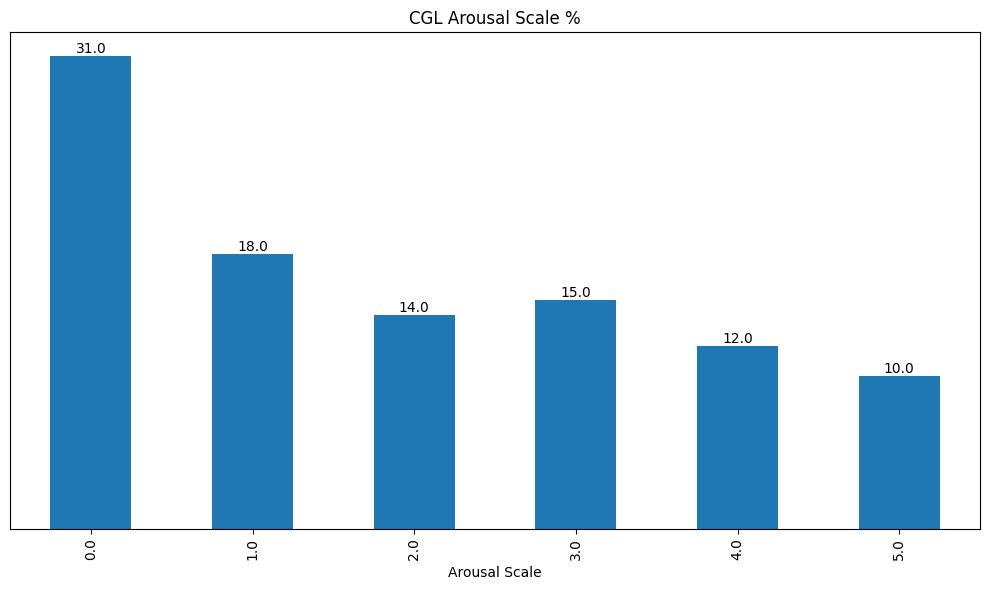

In [100]:
# Review CGL Arousal Scale distribution.
# df[df.cgl_flag==True]['cgl'].value_counts(normalize=True).round(2)*100

ax=(df["cgl"].value_counts(normalize=True).round(2) * 100).sort_index().plot(
    kind="bar", figsize=(10, 6), title="CGL Value Distribution"
)
# Formatting
ax.bar_label(ax.containers[0], fmt='%.1f')  # Add value labels
ax.get_yaxis().set_visible(False)
plt.xlabel("Arousal Scale")
plt.title("CGL Arousal Scale %")
plt.tight_layout()
plt.show()

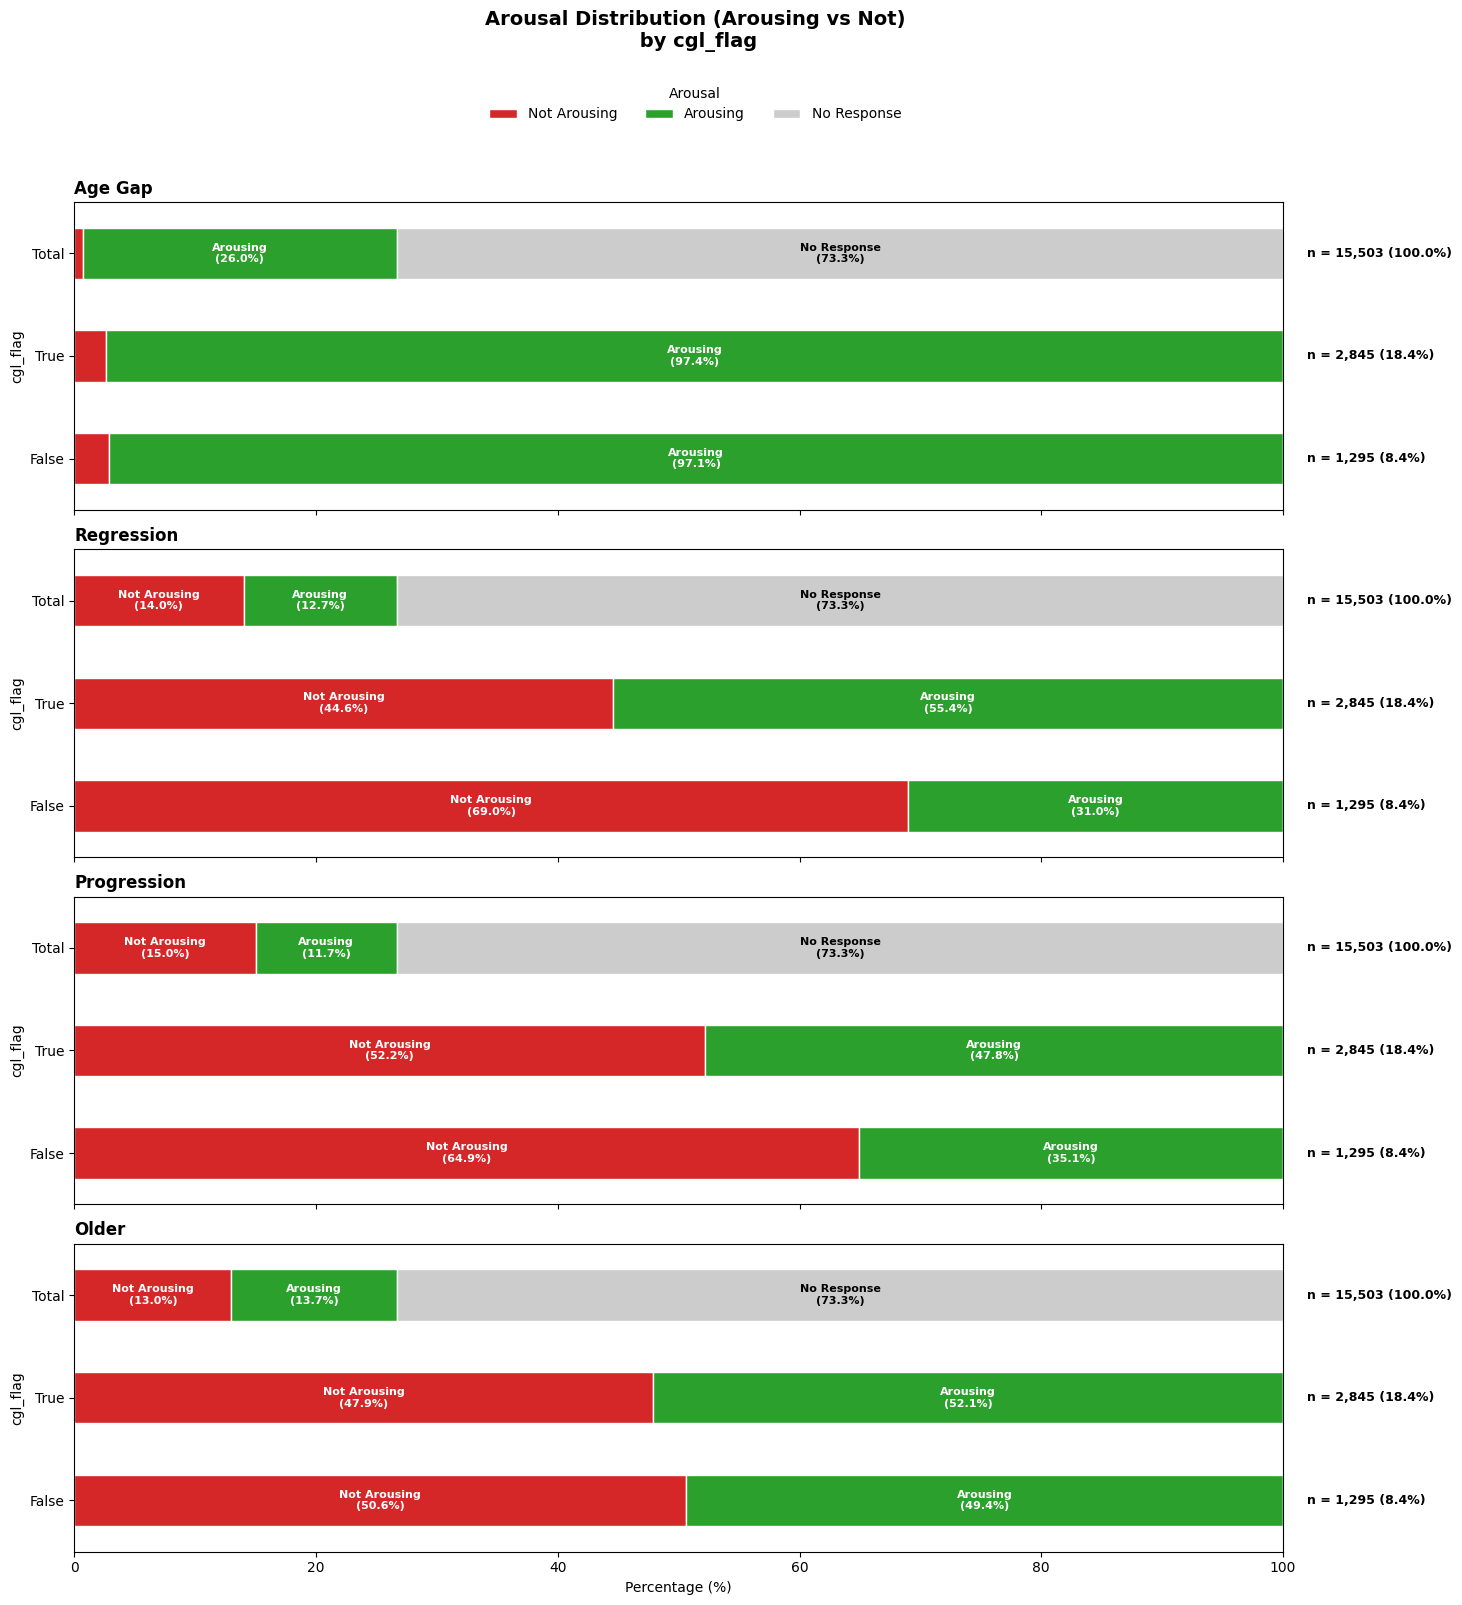

In [101]:
def plot_arousal_distribution(ax, df, col, title):
    """Plot arousal distribution (Arousing vs Not) for `col`, sliced by cgl_flag."""
    # Filter NaN only (keep 0 values)
    df_filtered = df.dropna(subset=[col]).copy()
    df_filtered[col] = df_filtered[col].astype(int)

    # Bucket into binary: 0 = "Not Arousing", 1-5 = "Arousing"
    df_filtered['arousal_bucket'] = df_filtered[col].apply(
        lambda x: 'Arousing' if x >= 1 else 'Not Arousing'
    )

    # Build crosstab for True/False only
    cgl_for_plot = df_filtered['cgl_flag'].astype(str)
    flag_pivot = (
        pd.crosstab(cgl_for_plot, df_filtered['arousal_bucket'], normalize='index')
        .mul(100)
        .round(1)
    )
    # Add a "No Response" column (0% for True/False since they have no NaN here)
    flag_pivot['No Response'] = 0.0
    # Reorder
    flag_pivot = flag_pivot.reindex(columns=['Not Arousing', 'Arousing', 'No Response'], fill_value=0)
    # Drop Unknown row if present
    flag_pivot = flag_pivot.drop(index='Unknown', errors='ignore')

    # Total row: based on ENTIRE df (df.shape[0]), bucketed including NaN as "No Response"
    def bucket_with_nan(x):
        if pd.isna(x):
            return 'No Response'
        elif x >= 1:
            return 'Arousing'
        else:
            return 'Not Arousing'
    
    total_buckets = df[col].apply(bucket_with_nan)
    total_dist = (
        total_buckets.value_counts(normalize=True)
        .mul(100)
        .round(1)
        .reindex(flag_pivot.columns, fill_value=0)
    )
    flag_pivot.loc['Total'] = total_dist

    flag_pivot.plot(
        kind='barh', stacked=True, ax=ax,
        color=['#d62728', '#2ca02c', '#cccccc'], edgecolor='white', legend=False,
    )

    ax.set_title(title, fontweight='bold', loc='left')
    ax.set_xlim(0, 100)
    ax.set_ylabel('cgl_flag')

    # Segment labels
    for i, container in enumerate(ax.containers):
        bucket_label = flag_pivot.columns[i]
        labels = [f'{bucket_label}\n({v:.1f}%)' if v > 3 else '' for v in flag_pivot.iloc[:, i]]
        text_color = 'black' if bucket_label == 'No Response' else 'white'
        ax.bar_label(container, labels=labels, label_type='center',
                     fontsize=8, color=text_color, fontweight='bold')

    # n= labels on the right (with % of total df)
    counts_per_flag = cgl_for_plot.value_counts()
    total_df = df.shape[0]
    for i, flag in enumerate(flag_pivot.index):
        if flag == 'Total':
            count = total_df  # Entire df
        else:
            count = counts_per_flag.get(flag, 0)
        pct_of_total = (count / total_df * 100)
        ax.text(
            1.02, i, f'n = {count:,} ({pct_of_total:.1f}%)',
            transform=ax.get_yaxis_transform(),
            ha='left', va='center',
            fontsize=9, fontweight='bold',
        )

    return flag_pivot


# Define the metrics: (column_name, display_title)
metrics = [
    ('agegap', 'Age Gap'),
    ('regression', 'Regression'),
    ('progression', 'Progression'), 
    ('older', 'Older')
]

# Create stacked subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 4 * len(metrics)), sharex=True)

last_pivot = None
for ax, (col, title) in zip(axes, metrics):
    last_pivot = plot_arousal_distribution(ax, df, col, title)

axes[-1].set_xlabel('Percentage (%)')

# Single shared legend at the top of the figure
fig.legend(
    handles=axes[0].containers,
    labels=[str(c) for c in last_pivot.columns],
    title='Arousal',
    bbox_to_anchor=(0.5, 0.96),
    loc='upper center',
    ncol=len(last_pivot.columns),
    frameon=False,
)

fig.suptitle('Arousal Distribution (Arousing vs Not)\n by cgl_flag',
             fontweight='bold', fontsize=14, y=1.0)

plt.tight_layout()
plt.subplots_adjust(top=0.88, right=0.92)
plt.show()


## CGL Roles Distribution

### Roles Interest

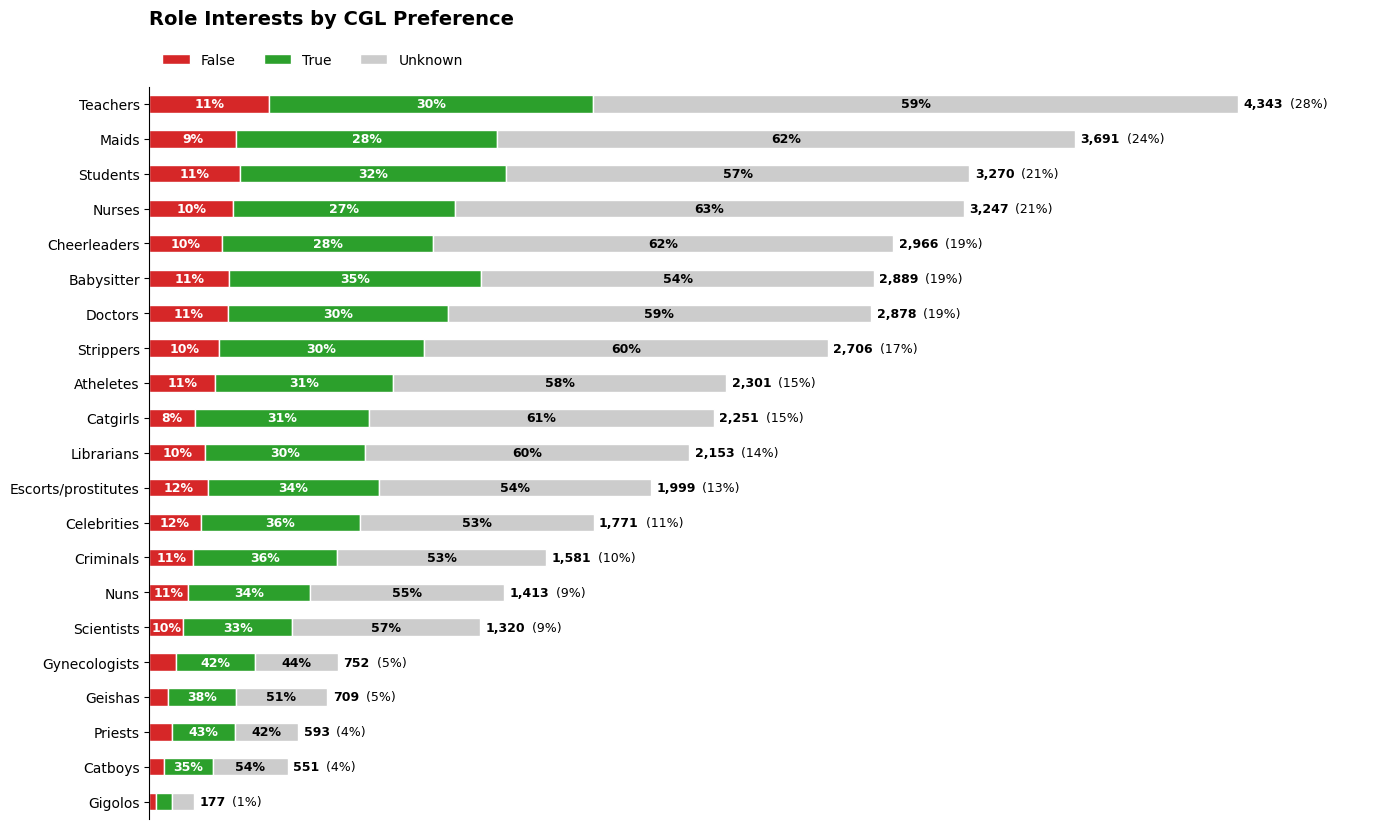

In [102]:
# Build counts: rows = role, columns = cgl_flag (True/False/Unknown)
role_cols = df.filter(like='role_').columns.tolist()
role_by_flag = df.groupby('cgl_flag')[role_cols].sum().T
role_by_flag = role_by_flag.fillna(0).astype(int)
role_by_flag.index = role_by_flag.index.str.replace('role_', '', regex=False)

# Total per role
role_totals = role_by_flag.sum(axis=1)

# % within each role (rows sum to 100)
role_pct = role_by_flag.div(role_totals, axis=0).mul(100).round(0)

# Order: False, True, Unknown
role_pct = role_pct.reindex(columns=['False', 'True', 'Unknown'], fill_value=0)
role_by_flag = role_by_flag.reindex(columns=['False', 'True', 'Unknown'], fill_value=0)

# Sort by total n ascending (highest n at top of barh)
sorted_index = role_totals.sort_values(ascending=True).index
role_pct = role_pct.loc[sorted_index]
role_by_flag = role_by_flag.loc[sorted_index]
role_totals = role_totals.loc[sorted_index]

# Plot raw counts (so bar length = n) — stacked
fig, ax = plt.subplots(figsize=(14, max(6, 0.4 * len(role_by_flag))))

role_by_flag.plot(
    kind='barh', stacked=True, ax=ax,
    color=['#d62728', '#2ca02c', '#cccccc'],  # False=red, True=green, Unknown=gray
    edgecolor='white', legend=False,
)

# Title with extra pad to leave room for legend below it
ax.set_title('Role Interests by CGL Preference',
             fontweight='bold', fontsize=14, loc='left', pad=45)
ax.set_ylabel('')

# Remove x-axis
ax.set_xlabel('')
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Segment labels inside bars: % only
for i, container in enumerate(ax.containers):
    flag_label = role_by_flag.columns[i]
    pct_values = role_pct.iloc[:, i].values
    n_values = role_by_flag.iloc[:, i].values
    min_n_for_label = role_totals.max() * 0.03
    labels = [
        f'{p:.0f}%' if n > min_n_for_label else ''
        for p, n in zip(pct_values, n_values)
    ]
    text_color = 'black' if flag_label == 'Unknown' else 'white'
    ax.bar_label(container, labels=labels, label_type='center',
                 fontsize=9, color=text_color, fontweight='bold')

# Right-side labels: n-count bold, % not bold
total_df = df.shape[0]
xmax = role_totals.max()
ax.set_xlim(0, xmax * 1.13)
for i, role in enumerate(role_pct.index):
    count = int(role_totals.loc[role])
    pct_of_total = (count / total_df * 100)
    n_text = ax.text(
        count + xmax * 0.005, i, f'{count:,}',
        ha='left', va='center',
        fontsize=9, fontweight='bold',
    )
    ax.annotate(
        f' ({pct_of_total:.0f}%)',
        xy=(1, 0.5), xycoords=n_text,
        xytext=(2, 0), textcoords='offset points',
        ha='left', va='center', fontsize=9,
    )

# Legend below title (no legend title to keep it compact, single row)
ax.legend(
    bbox_to_anchor=(0, 1.01),
    loc='lower left',
    ncol=3,
    frameon=False,
    fontsize=10,
)

plt.tight_layout()
plt.show()


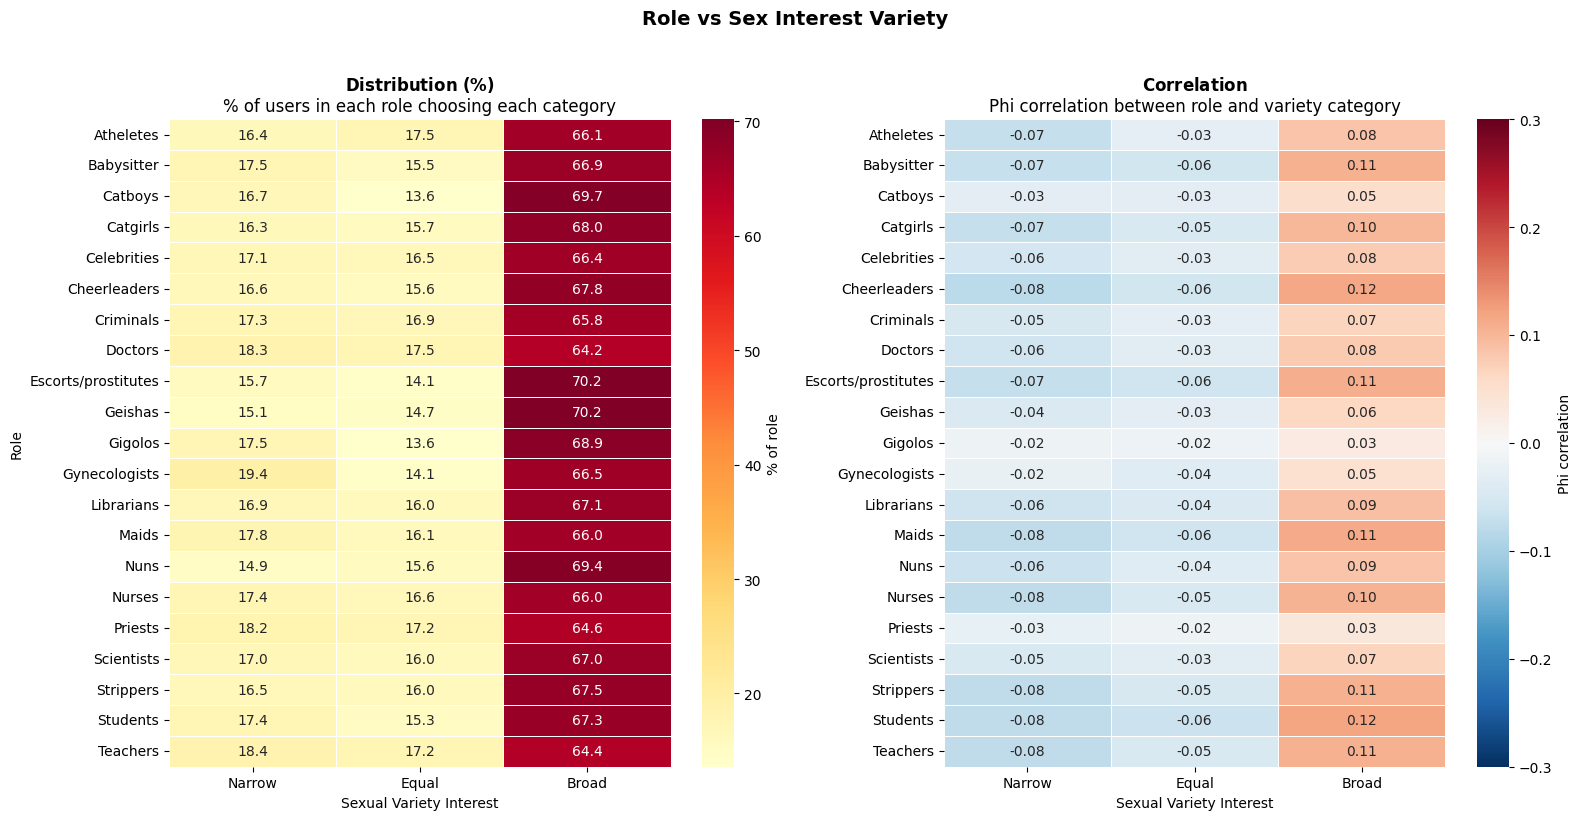

In [103]:
# ===== Collapse variety to 3 levels =====
variety_3_map = {
    'Very narrow': 'Narrow',
    'A little narrow': 'Narrow',
    'Somewhat narrow': 'Narrow',
    'Equally narrow and broad': 'Equal',
    'A little broad': 'Broad',
    'Somewhat broad': 'Broad',
    'Very broad': 'Broad',
}
df['variety_3'] = df['sexual_interest_variety'].map(variety_3_map)
variety_order = ['Narrow', 'Equal', 'Broad']

role_cols = df.filter(like='role_').columns.tolist()

# ===== LEFT: % distribution =====
rows = []
for r_col in role_cols:
    subset = df[df[r_col] == 1]
    if len(subset) > 0:
        dist = (
            subset['variety_3']
            .value_counts(normalize=True)
            .mul(100)
            .round(1)
        )
        dist.name = r_col.replace('role_', '')
        rows.append(dist)

pct_data = (
    pd.concat(rows, axis=1).T.fillna(0)
    .reindex(columns=variety_order, fill_value=0)
    .sort_index()
)

# ===== RIGHT: phi correlation =====
variety_dummies = pd.get_dummies(df['variety_3']).reindex(
    columns=variety_order, fill_value=0
)

corr_matrix = pd.DataFrame(
    index=[c.replace('role_', '') for c in role_cols],
    columns=variety_order,
    dtype=float,
)
for r_col in role_cols:
    for v_cat in variety_order:
        corr_matrix.loc[r_col.replace('role_', ''), v_cat] = df[r_col].corr(variety_dummies[v_cat])

corr_matrix = corr_matrix.astype(float).sort_index()

# ===== Plot side by side =====
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(
    pct_data, annot=True, fmt='.1f',
    cmap='YlOrRd', cbar_kws={'label': '% of role'},
    linewidths=0.5, linecolor='white', ax=axes[0],
)
axes[0].set_title(r"$\bf{Distribution\ (\%)}$" "\n% of users in each role choosing each category")
axes[0].set_xlabel('Sexual Variety Interest')
axes[0].set_ylabel('Role')
plt.setp(axes[0].get_xticklabels(), rotation=0, ha='center')
plt.setp(axes[0].get_yticklabels(), rotation=0)

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
    cbar_kws={'label': 'Phi correlation'},
    linewidths=0.5, linecolor='white', ax=axes[1],
)
axes[1].set_title(r"$\bf{Correlation}$" "\nPhi correlation between role and variety category")
axes[1].set_xlabel('Sexual Variety Interest')
axes[1].set_ylabel('')
plt.setp(axes[1].get_xticklabels(), rotation=0, ha='center')
plt.setp(axes[1].get_yticklabels(), rotation=0)

fig.suptitle('Role vs Sex Interest Variety', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


How to read this chart
──────────────────────
LEFT  (Distribution %): For each role, the share of its users who picked Sub /
      Equal / Dom. Rows sum to 100%. Rows are ordered by n (largest role on top).
      Color (custom non-linear ramp, scale 0% → 50%):
        0-20%   : near-white — values stay quiet
        20-30%  : near-white with a faint blue tint
        30-40%  : light teal — values start to register
        40-45%  : medium-dark teal — clearly elevated
        45-50%  : deep navy — strong concentration

RIGHT (D/s Lean): the role's average position on the original 1-7 D/s scale,
      shifted so 0 = "Switch/equal/no preference". Units are scale steps:
        +1.0 = on average, one step toward Dominant from Equal
        -1.5 = halfway between Slightly and Moderately Submissive
        ±3.0 = the maximum possible (everyone in the role picked the extreme)
      Significance: * p<.05, ** p<.01, *** p<.001. With this n, almost
      everything is significant — magnitude is 

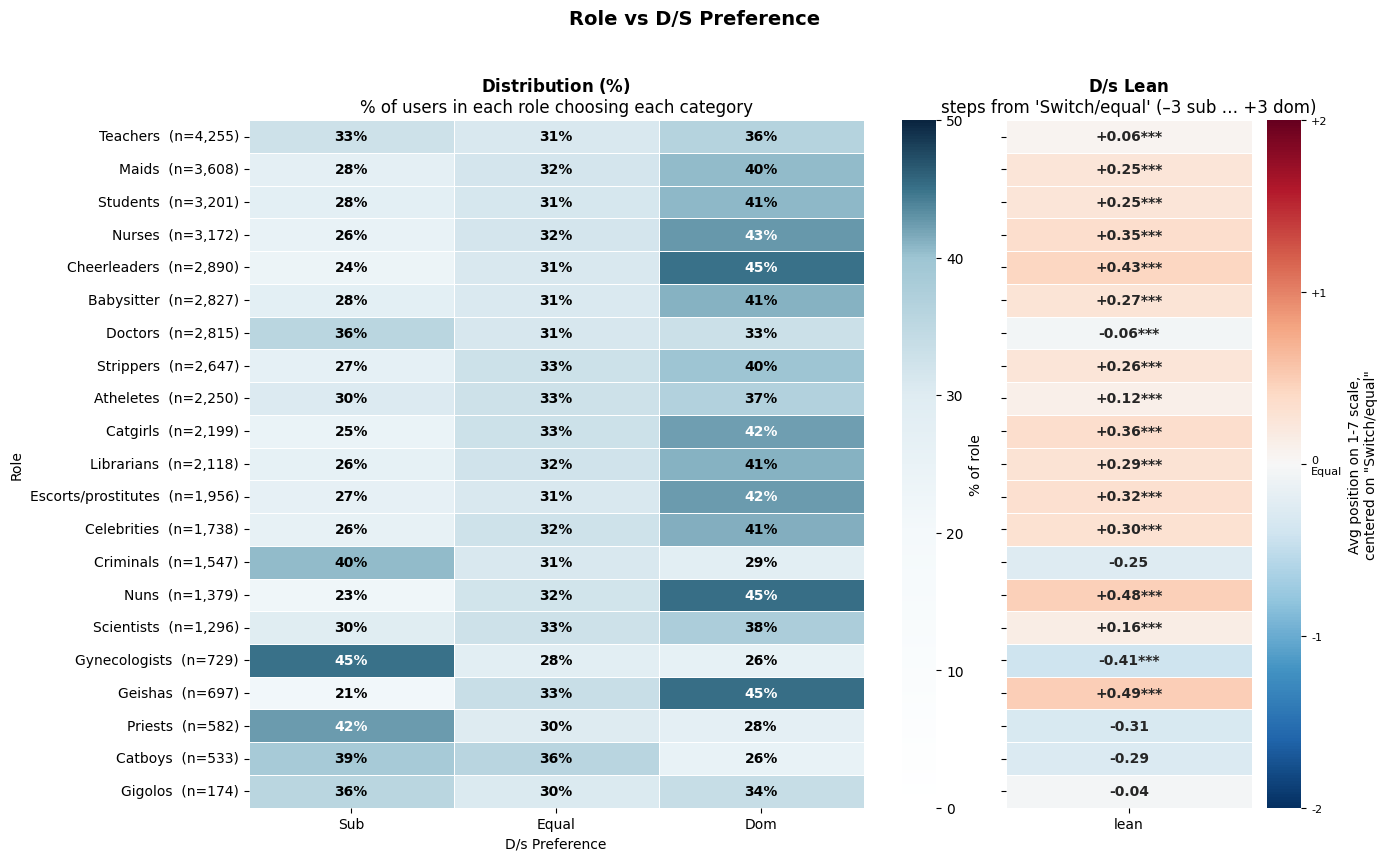

In [104]:
# ===== Role vs D/s Preference (collapsed to 3 levels) =====
# LEFT  panel: 3-level distribution heatmap (Sub / Equal / Dom)
# RIGHT panel: D/s Lean = mean ds_rank for the role minus the "Switch/equal" anchor

# ----- How to read this chart -----
print("""\
How to read this chart
──────────────────────
LEFT  (Distribution %): For each role, the share of its users who picked Sub /
      Equal / Dom. Rows sum to 100%. Rows are ordered by n (largest role on top).
      Color (custom non-linear ramp, scale 0% → 50%):
        0-20%   : near-white — values stay quiet
        20-30%  : near-white with a faint blue tint
        30-40%  : light teal — values start to register
        40-45%  : medium-dark teal — clearly elevated
        45-50%  : deep navy — strong concentration

RIGHT (D/s Lean): the role's average position on the original 1-7 D/s scale,
      shifted so 0 = "Switch/equal/no preference". Units are scale steps:
        +1.0 = on average, one step toward Dominant from Equal
        -1.5 = halfway between Slightly and Moderately Submissive
        ±3.0 = the maximum possible (everyone in the role picked the extreme)
      Significance: * p<.05, ** p<.01, *** p<.001. With this n, almost
      everything is significant — magnitude is what matters.

Why the lean uses the 1-7 scale (not the 3-level collapse): the score weights
"Totally" more than "Slightly", so a role full of Totally-dominants gets a
stronger lean than one of Slightly-dominants — even though both look 100% Dom
in the left panel.\
""")


# Custom cmap, anchored to vmax=50. Stop positions = absolute % / 50.
# Data tops out around 50%, so the full cmap range is spent on real values.
pct_cmap = mcolors.LinearSegmentedColormap.from_list(
    'pct_cmap',
    [
        (0.00, '#ffffff'),  #  0%  pure white
        (0.40, '#f4f9fb'),  # 20%  very near-white
        (0.60, '#dfecf2'),  # 30%  near-white, faint blue tint
        (0.80, '#9ec5d3'),  # 40%  light teal
        (0.90, '#3a738a'),  # 45%  medium-dark teal
        (1.00, '#0a2540'),  # 50%  deep navy
    ],
)

# Collapse 7 → 3 levels
ds_3_map = {
    'Totally submissive':         'Sub',
    'Moderately submissive':      'Sub',
    'Slightly submissive':        'Sub',
    'Switch/equal/no preference': 'Equal',
    'Slightly dominant':          'Dom',
    'Moderately dominant':        'Dom',
    'Totally dominant':           'Dom',
}
df['ds_3'] = df['ds_preference'].map(ds_3_map)
ds_3_order = ['Sub', 'Equal', 'Dom']

role_cols = df.filter(like='role_').columns.tolist()

# ----- LEFT: % distribution per role across Sub/Equal/Dom -----
rows, n_per_role = [], {}
for r_col in role_cols:
    subset = df[(df[r_col] == 1) & df['ds_3'].notna()]
    n_per_role[r_col.replace('role_', '')] = len(subset)
    if len(subset) > 0:
        dist = subset['ds_3'].value_counts(normalize=True).mul(100).round(1)
        dist.name = r_col.replace('role_', '')
        rows.append(dist)

pct_data = (
    pd.concat(rows, axis=1).T.fillna(0)
      .reindex(columns=ds_3_order, fill_value=0)
)

# ----- RIGHT: D/s Lean = mean(ds_rank for role) − rank("Switch/equal") -----
EQUAL_RANK = ds_rank['Switch/equal/no preference']  # = 4
ds_rank_series = df['ds_preference'].map(ds_rank)
mask = ds_rank_series.notna()

lean_rows = []
for r_col in role_cols:
    role_mask = (df[r_col] == 1) & mask
    if role_mask.sum() == 0:
        continue
    mean_rank = ds_rank_series[role_mask].mean()
    _, p = pointbiserialr(df.loc[mask, r_col].astype(int), ds_rank_series.loc[mask])
    lean_rows.append({
        'role': r_col.replace('role_', ''),
        'lean': mean_rank - EQUAL_RANK,
        'p': p,
    })
lean_df = pd.DataFrame(lean_rows).set_index('role')

# Sort by sample size (n) descending — largest roles at the top
sort_order = pd.Series(n_per_role).sort_values(ascending=False).index
pct_data = pct_data.reindex(sort_order)
lean_df = lean_df.reindex(sort_order)

# Append n to y-axis labels
y_labels = [f'{role}  (n={n_per_role.get(role, 0):,})' for role in pct_data.index]
pct_data.index = y_labels
lean_df.index = y_labels

# Lean panel: floor at ±2 so small leans stay readable
vbound = max(2.0, float(lean_df['lean'].abs().max()))

# ----- Plot side by side -----
fig, axes = plt.subplots(
    1, 2, figsize=(14, max(6, 0.4 * len(pct_data))),
    gridspec_kw={'width_ratios': [3, 1.2]},
    sharey=True,
)

# --- Left: custom cmap on 0-50 scale.
sns.heatmap(
    pct_data, annot=False,
    cmap=pct_cmap,
    vmin=0, vmax=50,
    cbar_kws={'label': '% of role', 'ticks': [0, 10, 20, 30, 40, 50]},
    linewidths=0.5, linecolor='white', ax=axes[0],
)

# Adaptive annotation: black text on light cells, white on dark. Crossover ~42%.
WHITE_TEXT_THRESHOLD = 42
for i in range(pct_data.shape[0]):
    for j in range(pct_data.shape[1]):
        v = pct_data.iloc[i, j]
        axes[0].text(
            j + 0.5, i + 0.5, f'{v:.0f}%',
            ha='center', va='center',
            color='white' if v >= WHITE_TEXT_THRESHOLD else 'black',
            fontweight='bold', fontsize=10,
        )

axes[0].set_title(r"$\bf{Distribution\ (\%)}$" "\n% of users in each role choosing each category")
axes[0].set_xlabel('D/s Preference')
axes[0].set_ylabel('Role')
plt.setp(axes[0].get_xticklabels(), rotation=0, ha='center')
plt.setp(axes[0].get_yticklabels(), rotation=0)

# --- Right: D/s Lean as a single column. Diverging cmap centered on 0 (= Switch/equal).
def sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

annot = lean_df.apply(lambda row: f"{row['lean']:+.2f}{sig(row['p'])}", axis=1).to_frame('lean')

cbar_ticks = [-3, -2, -1, 0, 1, 2, 3]
cbar_labels = ['-3\nTotally\nSub', '-2', '-1', '0\nEqual', '+1', '+2', '+3\nTotally\nDom']

sns.heatmap(
    lean_df[['lean']], annot=annot, fmt='',
    cmap='RdBu_r', center=0, vmin=-vbound, vmax=vbound,
    cbar_kws={
        'label': 'Avg position on 1-7 scale,\ncentered on "Switch/equal"',
        'ticks': cbar_ticks,
    },
    linewidths=0.5, linecolor='white', ax=axes[1],
    annot_kws={'fontweight': 'bold'},
)
axes[1].collections[0].colorbar.ax.set_yticklabels(cbar_labels, fontsize=8)

axes[1].set_title(r"$\bf{D/s\ Lean}$" "\nsteps from 'Switch/equal' (–3 sub … +3 dom)")
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_xticklabels(['lean'])
plt.setp(axes[1].get_yticklabels(), rotation=0)

fig.suptitle('Role vs D/S Preference', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## CGL Emotional Erotic Desires 

### Soft Erotic Preferences

In [105]:
### Not many ppl answered --> not useful

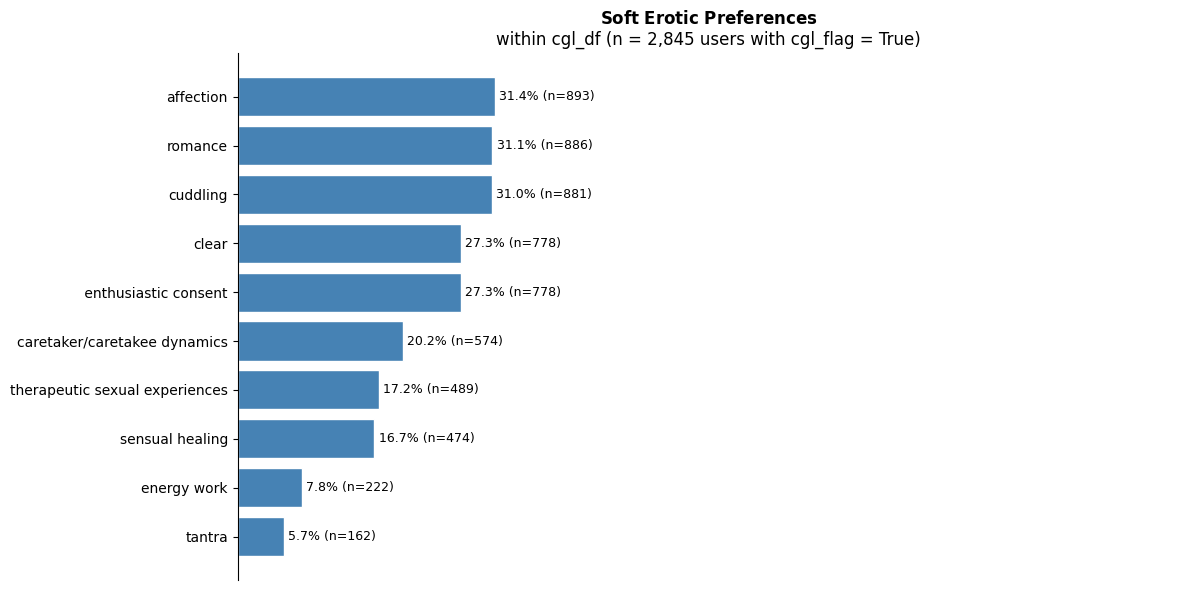

In [106]:
soft_erotic_cols = cgl_df.filter(like='soft_erotic_').columns.tolist()

# Calculate counts and percentages
data = pd.DataFrame({
    'pct': (cgl_df[soft_erotic_cols].mean() * 100).round(1),
    'count': cgl_df[soft_erotic_cols].sum().astype(int),
})

# Strip prefix
data.index = data.index.str.replace(r'^(soft_erotic_)+', '', regex=True)

# Sort ascending (highest at top of horizontal bar)
data = data.sort_values('pct', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, max(6, len(data) * 0.35)))
ax.barh(data.index, data['pct'], color='steelblue', edgecolor='white')

ax.set_title(
    r"$\bf{Soft\ Erotic\ Preferences}$"
    f"\nwithin cgl_df (n = {len(cgl_df):,} users with cgl_flag = True)"
)

# Hide x-axis (ticks, label, and surrounding spines)
ax.set_xticks([])
ax.set_xlabel('')
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Data labels: "85.3% (n=2,361)"
labels = [f'{p:.1f}% (n={n:,})' for p, n in zip(data['pct'], data['count'])]
ax.bar_label(ax.containers[0], labels=labels, padding=3, fontsize=9)

# Extra room on the right so labels don't get clipped
ax.set_xlim(0, 115)

plt.tight_layout()
plt.show()


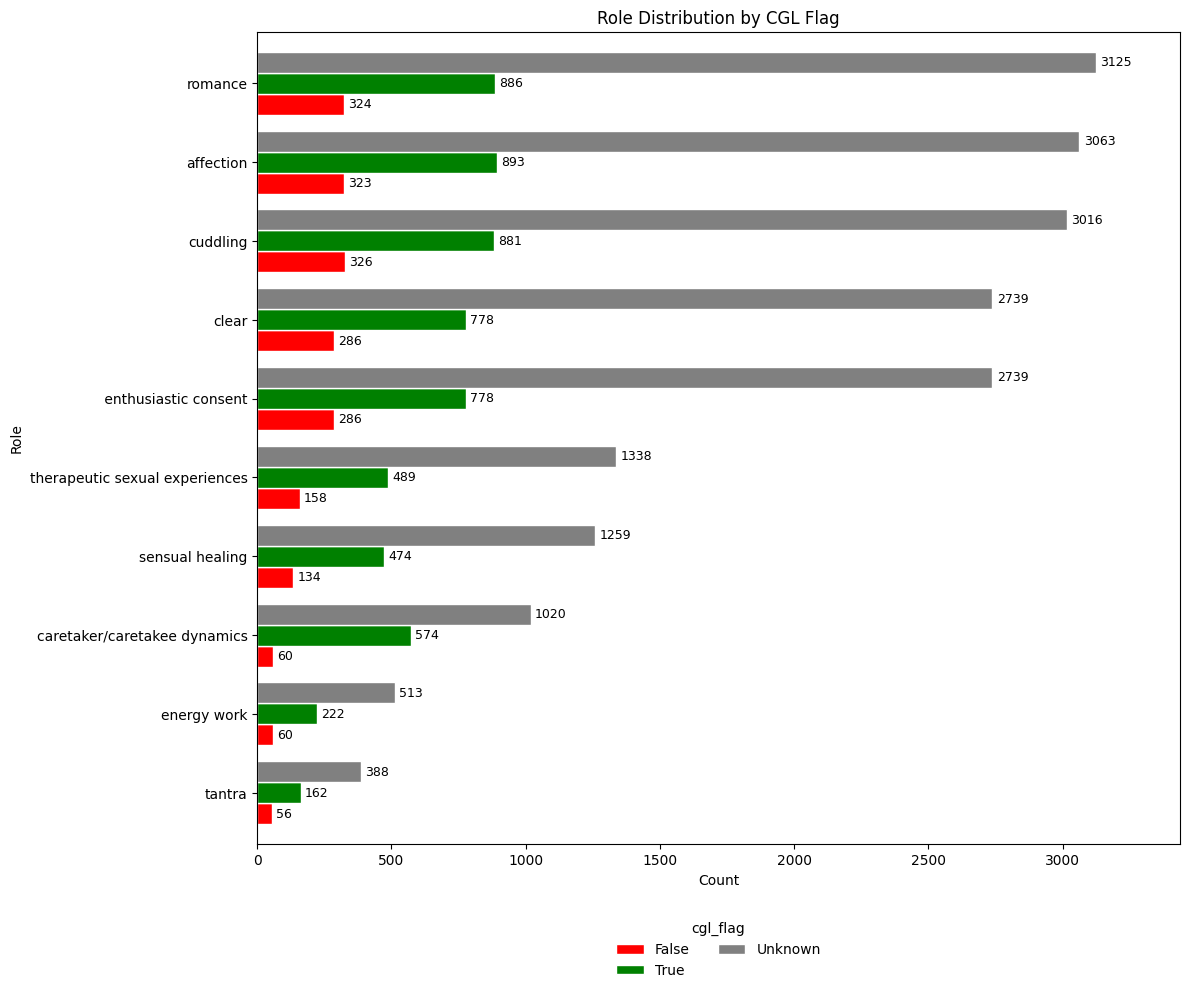

In [107]:
# Use the FULL dataframe (df), not the filtered cgl_df
role_cols = df.filter(like='soft_erotic_').columns.tolist()
role_by_flag = df.groupby('cgl_flag')[role_cols].sum().T

role_by_flag = role_by_flag.sort_index(axis=1).fillna(0).astype(int)
role_by_flag.index = role_by_flag.index.str.replace('soft_erotic_', '', regex=False)
role_by_flag = role_by_flag.loc[role_by_flag.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(12, 10))
role_by_flag.plot(
    kind='barh',
    ax=ax,
    color=['red', 'green', 'gray'],  # False=red, True=green, Unknown=gray
    edgecolor='white',
    width=0.8,
)

ax.set_title('Role Distribution by CGL Flag')
ax.set_xlabel('Count')
ax.set_ylabel('Role')
ax.legend(title='cgl_flag', bbox_to_anchor=(0.5, -0.08), loc='upper center', ncol=2, frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

xmax = role_by_flag.values.max()
if xmax > 0:
    ax.set_xlim(0, xmax * 1.1)

plt.tight_layout()
plt.show()


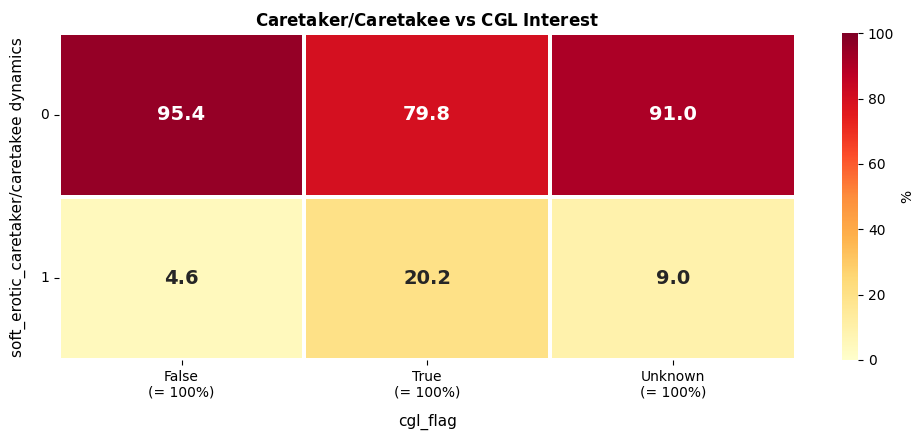

In [108]:
# === Adjust to match your column ===
care_col = 'soft_erotic_caretaker/caretakee dynamics'
# ===================================

# Column-normalized: each cgl_flag column sums to 100%
breakdown = (
    pd.crosstab(df[care_col], df['cgl_flag'], normalize='columns')
    .mul(100)
    .round(1)
    .sort_index(axis=1)
    .sort_index(axis=0)
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(
    breakdown,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': '%'},
    linewidths=1.5, linecolor='white',
    ax=ax,
    vmin=0, vmax=100,
    annot_kws={'fontsize': 14, 'fontweight': 'bold'},
)

# Short x-tick labels (just the flag value, with column total below)
col_totals = breakdown.sum(axis=0)
new_xticklabels = [
    f'{col}\n(= {total:.0f}%)'
    for col, total in zip(breakdown.columns, col_totals)
]
ax.set_xticklabels(new_xticklabels)

# Short y-tick labels (just the value)
ax.set_yticklabels(breakdown.index)

ax.set_title(
    r"$\bf{Caretaker/Caretakee\ vs\ CGL\ Interest}$"
)
ax.set_xlabel('cgl_flag', fontsize=11, labelpad=10)
ax.set_ylabel(care_col, fontsize=11, labelpad=10)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


### You/Other Feel Most

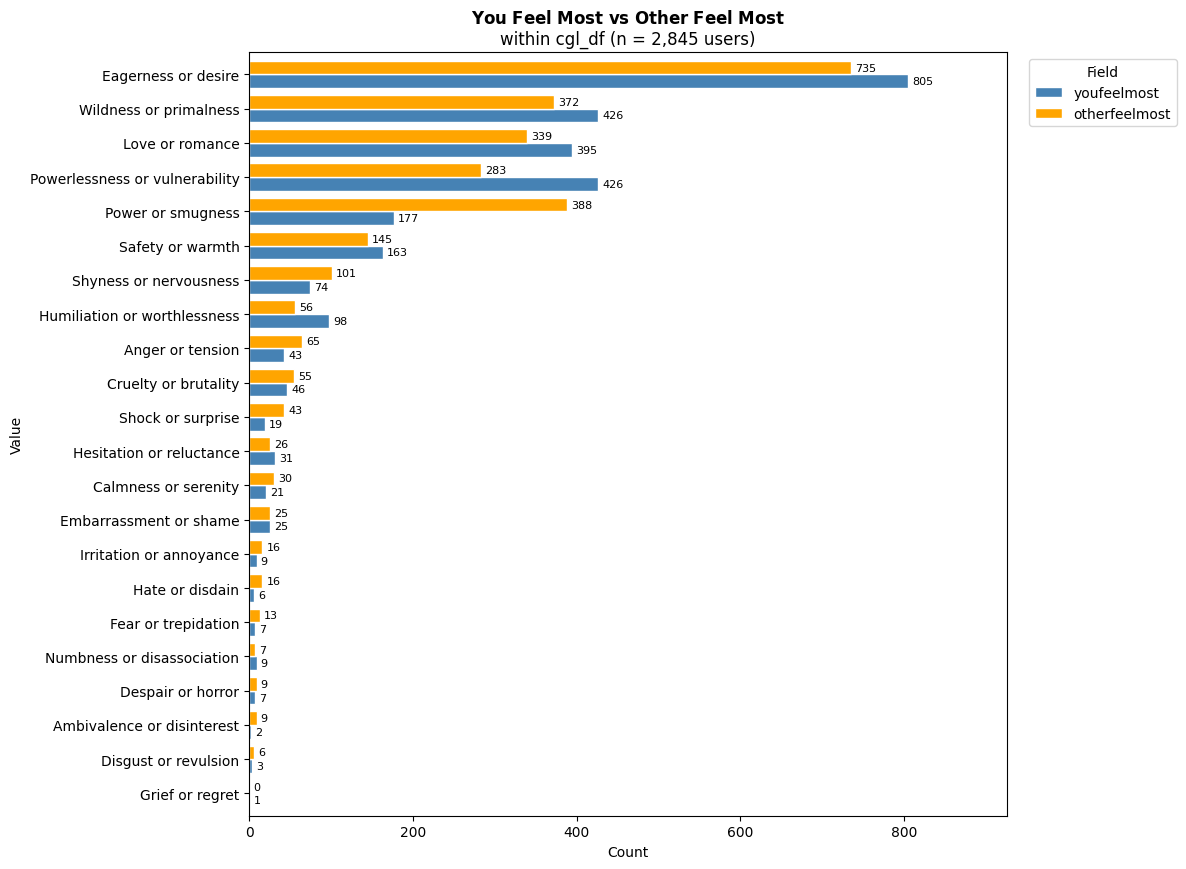

In [109]:
combined = pd.DataFrame({
    'youfeelmost': cgl_df['youfeelmost'].value_counts(),
    'otherfeelmost': cgl_df['otherfeel1most'].value_counts(),
}).fillna(0).astype(int)

# Sort by total count across both fields (ascending → highest at top)
combined = combined.loc[combined.sum(axis=1).sort_values(ascending=True).index]

# Plot grouped horizontal bar
fig, ax = plt.subplots(figsize=(12, max(6, len(combined) * 0.4)))
combined.plot(
    kind='barh',
    ax=ax,
    color=['steelblue', 'orange'],
    edgecolor='white',
    width=0.8,
)

ax.set_title(
    r"$\bf{You\ Feel\ Most\ vs\ Other\ Feel\ Most}$"
    f"\nwithin cgl_df (n = {len(cgl_df):,} users)"
)
ax.set_xlabel('Count')
ax.set_ylabel('Value')

# Count labels at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=8)

ax.legend(title='Field', bbox_to_anchor=(1.02, 1), loc='upper left')

xmax = combined.values.max()
if xmax > 0:
    ax.set_xlim(0, xmax * 1.15)

plt.tight_layout()
plt.show()


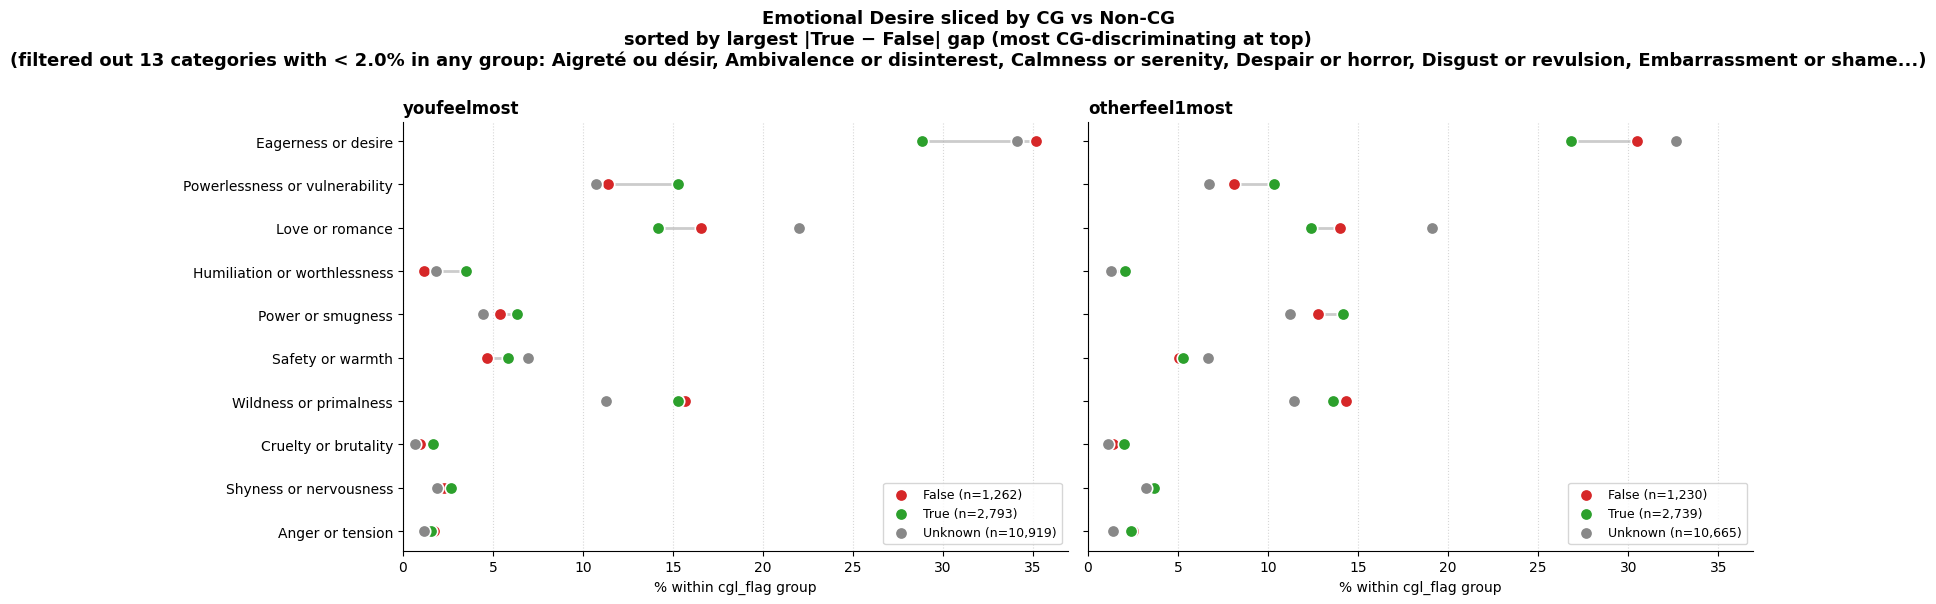

In [110]:
# === Adjust to match your columns ===
field_cols = ['youfeelmost', 'otherfeel1most']
MIN_PCT_THRESHOLD = 2.0  # drop categories where max % across all flags < this
# ====================================

# Build % within each cgl_flag group for each field
def build_pct(df, col):
    sub = df.dropna(subset=[col]).copy()
    sub['cgl_flag'] = sub['cgl_flag'].astype(str)
    pivot = pd.crosstab(sub[col], sub['cgl_flag'], normalize='columns').mul(100)
    return pivot.reindex(columns=['False', 'True', 'Unknown'], fill_value=0)

pct_left = build_pct(df, field_cols[0])
pct_right = build_pct(df, field_cols[1])

# Union of categories, fill missing with 0
all_cats = pct_left.index.union(pct_right.index)
pct_left = pct_left.reindex(all_cats, fill_value=0)
pct_right = pct_right.reindex(all_cats, fill_value=0)

# (1) FILTER: drop categories where max % across all flags & both fields < threshold
max_per_cat = pd.concat([pct_left, pct_right], axis=1).max(axis=1)
kept_cats = max_per_cat[max_per_cat >= MIN_PCT_THRESHOLD].index
dropped_cats = max_per_cat[max_per_cat < MIN_PCT_THRESHOLD].index.tolist()
pct_left = pct_left.loc[kept_cats]
pct_right = pct_right.loc[kept_cats]

# (2) SORT: by max abs(True - False) across both fields, descending
abs_diff = pd.concat([
    (pct_left['True'] - pct_left['False']).abs(),
    (pct_right['True'] - pct_right['False']).abs(),
], axis=1).max(axis=1)
sort_order = abs_diff.sort_values(ascending=True).index  # ascending → biggest gap at top of barh
pct_left = pct_left.loc[sort_order]
pct_right = pct_right.loc[sort_order]

# n per cgl_flag group (for legend)
n_left = df.dropna(subset=[field_cols[0]])['cgl_flag'].astype(str).value_counts()
n_right = df.dropna(subset=[field_cols[1]])['cgl_flag'].astype(str).value_counts()

# (3) MATCH x-axis: shared scale across both panels
xmax = max(pct_left.values.max(), pct_right.values.max()) * 1.05

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, 0.45 * len(sort_order))),
                          sharey=True, sharex=True)

color_map = {'False': '#d62728', 'True': '#2ca02c', 'Unknown': '#888888'}

def plot_panel(ax, pct, title, n_counts):
    y_pos = np.arange(len(pct))
    for i, cat in enumerate(pct.index):
        ax.plot(
            [pct.loc[cat, 'False'], pct.loc[cat, 'True']],
            [i, i],
            color='#cccccc', linewidth=2, zorder=1,
        )
    for flag in ['False', 'True', 'Unknown']:
        ax.scatter(
            pct[flag].values, y_pos,
            color=color_map[flag], s=80, zorder=3,
            label=f'{flag} (n={int(n_counts.get(flag, 0)):,})',
            edgecolor='white', linewidth=1.2,
        )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(pct.index)
    ax.set_title(title, fontweight='bold', fontsize=12, loc='left')
    ax.set_xlabel('% within cgl_flag group')
    ax.set_xlim(0, xmax)
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower right', frameon=True, fontsize=9)

plot_panel(axes[0], pct_left, field_cols[0], n_left)
plot_panel(axes[1], pct_right, field_cols[1], n_right)

# Suptitle with summary of dropped categories
dropped_note = (
    f'\n(filtered out {len(dropped_cats)} categories with < {MIN_PCT_THRESHOLD}% '
    f'in any group: {", ".join(dropped_cats[:6])}'
    f'{"..." if len(dropped_cats) > 6 else ""})'
) if dropped_cats else ''
fig.suptitle(
    'Emotional Desire sliced by CG vs Non-CG\n'
    'sorted by largest |True − False| gap (most CG-discriminating at top)'
    + dropped_note,
    fontweight='bold', fontsize=13, y=1.0,
)

plt.tight_layout()
plt.show()


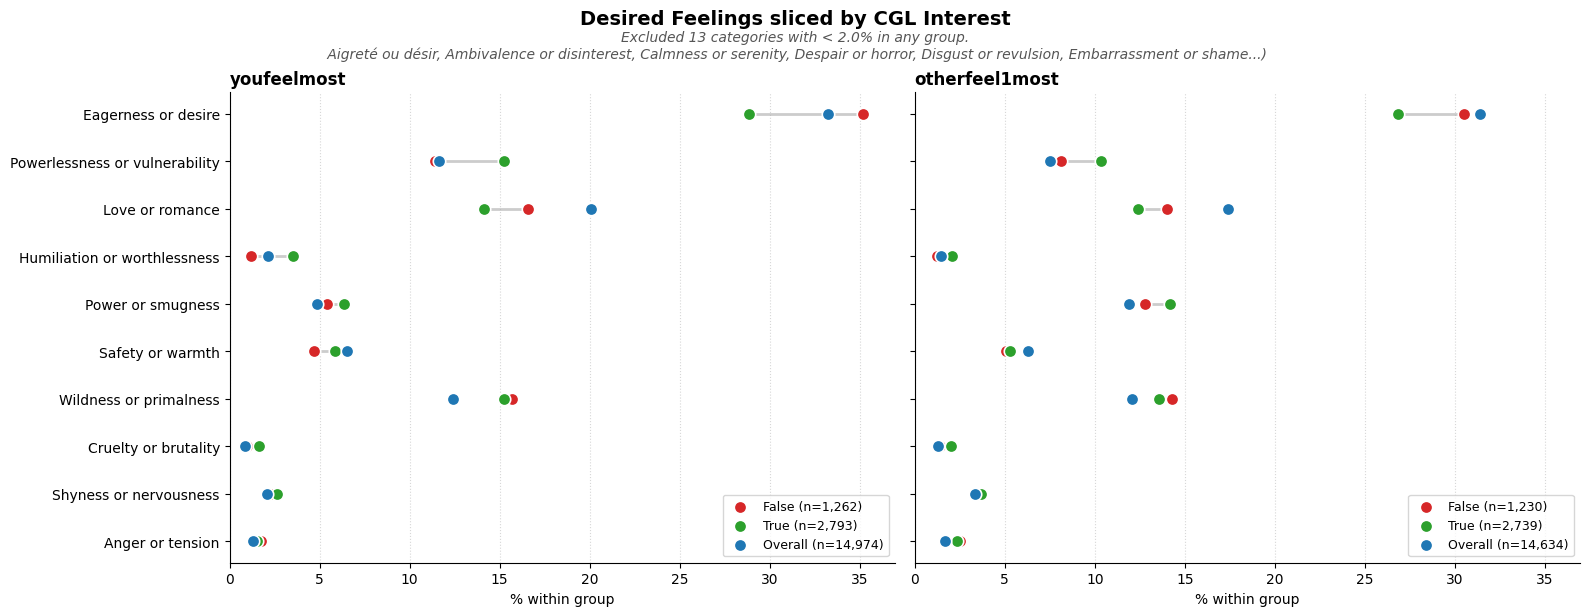

In [111]:
# === Adjust to match your columns ===
field_cols = ['youfeelmost', 'otherfeel1most']
MIN_PCT_THRESHOLD = 2.0  # drop categories where max % across all flags < this
# ====================================

# Build % within each cgl_flag group + a Total baseline column
def build_pct(df, col):
    sub = df.dropna(subset=[col]).copy()
    sub['cgl_flag'] = sub['cgl_flag'].astype(str)
    pivot = pd.crosstab(sub[col], sub['cgl_flag'], normalize='columns').mul(100)
    pivot = pivot.reindex(columns=['False', 'True', 'Unknown'], fill_value=0)
    # Total: % distribution across the entire field (all cgl_flag values combined)
    total_dist = sub[col].value_counts(normalize=True).mul(100)
    pivot['Overall'] = total_dist.reindex(pivot.index, fill_value=0)
    return pivot

pct_left = build_pct(df, field_cols[0])
pct_right = build_pct(df, field_cols[1])

# Union of categories
all_cats = pct_left.index.union(pct_right.index)
pct_left = pct_left.reindex(all_cats, fill_value=0)
pct_right = pct_right.reindex(all_cats, fill_value=0)

# (1) FILTER: drop categories where max % across all flags & both fields < threshold
max_per_cat = pd.concat([pct_left, pct_right], axis=1).max(axis=1)
kept_cats = max_per_cat[max_per_cat >= MIN_PCT_THRESHOLD].index
dropped_cats = max_per_cat[max_per_cat < MIN_PCT_THRESHOLD].index.tolist()
pct_left = pct_left.loc[kept_cats]
pct_right = pct_right.loc[kept_cats]

# (2) SORT: by max abs(True - False) across both fields, descending
abs_diff = pd.concat([
    (pct_left['True'] - pct_left['False']).abs(),
    (pct_right['True'] - pct_right['False']).abs(),
], axis=1).max(axis=1)
sort_order = abs_diff.sort_values(ascending=True).index  # ascending → biggest gap at top of barh
pct_left = pct_left.loc[sort_order]
pct_right = pct_right.loc[sort_order]

# n per cgl_flag group + total n (for legend)
n_left = df.dropna(subset=[field_cols[0]])['cgl_flag'].astype(str).value_counts()
n_right = df.dropna(subset=[field_cols[1]])['cgl_flag'].astype(str).value_counts()
n_left_total = df.dropna(subset=[field_cols[0]]).shape[0]
n_right_total = df.dropna(subset=[field_cols[1]]).shape[0]

# (3) MATCH x-axis: shared scale across both panels
xmax = max(pct_left.values.max(), pct_right.values.max()) * 1.05

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, 0.45 * len(sort_order))),
                          sharey=True, sharex=True)

color_map = {'False': '#d62728', 'True': '#2ca02c', 'Overall': '#1f77b4'}

def plot_panel(ax, pct, title, n_counts, n_total):
    y_pos = np.arange(len(pct))
    # Connecting line between True and False
    for i, cat in enumerate(pct.index):
        ax.plot(
            [pct.loc[cat, 'False'], pct.loc[cat, 'True']],
            [i, i],
            color='#cccccc', linewidth=2, zorder=1,
        )
    # Dots for False, True, Total
    for flag in ['False', 'True', 'Overall']:
        n_label = n_total if flag == 'Overall' else int(n_counts.get(flag, 0))
        ax.scatter(
            pct[flag].values, y_pos,
            color=color_map[flag], s=80, zorder=3,
            label=f'{flag} (n={n_label:,})',
            edgecolor='white', linewidth=1.2,
        )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(pct.index)
    ax.set_title(title, fontweight='bold', fontsize=12, loc='left')
    ax.set_xlabel('% within group')
    ax.set_xlim(0, xmax)
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower right', frameon=True, fontsize=9)

plot_panel(axes[0], pct_left, field_cols[0], n_left, n_left_total)
plot_panel(axes[1], pct_right, field_cols[1], n_right, n_right_total)

# Suptitle with note about filtered categories
dropped_note = (
    f'\nExcluded {len(dropped_cats)} categories with < {MIN_PCT_THRESHOLD}% '
    f'in any group.\n {", ".join(dropped_cats[:6])}'
    f'{"..." if len(dropped_cats) > 6 else ""})'
) 
# if dropped_cats else ''
# fig.suptitle(
#     'Desired Feelings sliced by CGL Interest\n'
#     + dropped_note,
#     fontweight='bold', fontsize=13, y=1.0,
# )

fig.suptitle(
    'Desired Feelings sliced by CGL Interest',
    fontweight='bold', fontsize=14, y=1.02,
)
if dropped_note:
    fig.text(
        0.5, 0.985, dropped_note.lstrip('\n'),
        ha='center', va='top',
        fontsize=10, color='#555555', style='italic',
    )


plt.tight_layout()
plt.show()


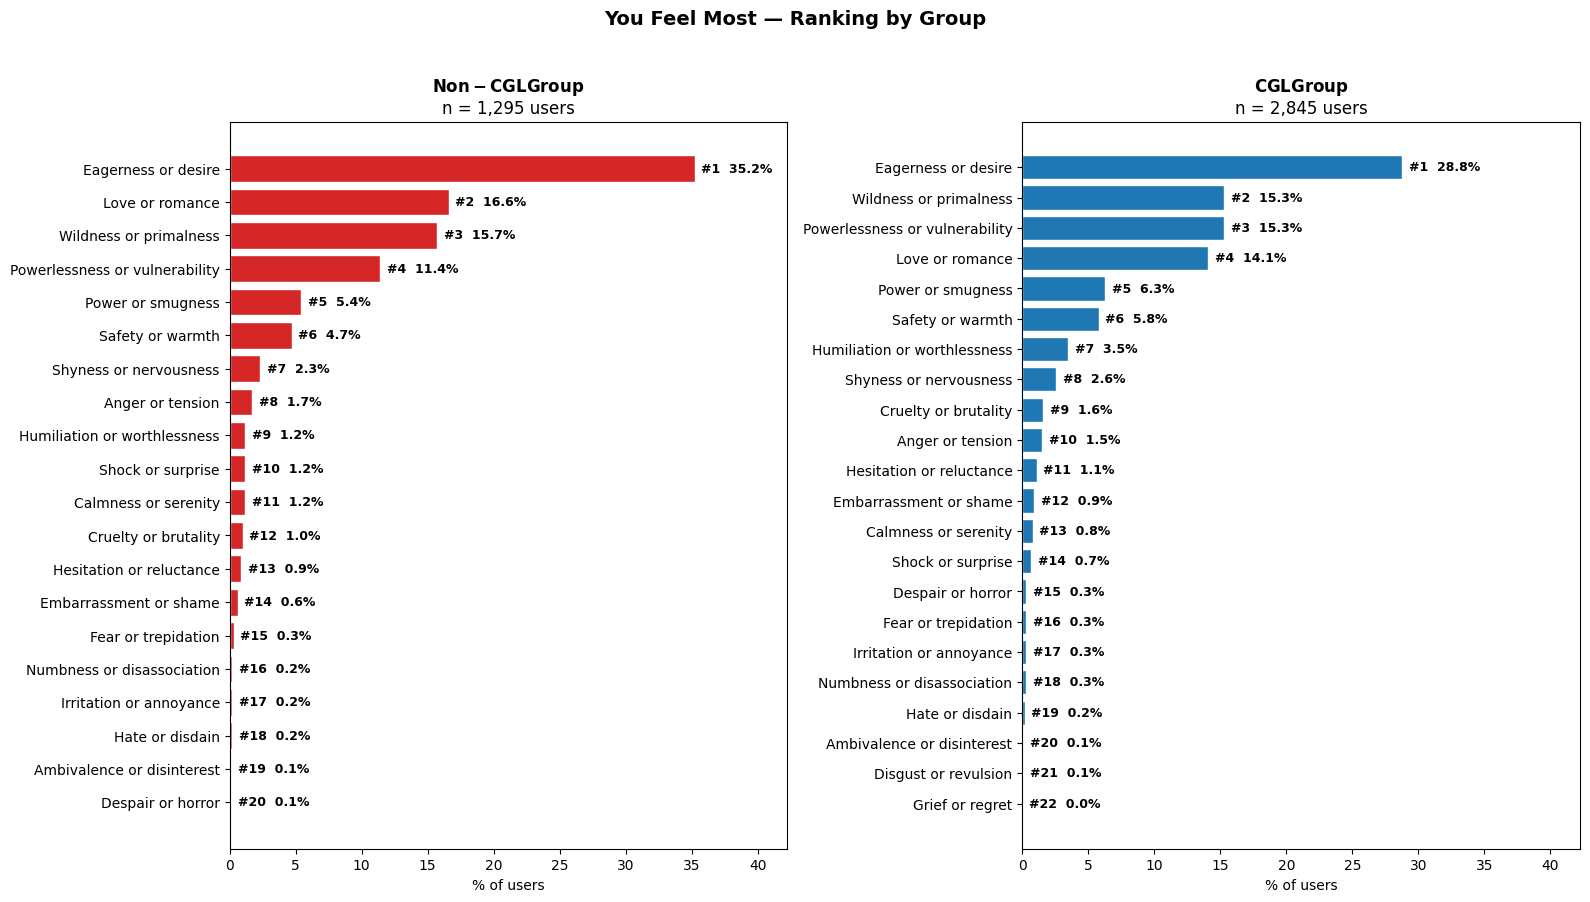

In [112]:
def get_pct_ranked(df_subset):
    return (
        df_subset['youfeelmost']
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .sort_values(ascending=True)   # ascending → highest at top of barh
    )

non_cgl_pct = get_pct_ranked(non_cgl_df)
cgl_pct = get_pct_ranked(cgl_df)

# Use a shared xlim so bar widths compare visually
shared_xmax = max(non_cgl_pct.max(), cgl_pct.max()) * 1.20

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, max(len(non_cgl_pct), len(cgl_pct)) * 0.4)))

for ax, pct, title, n, color in [
    (axes[0], non_cgl_pct, 'Non-CGL Group',  len(non_cgl_df), '#d62728'),
    (axes[1], cgl_pct,     'CGL Group',      len(cgl_df),     '#1f77b4'),
]:
    ax.barh(pct.index, pct.values, color=color, edgecolor='white')
    ax.set_title(f"$\\bf{{{title}}}$\nn = {n:,} users", fontsize=12)
    ax.set_xlabel('% of users')
    ax.set_xlim(0, shared_xmax)

    # Rank numbers + % values  ("#1  31.4%")
    n_items = len(pct)
    for i, (label, value) in enumerate(zip(pct.index, pct.values)):
        rank = n_items - i      # i=0 is the bottom, which is the lowest-ranked
        ax.text(value + 0.5, i, f'#{rank}  {value:.1f}%', va='center', fontsize=9, fontweight='bold')

axes[0].set_ylabel('')
axes[1].set_ylabel('')

fig.suptitle('You Feel Most — Ranking by Group', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Personality

### OCEAN

#### Variables & Functions

In [113]:
# OCEAN: the canonical Big Five personality traits.
# Powerlessness shares the same Likert-style scale but is NOT one of the Big Five —
# it's a kink-adjacent self-report kept in its own list so we don't accidentally
# treat it as a personality trait. See the Powerlessness subsection below.
ocean_cols = ['openness', 'consciensiousness', 'extroversion',
              'neuroticism', 'agreeableness']
power_cols = ['powerlessness']

def expanded_bucket_score(score):
    if score < -3:
        return 'Strong Disagree'
    elif score < 0:
        return 'Disagree'
    elif score == 0:
        return 'Neutral'
    elif score <= 3:
        return 'Agree'
    else:
        return 'Strong Agree'

expanded_bucket_order = ['Strong Disagree', 'Disagree', 'Neutral', 'Agree', 'Strong Agree']

def bucket_score_3(score):
    if score < 0:
        return 'Disagree'
    elif score == 0:
        return 'Neutral'
    else:
        return 'Agree'

bucket_order_3 = ['Disagree', 'Neutral', 'Agree']


#### Analysis

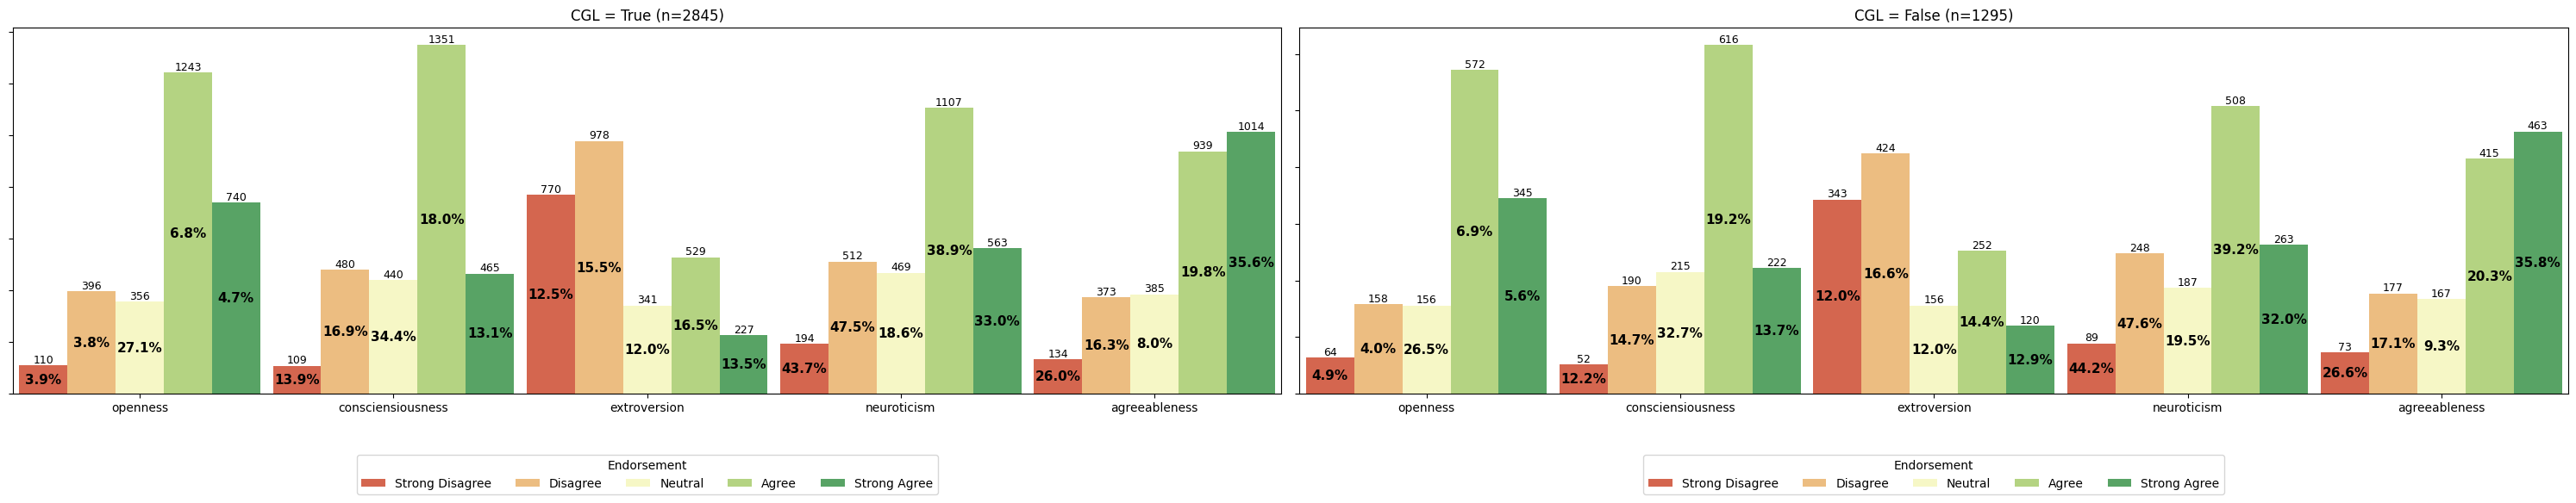

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(30, 6))

for idx, (cgl_flag, ax) in enumerate([('True', axes[0]), ('False', axes[1])]):
    subset = df[df['cgl_flag'].astype(str) == cgl_flag]
    bucket_data = []
    
    for trait in ocean_cols:
        trait_data = subset[trait].dropna()
        
        for score in trait_data:
            bucket = expanded_bucket_score(score)
            bucket_data.append({'trait': trait, 'bucket': bucket})
    
    bucket_df = pd.DataFrame(bucket_data)
    counts = bucket_df.groupby(['trait', 'bucket']).size().reset_index(name='count')
    
    # Calculate percentages within each trait
    counts['total'] = counts.groupby('trait')['count'].transform('sum')
    counts['pct'] = (100 * counts['count'] / counts['total']).round(1)
    
    counts['bucket'] = pd.Categorical(counts['bucket'], categories=expanded_bucket_order, ordered=True)
    counts['trait'] = pd.Categorical(counts['trait'], categories=ocean_cols, ordered=True)
    counts = counts.sort_values(['trait', 'bucket'])
    
    # Plot with wider bars
    sns.barplot(data=counts, x='trait', y='count', hue='bucket', ax=ax,
                palette='RdYlGn', hue_order=expanded_bucket_order, width=0.95)
    
    # Add count labels on top
    for container in ax.containers:
        ax.bar_label(container, fontsize=9)
    
    # Add percentage labels in middle of bars
    for bar, pct in zip(ax.patches, counts['pct']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height / 2,
                f'{pct:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')
    
    title = f'CGL = {cgl_flag} (n={len(subset)})'
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_yticklabels([])
    
    ax.legend(title='Endorsement', bbox_to_anchor=(0.5, -0.15),
              loc='upper center', ncol=5)

plt.tight_layout()
plt.show()


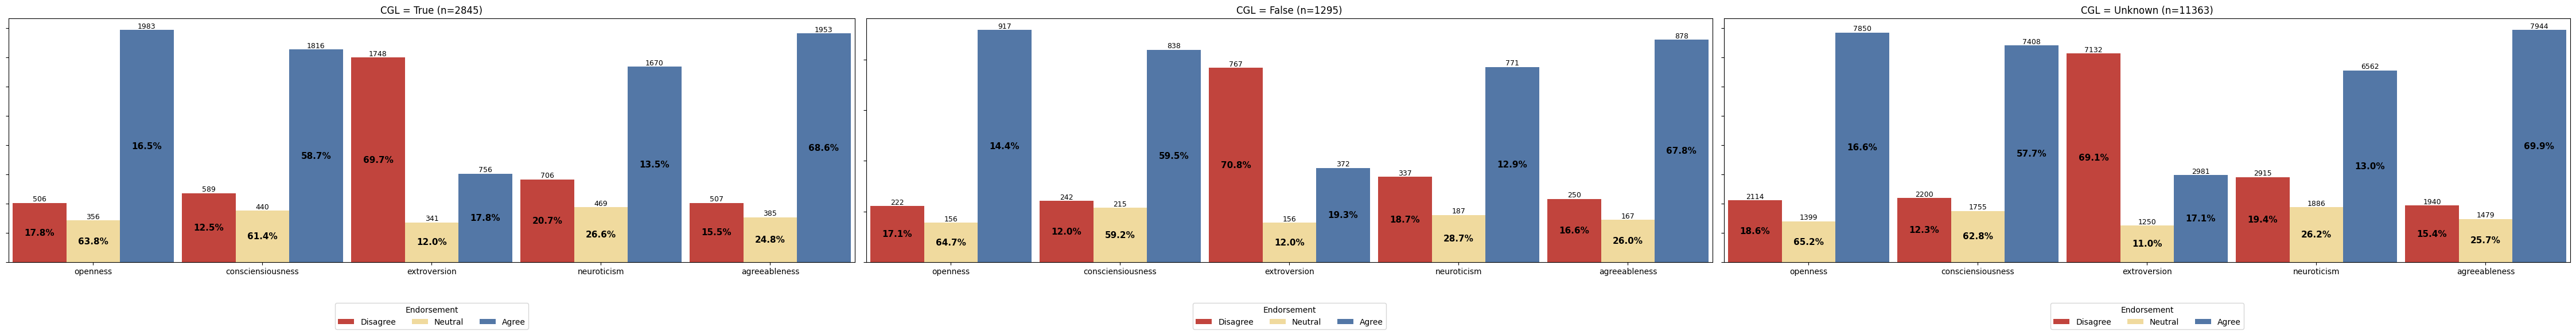

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(45, 6))

for idx, (cgl_flag, ax) in enumerate([('True', axes[0]), ('False', axes[1]), ('Unknown', axes[2])]):
    subset = df[df['cgl_flag'].astype(str) == cgl_flag]
    bucket_data = []
    
    for trait in ocean_cols:
        trait_data = subset[trait].dropna()
        
        for score in trait_data:
            bucket = bucket_score_3(score)
            bucket_data.append({'trait': trait, 'bucket': bucket})
    
    bucket_df = pd.DataFrame(bucket_data)
    counts = bucket_df.groupby(['trait', 'bucket']).size().reset_index(name='count')
    
    counts['total'] = counts.groupby('trait')['count'].transform('sum')
    counts['pct'] = (100 * counts['count'] / counts['total']).round(1)
    
    counts['bucket'] = pd.Categorical(counts['bucket'], categories=bucket_order_3, ordered=True)
    counts['trait'] = pd.Categorical(counts['trait'], categories=ocean_cols, ordered=True)
    counts = counts.sort_values(['trait', 'bucket'])
    
    sns.barplot(data=counts, x='trait', y='count', hue='bucket', ax=ax,
                palette=['#d73027', '#fee090', '#4575b4'], hue_order=bucket_order_3, width=0.95)
    
    for container in ax.containers:
        ax.bar_label(container, fontsize=9)
    
    for bar, pct in zip(ax.patches, counts['pct']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height / 2,
                f'{pct:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')
    
    ax.set_title(f'CGL = {cgl_flag} (n={len(subset)})', fontsize=12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_yticklabels([])
    ax.legend(title='Endorsement', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1244724/2686702231.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1244724/2686702231.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)
/tmp/ipykernel_1244724/2686702231.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1244724/2686702231.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)
/tmp/ipykernel_1244724/2686702231.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

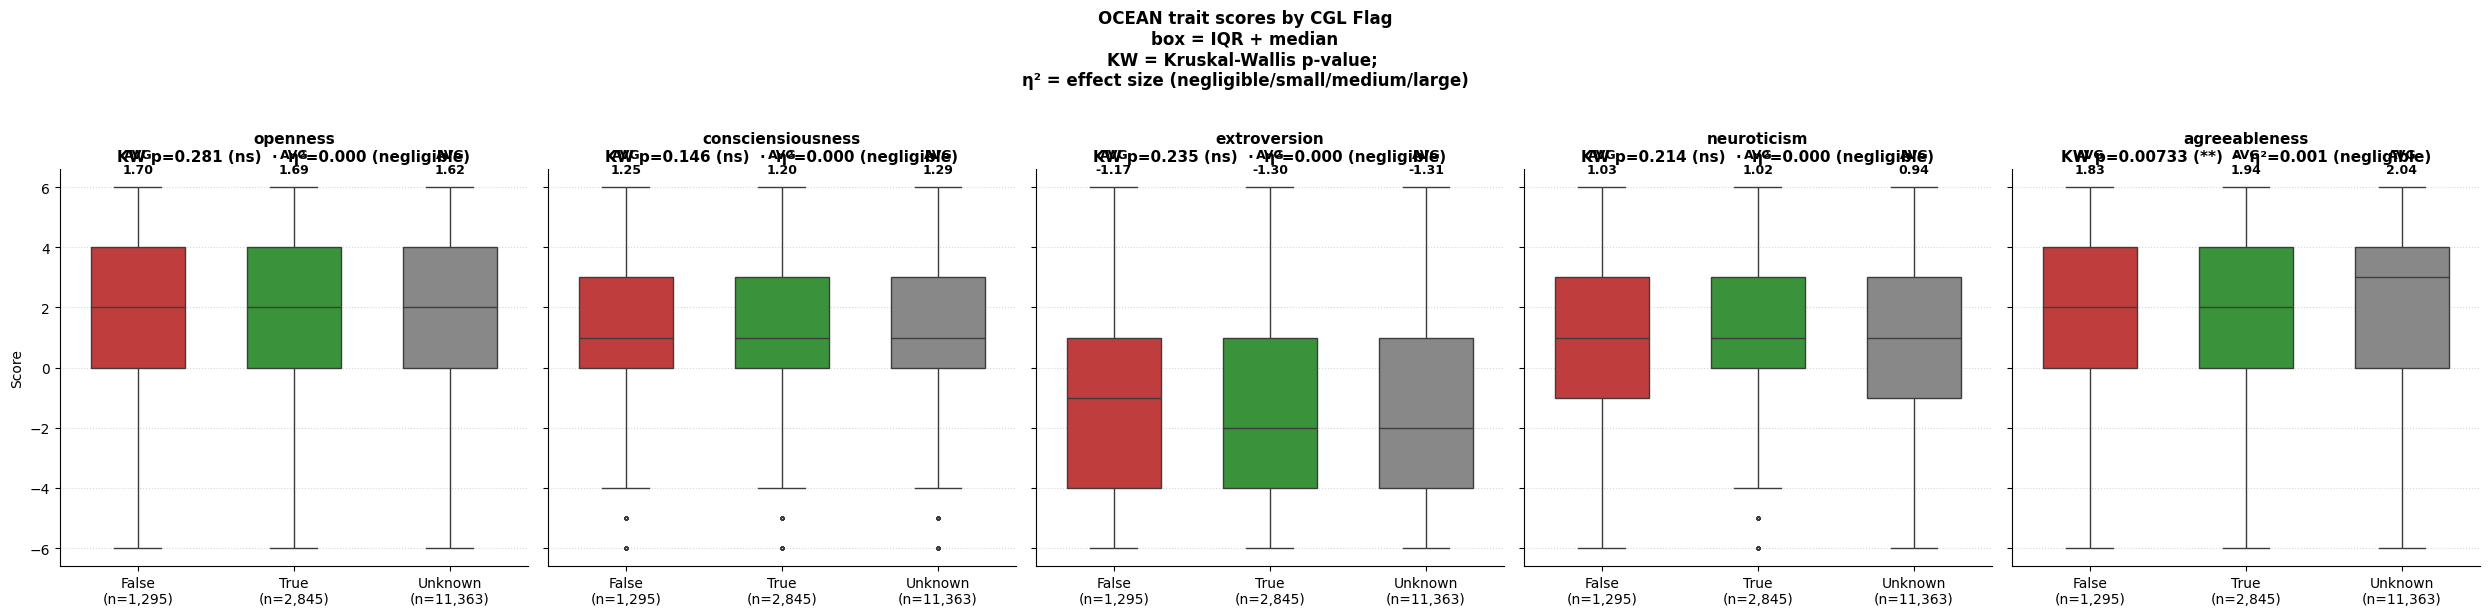

In [116]:
plot_df = df.copy()
plot_df['cgl_flag'] = plot_df['cgl_flag'].astype(str)

flag_order = ['False', 'True', 'Unknown']
palette = {'False': '#d62728', 'True': '#2ca02c', 'Unknown': '#888888'}

n_per_flag = plot_df['cgl_flag'].value_counts()


def eta_squared_kw(h_stat, k, n):
    """Eta-squared effect size for Kruskal-Wallis."""
    return max(0.0, (h_stat - k + 1) / (n - k)) if n > k else 0.0


def interpret_eta(e):
    if e < 0.01: return 'negligible'
    if e < 0.06: return 'small'
    if e < 0.14: return 'medium'
    return 'large'


fig, axes = plt.subplots(1, len(ocean_cols), figsize=(5 * len(ocean_cols), 6), sharey=True)

for ax, trait in zip(axes, ocean_cols):
    sub = plot_df[['cgl_flag', trait]].dropna()
    
    sns.boxplot(
        data=sub, x='cgl_flag', y=trait,
        order=flag_order, palette=palette, ax=ax,
        width=0.6, fliersize=2,
    )

    # Mean as number above each box
    means = sub.groupby('cgl_flag')[trait].mean().reindex(flag_order)
    y_max = sub[trait].max()
    y_min = sub[trait].min()
    text_y = y_max + (y_max - y_min) * 0.03
    for i, m in enumerate(means.values):
        if pd.notna(m):
            ax.text(i, text_y, f'AVG\n{m:.2f}',
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='black')

    # Kruskal-Wallis + eta-squared effect size
    groups = [sub.loc[sub['cgl_flag'] == f, trait].values for f in flag_order]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        n_total = sum(len(g) for g in groups)
        eta = eta_squared_kw(stat, len(groups), n_total)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(
            f'{trait}\n'
            f'KW p={p:.3g} ({sig})  ·  η²={eta:.3f} ({interpret_eta(eta)})',
            fontsize=11, fontweight='bold',
        )
    else:
        ax.set_title(trait, fontsize=11, fontweight='bold')

    xtick_labels = [f'{f}\n(n={int(n_per_flag.get(f, 0)):,})' for f in flag_order]
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel('')
    ax.set_ylabel('Score' if ax is axes[0] else '')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

fig.suptitle(
    'OCEAN trait scores by CGL Flag\n'
    'box = IQR + median'
    '\nKW = Kruskal-Wallis p-value; ' \
    '\nη² = effect size (negligible/small/medium/large)',
    fontweight='bold', fontsize=12, y=1.02,
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1244724/4141820961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1244724/4141820961.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)
/tmp/ipykernel_1244724/4141820961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1244724/4141820961.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)
/tmp/ipykernel_1244724/4141820961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is depre

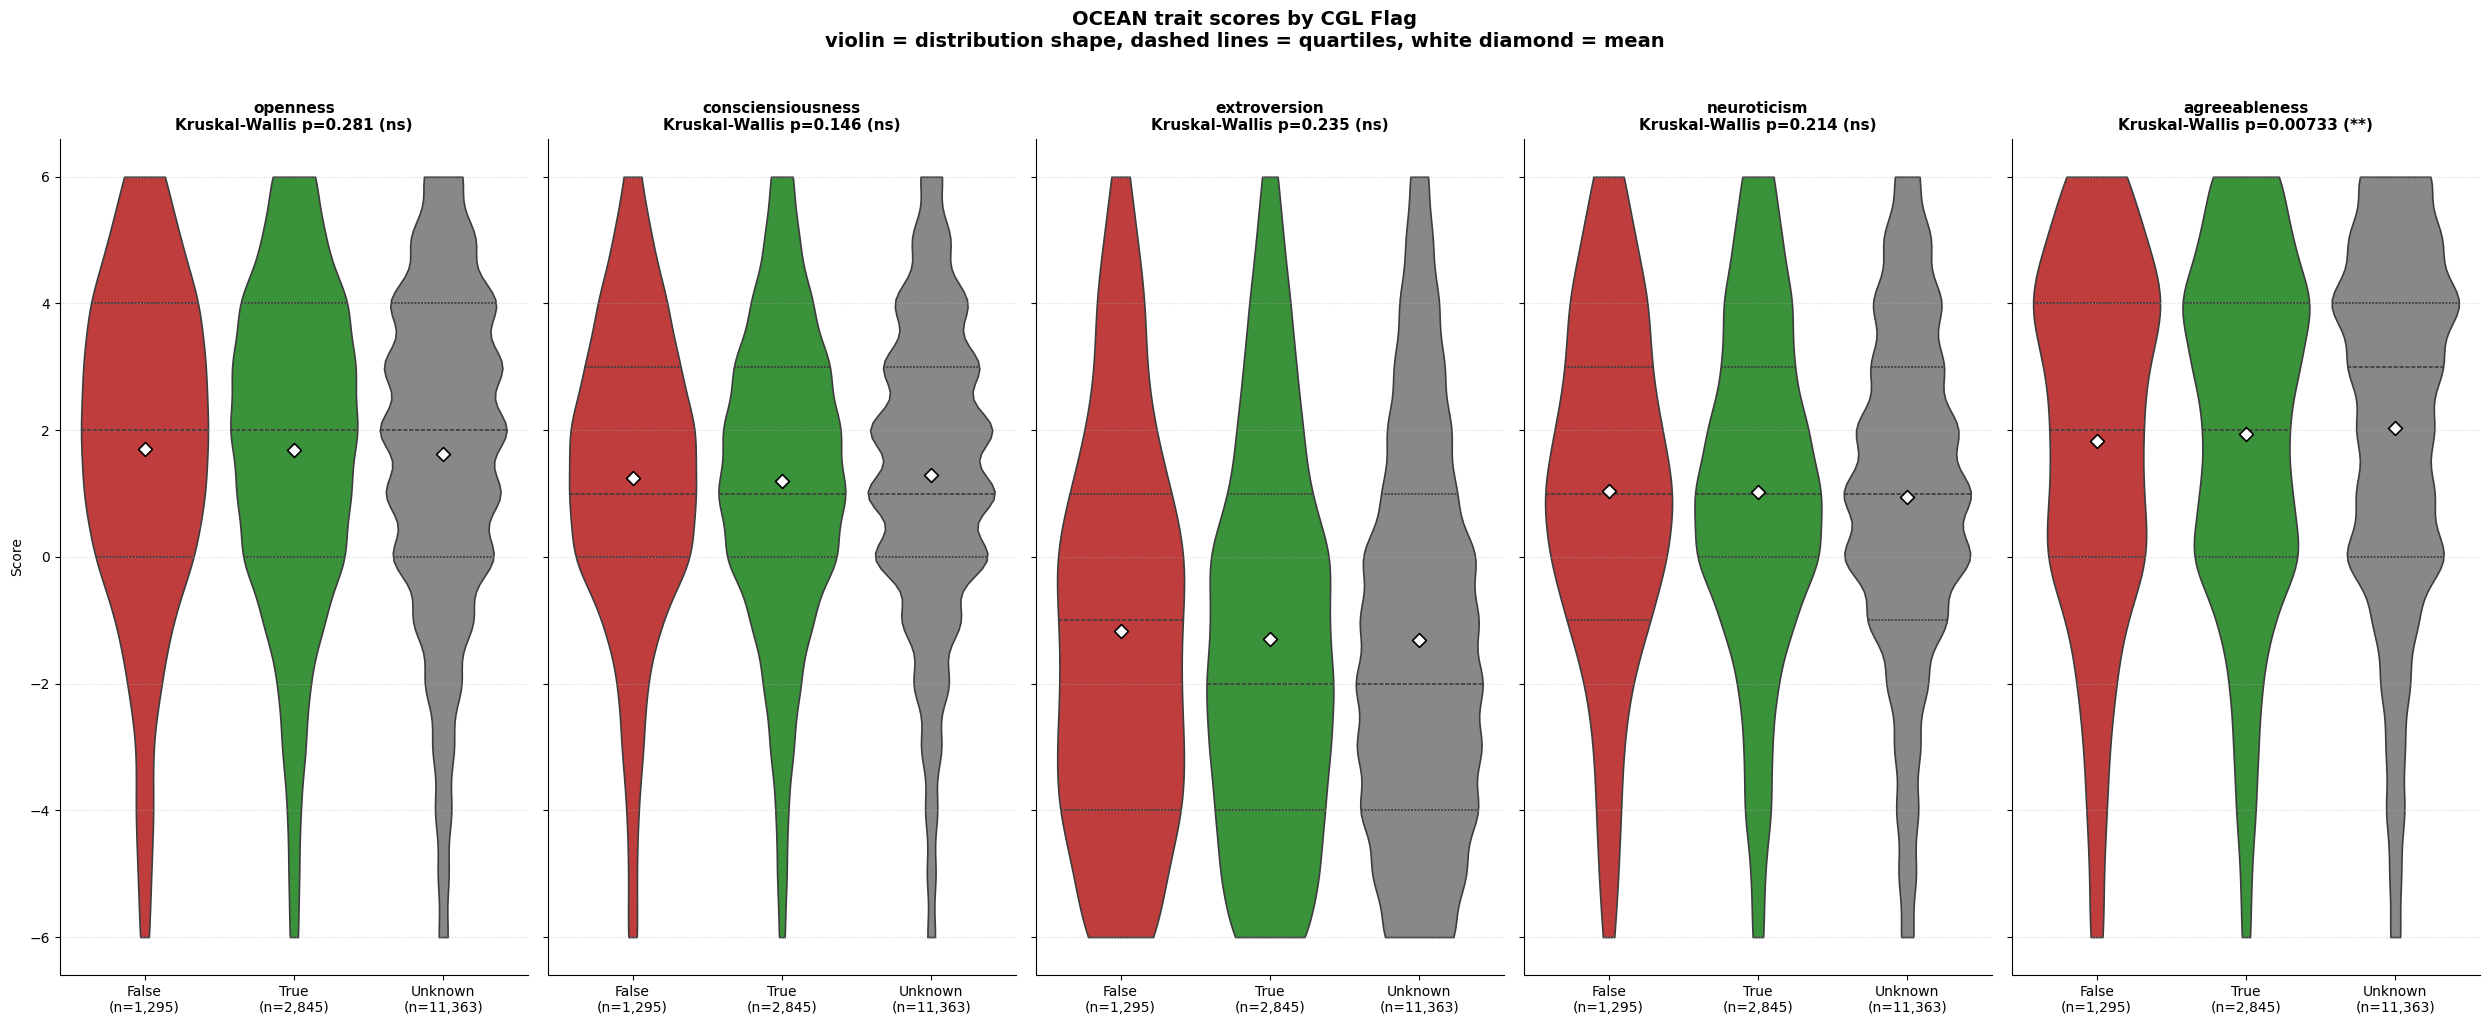

In [117]:
# Use string-form cgl_flag for robust comparison
plot_df = df.copy()
plot_df['cgl_flag'] = plot_df['cgl_flag'].astype(str)

flag_order = ['False', 'True', 'Unknown']
palette = {'False': '#d62728', 'True': '#2ca02c', 'Unknown': '#888888'}

# Group n counts (for x-axis labels)
n_per_flag = plot_df['cgl_flag'].value_counts()

# Layout: one panel per OCEAN trait
fig, axes = plt.subplots(1, len(ocean_cols), figsize=(5 * len(ocean_cols), 10), sharey=True)

for ax, trait in zip(axes, ocean_cols):
    sub = plot_df[['cgl_flag', trait]].dropna()
    
    sns.violinplot(
        data=sub, x='cgl_flag', y=trait,
        order=flag_order, palette=palette, ax=ax,
        inner='quartile',  # shows quartile lines inside the violin
        cut=0,             # don't extend density past the actual data range
        linewidth=1.2,
        width=0.85,
    )
    
    # Overlay mean marker (white diamond) since violin doesn't show it by default
    means = sub.groupby('cgl_flag')[trait].mean().reindex(flag_order)
    ax.scatter(range(len(flag_order)), means.values,
               marker='D', s=50, color='white',
               edgecolor='black', linewidth=1.2, zorder=10)

    # Kruskal-Wallis test across the 3 groups
    groups = [sub.loc[sub['cgl_flag'] == f, trait].values for f in flag_order]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(f'{trait}\nKruskal-Wallis p={p:.3g} ({sig})',
                     fontsize=11, fontweight='bold')
    else:
        ax.set_title(trait, fontsize=11, fontweight='bold')

    # n= under each x-tick label
    xtick_labels = [
        f'{f}\n(n={int(n_per_flag.get(f, 0)):,})' for f in flag_order
    ]
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel('')
    ax.set_ylabel('Score' if ax is axes[0] else '')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

fig.suptitle(
    'OCEAN trait scores by CGL Flag\n'
    'violin = distribution shape, dashed lines = quartiles, white diamond = mean',
    fontweight='bold', fontsize=14, y=1.02,
)

plt.tight_layout()
plt.show()


### Powerlessness (kink-adjacent, not OCEAN)

Powerlessness shares the same Likert scale as the Big Five but is **not** part of OCEAN. It is analyzed in its own subsection because:

1. **Construct**: OCEAN traits (Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism) describe stable personality dimensions. Powerlessness is closer to a kink-relevant attitudinal self-report.
2. **Audience clarity**: a 6-trait "OCEAN" is a construct error for technical readers (peer reviewers, psychologists) and confusing for non-technical readers (anyone Googling OCEAN gets five traits).
3. **Headline question is different**: OCEAN was tested as a predictor of CGL identification (it isn't). The headline question for Powerlessness is whether it tracks **D/s preference** — something we never expected the Big Five to do.

The plots below mirror the OCEAN visualizations so the two constructs can still be compared at a glance.


/tmp/ipykernel_1244724/1970937546.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1244724/1970937546.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


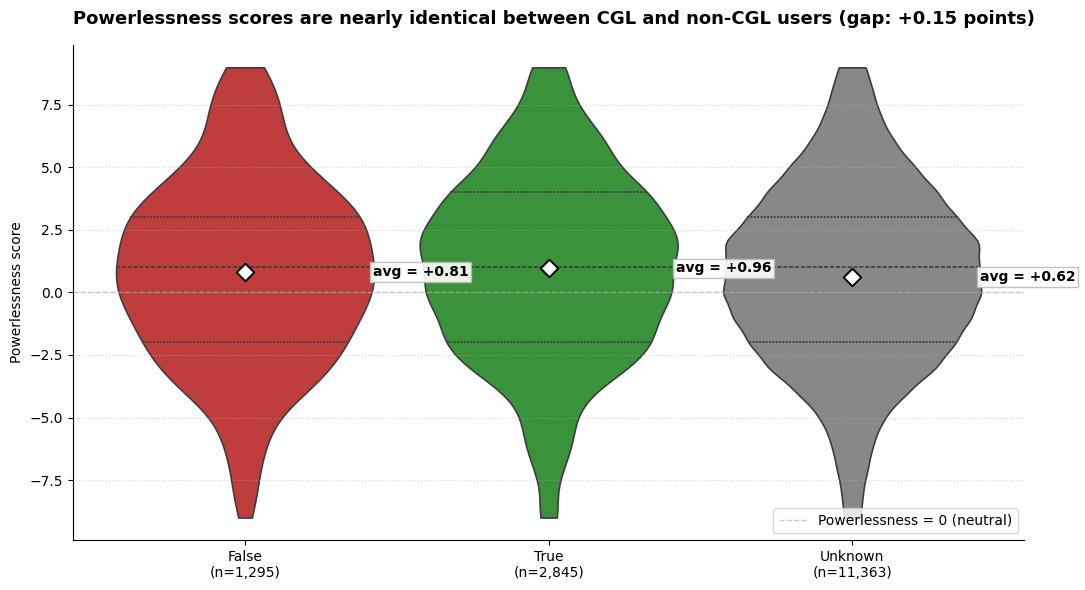


Stats (for curious readers)
───────────────────────────
Kruskal-Wallis omnibus across the 3 CGL groups: H = 22.1, p = 1.59e-05 (***)
Effect size η² = 0.001  (negligible <0.01 · small <0.06 · medium <0.14 · large ≥0.14)

With this n, even a tiny gap can be 'statistically significant'. The magnitude
(0.15 points on the Powerlessness scale) is what tells you whether the
difference matters in practice.



In [118]:
# Powerlessness — distribution by CGL flag.
# Headline finding sits in the title; the chart confirms it visually.
plot_df = df.copy()
plot_df['cgl_flag'] = plot_df['cgl_flag'].astype(str)

flag_order = ['False', 'True', 'Unknown']
palette = {'False': '#d62728', 'True': '#2ca02c', 'Unknown': '#888888'}
n_per_flag = plot_df['cgl_flag'].value_counts()

sub = plot_df[['cgl_flag', 'powerlessness']].dropna()
means = sub.groupby('cgl_flag')['powerlessness'].mean()

# Compute the headline finding before plotting.
gap = means.get('True', float('nan')) - means.get('False', float('nan'))
if abs(gap) < 0.3:
    headline = (
        f'Powerlessness scores are nearly identical between CGL and non-CGL users '
        f'(gap: {gap:+.2f} points)'
    )
else:
    direction = 'HIGHER' if gap > 0 else 'LOWER'
    headline = (
        f'CGL users score {abs(gap):.1f} points {direction} on Powerlessness '
        f'than non-CGL users'
    )

# One chart, not two. Violin is more intuitive than a box for a non-technical reader.
fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(
    data=sub, x='cgl_flag', y='powerlessness',
    order=flag_order, palette=palette, ax=ax,
    inner='quartile', cut=0, linewidth=1.2, width=0.85,
)

# Mean diamond + inline label on each violin
ax.scatter(
    range(len(flag_order)),
    [means.get(f, float('nan')) for f in flag_order],
    marker='D', s=80, color='white',
    edgecolor='black', linewidth=1.4, zorder=10,
)
for i, f in enumerate(flag_order):
    m = means.get(f, float('nan'))
    if pd.notna(m):
        ax.text(
            i + 0.42, m, f'avg = {m:+.2f}',
            ha='left', va='center', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='#bbbbbb', alpha=0.9, pad=2),
        )

ax.axhline(0, color='#aaa', linestyle='--', linewidth=1, alpha=0.6,
           label='Powerlessness = 0 (neutral)')

xtick_labels = [f'{f}\n(n={int(n_per_flag.get(f, 0)):,})' for f in flag_order]
ax.set_xticklabels(xtick_labels)
ax.set_xlabel('')
ax.set_ylabel('Powerlessness score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(loc='lower right', frameon=True)

ax.set_title(headline, fontweight='bold', fontsize=13, loc='left', pad=15)
plt.tight_layout()
plt.show()

# Stats kept out of the title — surfaced here for curious readers.
groups = [sub.loc[sub['cgl_flag'] == f, 'powerlessness'].values for f in flag_order]
groups = [g for g in groups if len(g) > 0]
stat, p = kruskal(*groups)
n_total = sum(len(g) for g in groups)
eta = max(0.0, (stat - len(groups) + 1) / (n_total - len(groups))) if n_total > len(groups) else 0.0
sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
print(f"""
Stats (for curious readers)
───────────────────────────
Kruskal-Wallis omnibus across the 3 CGL groups: H = {stat:.1f}, p = {p:.3g} ({sig})
Effect size η² = {eta:.3f}  (negligible <0.01 · small <0.06 · medium <0.14 · large ≥0.14)

With this n, even a tiny gap can be 'statistically significant'. The magnitude
({abs(gap):.2f} points on the Powerlessness scale) is what tells you whether the
difference matters in practice.
""")


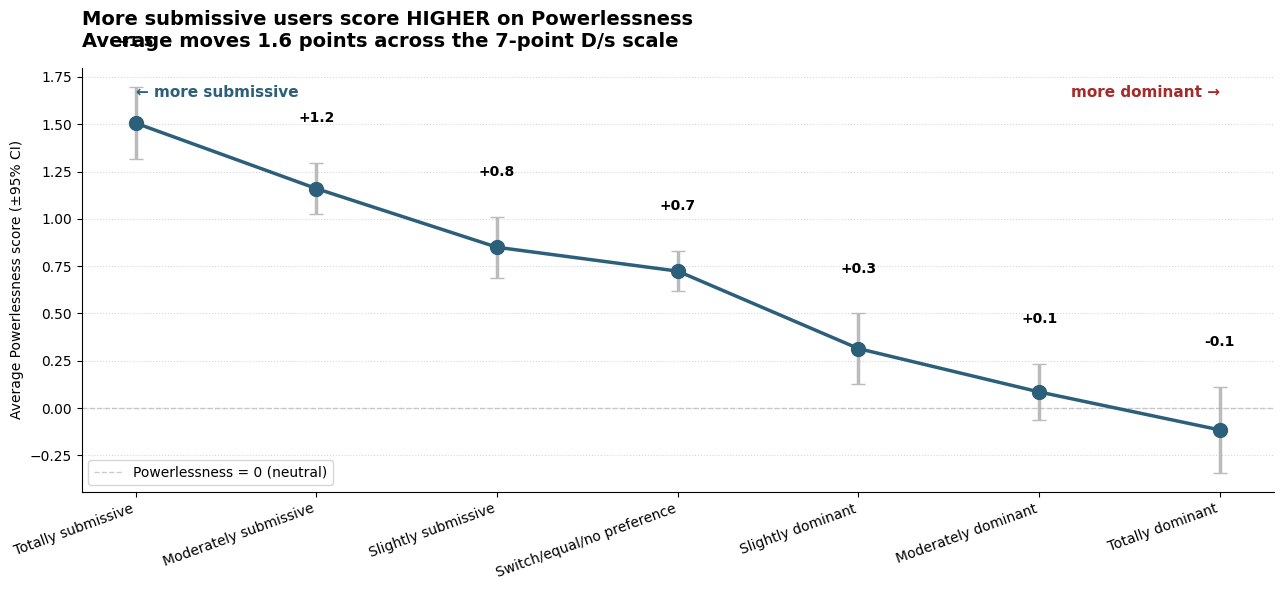


Stats (for curious readers)
───────────────────────────
Spearman ρ = -0.137  (***, n = 15,095)
  ρ near 0 → no relationship between Powerlessness and D/s preference
  ρ < 0    → higher Powerlessness goes with more SUBMISSIVE D/s preference
  ρ > 0    → higher Powerlessness goes with more DOMINANT D/s preference

A monotone slope across all 7 D/s levels (rather than just a sub-vs-dom split)
means Powerlessness behaves like a graded dimension, not a binary kink/no-kink
switch — the more submissive someone is, the higher their Powerlessness, level
by level.



In [119]:
# Powerlessness × D/s Preference — the headline question for this variable.
# Title carries the finding; chart confirms direction and shape; stats sit below.
from scipy.stats import spearmanr

sub = df[['powerlessness', 'ds_preference']].dropna().copy()
sub['ds_rank'] = sub['ds_preference'].map(ds_rank)

rho, p_rho = spearmanr(sub['ds_rank'], sub['powerlessness'])

grouped = (
    sub.groupby('ds_preference')['powerlessness']
       .agg(['mean', 'std', 'count'])
       .reindex(ds_order)
)
grouped['ci'] = 1.96 * grouped['std'] / np.sqrt(grouped['count'])

# Plain-language headline: how much does the average move across the scale?
sub_end = grouped.loc['Totally submissive', 'mean']
dom_end = grouped.loc['Totally dominant', 'mean']
range_pts = sub_end - dom_end
direction_word = 'HIGHER' if range_pts > 0 else 'LOWER'
headline = (
    f'More submissive users score {direction_word} on Powerlessness\n'
    f'Average moves {abs(range_pts):.1f} points from Totally Dominant '
    f'(left) to Totally Submissive (right)'
)
# ds_order has Totally submissive at index 0, Totally dominant at index 6 —
# so on the chart, sub is on the LEFT and dom is on the RIGHT. Update the
# headline accordingly:
headline = (
    f'More submissive users score {direction_word} on Powerlessness\n'
    f'Average moves {abs(range_pts):.1f} points across the 7-point D/s scale'
)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(ds_order))
ax.errorbar(
    x, grouped['mean'], yerr=grouped['ci'],
    fmt='o-', linewidth=2.5, markersize=10,
    color='#2c5f7a', ecolor='#bbbbbb', capsize=5,
)

# Inline mean labels above each point — no n=, kept clean.
for i, (_, row) in enumerate(grouped.iterrows()):
    if pd.notna(row['mean']):
        ax.text(
            i, row['mean'] + row['ci'] + 0.20,
            f'{row["mean"]:+.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
        )

ax.axhline(0, color='#aaa', linestyle='--', linewidth=1, alpha=0.6,
           label='Powerlessness = 0 (neutral)')

# Orientation labels in the upper corners — quick read on which side is which.
y_min, y_max = ax.get_ylim()
y_label_pos = y_max - (y_max - y_min) * 0.04
ax.text(0, y_label_pos, '← more submissive',
        ha='left', va='top', fontsize=11, fontweight='bold', color='#2c5f7a')
ax.text(len(ds_order) - 1, y_label_pos, 'more dominant →',
        ha='right', va='top', fontsize=11, fontweight='bold', color='#a52a2a')

ax.set_xticks(x)
ax.set_xticklabels(ds_order, rotation=20, ha='right')
ax.set_xlabel('')
ax.set_ylabel('Average Powerlessness score (±95% CI)')
ax.set_title(headline, fontweight='bold', fontsize=14, loc='left', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()

sig = '***' if p_rho < 0.001 else ('**' if p_rho < 0.01 else ('*' if p_rho < 0.05 else 'ns'))
print(f"""
Stats (for curious readers)
───────────────────────────
Spearman ρ = {rho:+.3f}  ({sig}, n = {len(sub):,})
  ρ near 0 → no relationship between Powerlessness and D/s preference
  ρ < 0    → higher Powerlessness goes with more SUBMISSIVE D/s preference
  ρ > 0    → higher Powerlessness goes with more DOMINANT D/s preference

A monotone slope across all 7 D/s levels (rather than just a sub-vs-dom split)
means Powerlessness behaves like a graded dimension, not a binary kink/no-kink
switch — the more submissive someone is, the higher their Powerlessness, level
by level.
""")


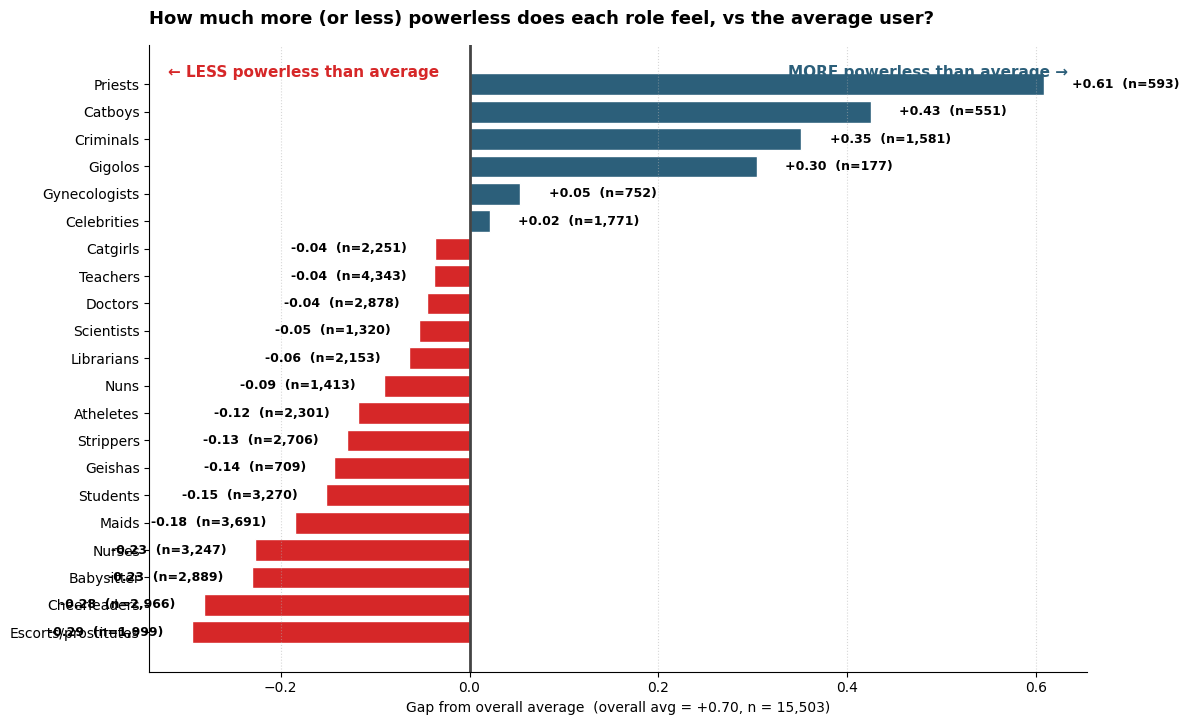


How to read this chart
──────────────────────
Each bar = the GAP between this role's average Powerlessness score and the
overall average (+0.70 for n = 15,503).
  +0.50 → users in this role score about half a point HIGHER than average
  -0.50 → users in this role score about half a point LOWER than average
   0.00 → this role's users feel as powerless as a typical respondent

Why a gap, not a raw score? It removes the cognitive step of comparing two
numbers. The chart reads as direction + magnitude in one glance.

Roles with fewer than 30 responders are excluded so the means stay stable.

Cross-reference: roles that lean strongly Sub on the Role vs D/s chart should
sit on the right (blue, MORE powerless) end here. Roles that lean Dom should
sit on the left (red, LESS powerless) end. A mismatch is the interesting case.



In [120]:
# Powerlessness × Role — show GAP FROM AVERAGE so readers don't have to
# mentally subtract two numbers. A reader sees "+0.4" and immediately knows
# both direction and size.
role_cols = df.filter(like='role_').columns.tolist()

overall_mean = df['powerlessness'].mean()
overall_n = df['powerlessness'].notna().sum()

power_by_role = []
for r_col in role_cols:
    role_sub = df[(df[r_col] == 1) & df['powerlessness'].notna()]
    if len(role_sub) >= 30:  # roles with too few responders → unstable mean
        power_by_role.append({
            'role': r_col.replace('role_', ''),
            'mean': role_sub['powerlessness'].mean(),
            'n': len(role_sub),
        })

power_role_df = (
    pd.DataFrame(power_by_role)
      .set_index('role')
      .assign(gap=lambda d: d['mean'] - overall_mean)
      .sort_values('gap')   # ascending → most negative at top of barh
)

fig, ax = plt.subplots(figsize=(12, max(6, 0.35 * len(power_role_df))))
colors = ['#d62728' if g < 0 else '#2c5f7a' for g in power_role_df['gap']]
ax.barh(power_role_df.index, power_role_df['gap'],
        color=colors, edgecolor='white')
ax.axvline(0, color='#444', linestyle='-', linewidth=2)

# Bar-end labels — gap and n
for i, (_, row) in enumerate(power_role_df.iterrows()):
    offset = 0.03 if row['gap'] >= 0 else -0.03
    ha = 'left' if row['gap'] >= 0 else 'right'
    ax.text(
        row['gap'] + offset, i,
        f'{row["gap"]:+.2f}  (n={int(row["n"]):,})',
        va='center', ha=ha, fontsize=9, fontweight='bold',
    )

# Orientation labels at the top of each side
xlim = ax.get_xlim()
top_y = len(power_role_df) - 0.3
ax.text(xlim[0] + (xlim[1] - xlim[0]) * 0.02, top_y,
        '← LESS powerless than average',
        ha='left', va='top', fontsize=11, fontweight='bold', color='#d62728')
ax.text(xlim[1] - (xlim[1] - xlim[0]) * 0.02, top_y,
        'MORE powerless than average →',
        ha='right', va='top', fontsize=11, fontweight='bold', color='#2c5f7a')

ax.set_xlabel(f'Gap from overall average  (overall avg = {overall_mean:+.2f}, n = {overall_n:,})')
ax.set_ylabel('')
ax.set_title(
    'How much more (or less) powerless does each role feel, vs the average user?',
    fontweight='bold', fontsize=13, loc='left', pad=15,
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"""
How to read this chart
──────────────────────
Each bar = the GAP between this role's average Powerlessness score and the
overall average ({overall_mean:+.2f} for n = {overall_n:,}).
  +0.50 → users in this role score about half a point HIGHER than average
  -0.50 → users in this role score about half a point LOWER than average
   0.00 → this role's users feel as powerless as a typical respondent

Why a gap, not a raw score? It removes the cognitive step of comparing two
numbers. The chart reads as direction + magnitude in one glance.

Roles with fewer than 30 responders are excluded so the means stay stable.

Cross-reference: roles that lean strongly Sub on the Role vs D/s chart should
sit on the right (blue, MORE powerless) end here. Roles that lean Dom should
sit on the left (red, LESS powerless) end. A mismatch is the interesting case.
""")


# Summary

We tested whether CGL identification is predicted by Big Five personality structure (Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism). Across all five OCEAN traits, standardized mean differences between CGL and non-CGL users were trivial (all |d| < 0.10), indicating that broad personality structure does not meaningfully differentiate CGL-identifying users from the rest of the sample. CGL identification appears to be orthogonal to personality as captured by the Big Five — it is better understood as a relational/behavioral preference than as a personality trait.

In [121]:
# Within-CGL personality differences — do caregivers vs littles differ on OCEAN?
# (Powerlessness is now analyzed in its own subsection above.)
within_cgl = cgl_df.groupby('soft_erotic_caretaker/caretakee dynamics')[ocean_cols].agg(['mean', 'std'])
print(within_cgl)


                                          openness            \
                                              mean       std   
soft_erotic_caretaker/caretakee dynamics                       
0                                         1.658741  2.588395   
1                                         1.803136  2.467504   

                                         consciensiousness            \
                                                      mean       std   
soft_erotic_caretaker/caretakee dynamics                               
0                                                 1.196830  2.370990   
1                                                 1.221254  2.495686   

                                         extroversion           neuroticism  \
                                                 mean       std        mean   
soft_erotic_caretaker/caretakee dynamics                                      
0                                           -1.209159  3.025126    0.959489   
1 

In [122]:
# 2. Within-CGL personality differences — do caregivers vs littles differ?
within_cgl = cgl_df.groupby('soft_erotic_caretaker/caretakee dynamics')[ocean_cols].agg(['mean', 'std'])
print(within_cgl)


                                          openness            \
                                              mean       std   
soft_erotic_caretaker/caretakee dynamics                       
0                                         1.658741  2.588395   
1                                         1.803136  2.467504   

                                         consciensiousness            \
                                                      mean       std   
soft_erotic_caretaker/caretakee dynamics                               
0                                                 1.196830  2.370990   
1                                                 1.221254  2.495686   

                                         extroversion           neuroticism  \
                                                 mean       std        mean   
soft_erotic_caretaker/caretakee dynamics                                      
0                                           -1.209159  3.025126    0.959489   
1 

In [123]:
# Map ordinal variety categories to numeric (1-7)
variety_7_map = {
    'Very narrow': 1,
    'A little narrow': 2,
    'Somewhat narrow': 3,
    'Equally narrow and broad': 4,
    'A little broad': 5,
    'Somewhat broad': 6,
    'Very broad': 7,
}
df['variety_num'] = df['sexual_interest_variety'].map(variety_7_map)

# Sanity check — make sure mapping covered all values
print("Mapped values:", df['variety_num'].value_counts(dropna=False).sort_index())
print("Unmapped (NaN):", df['variety_num'].isna().sum())

# OCEAN vs variety: Spearman correlation
print("\n=== OCEAN vs Sexual Interest Variety (Spearman ρ) ===")
for trait in ocean_cols:
    mask = df[trait].notna() & df['variety_num'].notna()
    r = df.loc[mask, trait].corr(df.loc[mask, 'variety_num'], method='spearman')
    print(f"  {trait:20s} ρ = {r:+.3f}")



Mapped values: variety_num
1.0     643
2.0    1754
3.0    1261
4.0    3159
5.0    2603
6.0    3687
7.0    2392
NaN       4
Name: count, dtype: int64
Unmapped (NaN): 4

=== OCEAN vs Sexual Interest Variety (Spearman ρ) ===
  openness             ρ = +0.085
  consciensiousness    ρ = +0.004
  extroversion         ρ = +0.070
  neuroticism          ρ = -0.041
  agreeableness        ρ = +0.023


In [124]:
# 1. Roles vs variety — is it about WHAT you're into, not WHO you are?
role_cols = df.filter(like='role_').columns.tolist()
for r in role_cols:
    rho = df[r].corr(df['variety_num'], method='spearman')
    print(f"  {r.replace('role_','')}: ρ = {rho:+.2f}")


  Atheletes: ρ = +0.10
  Babysitter: ρ = +0.13
  Catboys: ρ = +0.07
  Catgirls: ρ = +0.13
  Celebrities: ρ = +0.10
  Cheerleaders: ρ = +0.13
  Criminals: ρ = +0.08
  Doctors: ρ = +0.10
  Escorts/prostitutes: ρ = +0.13
  Geishas: ρ = +0.08
  Gigolos: ρ = +0.04
  Gynecologists: ρ = +0.06
  Librarians: ρ = +0.10
  Maids: ρ = +0.13
  Nuns: ρ = +0.11
  Nurses: ρ = +0.13
  Priests: ρ = +0.05
  Scientists: ρ = +0.09
  Strippers: ρ = +0.14
  Students: ρ = +0.14
  Teachers: ρ = +0.12


In [125]:
# 2. Caretaker/caretakee dynamic vs variety — is the D-s structure the predictor?
print(df.groupby('soft_erotic_caretaker/caretakee dynamics')['variety_num'].agg(['mean', 'median', 'std', 'count']))


                                              mean  median       std  count
soft_erotic_caretaker/caretakee dynamics                                   
0                                         4.651957     5.0  1.722743  13846
1                                         4.863884     5.0  1.692880   1653


In [126]:
# 3. Within-CGL: does caretaker vs caretakee differ on personality?
within_cgl = cgl_df.groupby('soft_erotic_caretaker/caretakee dynamics')[ocean_cols].mean().T
print(within_cgl)


soft_erotic_caretaker/caretakee dynamics         0         1
openness                                  1.658741  1.803136
consciensiousness                         1.196830  1.221254
extroversion                             -1.209159 -1.648084
neuroticism                               0.959489  1.259582
agreeableness                             1.856891  2.250871


In [127]:
role_cols = df.filter(like='role_').columns.tolist()
role_variety = []
for r in role_cols:
    role_users = df.loc[df[r] == 1, 'variety_num'].dropna()
    non_role = df.loc[df[r] == 0, 'variety_num'].dropna()
    if len(role_users) > 30 and len(non_role) > 30:
        pooled_sd = ((role_users.std()**2 + non_role.std()**2) / 2) ** 0.5
        d = (role_users.mean() - non_role.mean()) / pooled_sd
        role_variety.append({
            'role': r.replace('role_', ''),
            'mean_with':  round(role_users.mean(), 2),
            'mean_without': round(non_role.mean(), 2),
            'd': round(d, 2),
            'n_with': len(role_users),
        })
print(pd.DataFrame(role_variety).sort_values('d', key=abs, ascending=False).to_string(index=False))


               role  mean_with  mean_without    d  n_with
Escorts/prostitutes       5.23          4.59 0.38    1999
            Geishas       5.28          4.65 0.38     709
               Nuns       5.26          4.62 0.38    1413
            Catboys       5.26          4.65 0.35     551
           Catgirls       5.16          4.59 0.34    2251
          Strippers       5.15          4.57 0.34    2706
       Cheerleaders       5.13          4.57 0.33    2966
           Students       5.10          4.56 0.32    3270
         Babysitter       5.11          4.58 0.31    2889
            Gigolos       5.21          4.67 0.31     177
             Nurses       5.08          4.57 0.30    3247
         Scientists       5.14          4.63 0.30    1320
              Maids       5.06          4.55 0.30    3691
        Celebrities       5.11          4.62 0.29    1771
          Atheletes       5.09          4.60 0.29    2301
         Librarians       5.09          4.61 0.28    2153
          Crim

In [128]:
df['n_roles'] = df[role_cols].sum(axis=1)
rho = df['n_roles'].corr(df['variety_num'], method='spearman')
print(f"Number of roles vs variety: ρ = {rho:.3f}")

Number of roles vs variety: ρ = 0.149


Variety preference is dose-dependent on role endorsement (ρ ≈ 0.X). Each additional role a respondent endorses corresponds to broader self-reported variety, regardless of role type. This suggests variety preference is best understood as a scalar measure of fantasy openness rather than a categorical kink-vs-vanilla distinction.

Variety preference isn't predicted by which role someone endorses — it's predicted by whether they endorse roles at all. The fact that single-role d is similar to or larger than total-role-count ρ is itself informative. It means "having any role" matters more than "having lots of roles." The relationship plateaus.

The fact that 21 different roles all produce ~0.3 effect sizes strongly suggests there's a single underlying construct doing the work: a general inclination toward role-based fantasy/play. The role columns are essentially measuring the same latent thing — "openness to role play" — and that latent thing is what correlates with variety.

The "0 vs any" boundary does most of the work — going from 0 to 1 role is a bigger jump than 1 to 5. The relationship may be non-linear.
People endorse multiple roles for reasons unrelated to variety — someone might have 8 roles all because they're into a specific aesthetic, not because they're "broad."

Compare effect sizes across all the things you've tested:

- Predictor of variety	Effect size
- Any single OCEAN trait	|ρ| ≤ 0.085 (trivial)
- CGL identification	d ≈ 0.10 (trivial)
- Caretaker dynamic	d ≈ 0.12 (trivial)
- Single role endorsement	d ≈ 0.23–0.38 (small)
- Number of roles endorsed	ρ = 0.15 (small, your best)


# Summary Doc Output

In [129]:
role_cols = df.filter(like='role_').columns.tolist()
df['n_roles'] = df[role_cols].sum(axis=1)

# Spearman: does endorsing more roles predict broader variety?
rho = df['n_roles'].corr(df['variety_num'], method='spearman')
print(f"n_roles vs variety: ρ = {rho:.3f}")

# Also: variety mean by number of roles
print("\nVariety by role count:")
print(df.groupby('n_roles')['variety_num'].agg(['mean', 'count']).round(2))


n_roles vs variety: ρ = 0.149

Variety by role count:
         mean  count
n_roles             
0        4.52  10111
1        4.70    102
2        4.39    224
3        4.60    339
4        4.74    424
5        4.68    514
6        4.75    487
7        4.94    519
8        4.97    487
9        5.14    484
10       5.00    397
11       5.17    356
12       5.34    264
13       5.22    225
14       5.45    192
15       5.53    115
16       5.36     91
17       5.51     67
18       5.76     37
19       5.55     31
20       5.86     14
21       5.68     19


# NSFW Preferences by CGL Status

Do NSFW preferences cluster with CGL identification?

This section compares endorsement rates on sexual acts, positions, and preference categories (common/uncommon) between CGL-positive and CGL-negative respondents.

## Data Source

In [130]:
# Load NSFW preferences data
nsfw_df = pd.read_csv('../database/BKS_nsfw_preferences.csv')


nsfw_df['cgl_flag'] = np.where(
    nsfw_df['cgl'] >= 1, True,
    np.where(nsfw_df['cgl'] == 0, False, "Unknown")
)
print(f'NSFW data shape: {nsfw_df.shape}')
print(f'CGL flag distribution in NSFW data:')
print(nsfw_df['cgl_flag'].value_counts())

NSFW data shape: (15503, 109)
CGL flag distribution in NSFW data:
cgl_flag
Unknown    11363
True        2845
False       1295
Name: count, dtype: int64


In [131]:
for col in nsfw_df.columns:
    print(col)

respondent_id
pos_69
pos_cow-girl
pos_cowgirl
pos_doggystyle
pos_missionary
pos_reverse cowgirl
pos_spooning
pos_standing up
act_anal fingering
act_ass-to-mouth/rimming
act_creampies (ejaculating into a vagina)
act_creampies (éjaculer dans un vagin)
act_destination vaginale
act_facefucking
act_facesitting
act_facials (ejaculating onto a face)
act_fessée
act_fingering mouths
act_fisting (anuses)
act_fisting (vaginas)
act_hair pulling
act_handjobs
act_pegging
act_rimming
act_rimmissement
act_spanking
act_squirting
act_vaginal fingering
common_appearance states: static
common_body parts: normal, non-genital
common_bondage
common_clothing
common_eagerness
common_exhibitionism/voyeurism
common_gentleness
common_humiliation
common_multiple partners
common_mythical/fictional creatures
common_nonconsent
common_power dynamics & d/s
common_roles
common_sadomasochism
common_sensory
common_toys
uncommon_abnormal bodies and body parts
uncommon_age: nonstandard
uncommon_bestiality/creatures
uncommon

In [132]:
# Identify NSFW variable categories
act_cols = [c for c in nsfw_df.columns if c.startswith('act_')]
pos_cols = [c for c in nsfw_df.columns if c.startswith('pos_')]
common_cols = [c for c in nsfw_df.columns if c.startswith('common_')]
uncommon_cols = [c for c in nsfw_df.columns if c.startswith('uncommon_')]

print(f'NSFW variables by category:')
print(f'  Acts: {len(act_cols)}')
print(f'  Positions: {len(pos_cols)}')
print(f'  Common preferences: {len(common_cols)}')
print(f'  Uncommon preferences: {len(uncommon_cols)}')
print(f'  Total NSFW-specific: {len(act_cols) + len(pos_cols) + len(common_cols) + len(uncommon_cols)}')

NSFW variables by category:
  Acts: 20
  Positions: 8
  Common preferences: 16
  Uncommon preferences: 13
  Total NSFW-specific: 57


### Functions

In [133]:
def cohens_h(p1, p2):
    """
    Cohen's h: effect size for difference in proportions.
    
    Formula: h = 2 * arcsin(sqrt(p1)) - 2 * arcsin(sqrt(p2))
    
    Interpretation:
      |h| < 0.20 → negligible effect
      0.20–0.50 → small effect
      0.50–0.80 → medium effect
      > 0.80 → large effect
    
    Why Cohen's h and not simple % difference?
    - Percentages can inflate small differences when base rates are very high (e.g., 98% vs 95%)
    - Cohen's h normalizes for base rate, giving you the true magnitude of difference
    """
    phi1 = 2 * np.arcsin(np.sqrt(np.clip(p1, 0, 1)))
    phi2 = 2 * np.arcsin(np.sqrt(np.clip(p2, 0, 1)))
    return phi1 - phi2


def analyze_nsfw_variable(df, var_cols, cgl_flag_col='cgl_flag'):
    """
    Compute NSFW preference endorsement rates by CGL status and effect size.
    
    COMPARISON FRAMEWORK:
    - CGL+ (cgl_flag == 'True'): respondents who identified as CGL
    - Rest: all others (cgl_flag == 'False' OR 'Unknown')
    
    OUTPUT COLUMNS:
    - 'variable': the NSFW preference name (cleaned of prefix)
    - 'CGL+ %': % of CGL+ respondents who endorsed this
    - 'Rest %': % of Rest respondents who endorsed this
    - 'Δ (CGL+ - Rest)': percentage point gap (positive = CGL+ over-indexes)
    - "Cohen's h": effect size for the difference (magnitude-normalized)
    """
    rows = []
    
    for col in var_cols:
        # Compute % endorsement for CGL+
        cgl_plus = df[df[cgl_flag_col] == 'True'][col].sum()
        cgl_plus_n = (df[cgl_flag_col] == 'True').sum()
        cgl_plus_pct = (cgl_plus / cgl_plus_n * 100) if cgl_plus_n > 0 else 0
        
        # Compute % endorsement for Rest (CGL- + Unknown)
        rest = df[df[cgl_flag_col] != 'True'][col].sum()
        rest_n = (df[cgl_flag_col] != 'True').sum()
        rest_pct = (rest / rest_n * 100) if rest_n > 0 else 0
        
        # Percentage point gap
        gap = cgl_plus_pct - rest_pct
        
        # Cohen's h effect size
        h = cohens_h(cgl_plus_pct / 100, rest_pct / 100)
        
        # Clean variable name: remove act_, pos_, common_, uncommon_ prefixes
        var_name = re.sub(r'^(act|pos|common|uncommon)_', '', col)
        
        rows.append({
            'variable': var_name,
            'CGL+ %': round(cgl_plus_pct, 1),
            'Rest %': round(rest_pct, 1),
            'Δ (CGL+ - Rest)': round(gap, 1),
            "Cohen's h": round(h, 3),
        })
    
    return pd.DataFrame(rows).sort_values('Δ (CGL+ - Rest)', ascending=False)

def cgl_flag(df, var_cols, cgl_flag_col='cgl_flag'):
    """
    For each variable, compute endorsement % by CGL flag and gap.
    CGL+ vs Rest (CGL- + Unknown combined as baseline).
    Returns DataFrame with: variable, CGL+ %, Rest %, gap, Cohen's h
    """
    rows = []
    for col in var_cols:
        # Compute % endorsement per CGL flag
        cgl_plus = df[df[cgl_flag_col] == 'True'][col].sum()
        cgl_plus_n = (df[cgl_flag_col] == 'True').sum()
        cgl_plus_pct = (cgl_plus / cgl_plus_n * 100) if cgl_plus_n > 0 else 0
        
        # Rest = CGL- + Unknown
        rest = df[df[cgl_flag_col] != 'True'][col].sum()
        rest_n = (df[cgl_flag_col] != 'True').sum()
        rest_pct = (rest / rest_n * 100) if rest_n > 0 else 0
        
        gap = cgl_plus_pct - rest_pct
        
        # Cohen's h for effect size
        h = cohens_h(cgl_plus_pct / 100, rest_pct / 100)
        
        rows.append({
            'variable': col.replace('act_', '').replace('pos_', '').replace('common_', '').replace('uncommon_', ''),
            'CGL+ %': round(cgl_plus_pct, 1),
            'Rest %': round(rest_pct, 1),
            'Δ (CGL+ - Rest)': round(gap, 1),
            "Cohen's h": round(h, 3),
        })
    
    return pd.DataFrame(rows).sort_values('Δ (CGL+ - Rest)', ascending=False)

In [134]:
def analyze_arousal_response(df, var_cols, arousal_threshold=3, cgl_flag_col='cgl_flag'):
    """Categorize arousal (arousing/not arousing/unknown) by CGL status."""
    rows = []

    for col in var_cols:
        cgl_plus_data = df[df[cgl_flag_col] == 'True'][col]
        rest_data = df[df[cgl_flag_col] != 'True'][col]

        def bin_arousal(data, threshold):
            arousing = (data >= threshold).sum()
            not_arousing = ((data >= 0) & (data < threshold)).sum()
            unknown = data.isna().sum()
            total = len(data)
            return {
                'arousing_pct': round(arousing / total * 100, 1),
                'not_arousing_pct': round(not_arousing / total * 100, 1),
                'unknown_pct': round(unknown / total * 100, 1),
                'arousing_n': arousing,
                'not_arousing_n': not_arousing,
            }

        cgl_plus_bins = bin_arousal(cgl_plus_data, arousal_threshold)
        rest_bins = bin_arousal(rest_data, arousal_threshold)

        # Gap among those who responded (excluding Unknown)
        cgl_plus_responded = cgl_plus_bins['arousing_n'] + cgl_plus_bins['not_arousing_n']
        rest_responded = rest_bins['arousing_n'] + rest_bins['not_arousing_n']

        cgl_plus_pct = (cgl_plus_bins['arousing_n'] / cgl_plus_responded * 100) if cgl_plus_responded > 0 else 0
        rest_pct = (rest_bins['arousing_n'] / rest_responded * 100) if rest_responded > 0 else 0
        gap = cgl_plus_pct - rest_pct

        rows.append({
            'variable': col,
            'CGL+ arousing %': cgl_plus_bins['arousing_pct'],
            'CGL+ not arousing %': cgl_plus_bins['not_arousing_pct'],
            'CGL+ unknown %': cgl_plus_bins['unknown_pct'],
            'Rest arousing %': rest_bins['arousing_pct'],
            'Rest not arousing %': rest_bins['not_arousing_pct'],
            'Rest unknown %': rest_bins['unknown_pct'],
            'Δ (arousing %)': round(gap, 1),
        })

    return pd.DataFrame(rows).sort_values('Δ (arousing %)', ascending=False)


def plot_arousal_by_cgl(df, var_cols, cgl_flag_col='cgl_flag', plot_type='violin'):
    """Violin or box plot: arousal distributions by CGL status."""
    n_cols = len(var_cols)
    figsize = (12, max(3 * n_cols / 3, 6))
    fig, axes = plt.subplots(n_cols, 1, figsize=figsize)
    if n_cols == 1:
        axes = [axes]

    for idx, col in enumerate(var_cols):
        ax = axes[idx]
        plot_data = df[[col, cgl_flag_col]].copy()
        plot_data = plot_data.dropna(subset=[col])
        plot_data['CGL Status'] = plot_data[cgl_flag_col].apply(
            lambda x: 'CGL+' if x == 'True' else 'Rest'
        )

        if plot_type == 'violin':
            sns.violinplot(data=plot_data, x='CGL Status', y=col, ax=ax,
                          palette=['#0d9488', '#f97316'], inner='box', cut=0)
        else:
            sns.boxplot(data=plot_data, x='CGL Status', y=col, ax=ax,
                       palette=['#0d9488', '#f97316'], width=0.5)

        ax.set_ylabel('Arousal (0=not, 5=extremely)', fontsize=10)
        ax.set_xlabel('')
        ax.set_title(col, fontweight='bold', loc='left', fontsize=11)
        ax.set_ylim(-0.5, 5.5)
        ax.set_yticks([0, 1, 2, 3, 4, 5])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle('Kink-Specific Arousal Distributions by CGL Status',
                 fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    return fig


def plot_arousal_categories_bar(arousal_df, top_n=None):
    """Stacked bar chart: arousing/not arousing/unknown % by CGL status."""
    plot_df = arousal_df.head(top_n) if top_n else arousal_df.copy()
    figsize = (14, max(4, len(plot_df) * 0.3))
    fig, ax = plt.subplots(figsize=figsize)

    fields = plot_df['variable'].values
    x = np.arange(len(fields))
    width = 0.35

    cgl_arousing = plot_df['CGL+ arousing %'].values
    cgl_not = plot_df['CGL+ not arousing %'].values
    cgl_unknown = plot_df['CGL+ unknown %'].values
    rest_arousing = plot_df['Rest arousing %'].values
    rest_not = plot_df['Rest not arousing %'].values
    rest_unknown = plot_df['Rest unknown %'].values

    ax.bar(x - width/2, cgl_arousing, width, color='#0d9488', alpha=0.8)
    ax.bar(x - width/2, cgl_not, width, bottom=cgl_arousing, color='#cbd5e1', alpha=0.8)
    ax.bar(x - width/2, cgl_unknown, width, bottom=cgl_arousing + cgl_not, color='#e0e7ff', alpha=0.6)

    ax.bar(x + width/2, rest_arousing, width, color='#f97316', alpha=0.8)
    ax.bar(x + width/2, rest_not, width, bottom=rest_arousing, color='#cbd5e1', alpha=0.8)
    ax.bar(x + width/2, rest_unknown, width, bottom=rest_arousing + rest_not, color='#e0e7ff', alpha=0.6)

    ax.set_ylabel('Percentage of respondents (%)', fontsize=11)
    ax.set_title('Arousal Response Patterns by CGL Status (sorted by gap)', fontweight='bold', fontsize=12, loc='left')
    ax.set_xticks(x)
    ax.set_xticklabels(fields, rotation=45, ha='right', fontsize=10)
    ax.set_ylim(0, 105)
    ax.legend(['CGL+ Arousing', 'CGL+ Not arousing', 'CGL+ Unknown',
               'Rest Arousing', 'Rest Not arousing', 'Rest Unknown'],
              loc='upper right', ncol=3, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    return fig


In [135]:
def plot_arousal_categories_bar_horizontal(df, var_cols, cgl_flag_col='cgl_flag'):
    """
    Horizontal stacked bar chart: arousing/not arousing/no response.
    Shows: CGL+ vs Rest (CGL- + Unknown combined as baseline)
    
    THRESHOLDS:
    - Not arousing: 0
    - Arousing: >= 1
    - No response: NaN
    """
    n_fields = len(var_cols)
    figsize = (14, n_fields * 1.0)
    fig, axes = plt.subplots(n_fields, 1, figsize=figsize)
    if n_fields == 1:
        axes = [axes]
    
    # Get sample sizes for header
    cgl_plus_data = df[df[cgl_flag_col] == 'True']
    rest_data = df[df[cgl_flag_col] != 'True']
    total_n = len(df)
    plus_n = len(cgl_plus_data)
    rest_n = len(rest_data)
    
    for idx, col in enumerate(var_cols):
        ax = axes[idx]
        
        # Get data
        cgl_plus_col = cgl_plus_data[col]
        rest_col = rest_data[col]
        
        # Bin into categories
        def get_bars(data):
            arousing = (data >= 1).sum()
            not_arousing = (data == 0).sum()
            no_response = data.isna().sum()
            total_count = len(data)
            
            arousing_pct = arousing / total_count * 100
            not_arousing_pct = not_arousing / total_count * 100
            no_response_pct = no_response / total_count * 100
            
            return arousing_pct, not_arousing_pct, no_response_pct
        
        plus_a, plus_n_pct, plus_nr = get_bars(cgl_plus_col)
        rest_a, rest_n_pct, rest_nr = get_bars(rest_col)
        
        # Plot two horizontal bars
        y_pos = [1, 0]
        labels = ['CGL+', 'Rest']
        
        # Arousing (green)
        ax.barh(y_pos[0], plus_a, color='#22c55e', height=0.7)
        ax.barh(y_pos[1], rest_a, color='#22c55e', height=0.7)
        
        # Not arousing (red)
        ax.barh(y_pos[0], plus_n_pct, left=plus_a, color='#ef4444', height=0.7)
        ax.barh(y_pos[1], rest_n_pct, left=rest_a, color='#ef4444', height=0.7)
        
        # No response (gray)
        ax.barh(y_pos[0], plus_nr, left=plus_a + plus_n_pct, color='#cbd5e1', height=0.7)
        ax.barh(y_pos[1], rest_nr, left=rest_a + rest_n_pct, color='#cbd5e1', height=0.7)
        
        # Add text labels - only if segment is wide enough (>10%)
        def add_label(ax, x_pos, y_pos_val, pct, color='white'):
            if pct > 10:
                ax.text(x_pos, y_pos_val, f'{int(pct)}%', va='center', ha='center', 
                       fontweight='bold', fontsize=9, color=color)
        
        # CGL+ row
        add_label(ax, plus_a / 2, y_pos[0], plus_a)
        add_label(ax, plus_a + plus_n_pct / 2, y_pos[0], plus_n_pct)
        add_label(ax, plus_a + plus_n_pct + plus_nr / 2, y_pos[0], plus_nr, color='#666')
        
        # Rest row
        add_label(ax, rest_a / 2, y_pos[1], rest_a)
        add_label(ax, rest_a + rest_n_pct / 2, y_pos[1], rest_n_pct)
        add_label(ax, rest_a + rest_n_pct + rest_nr / 2, y_pos[1], rest_nr, color='#666')
        
        # Formatting
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.5, 1.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=10, fontweight='bold')
        ax.set_xlabel('')
        ax.set_title(col, fontsize=12, fontweight='bold', loc='left', pad=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
    
    # Create figure title with sample size summary
    fig.suptitle('Kink-Specific Arousal Response Patterns', 
                fontsize=15, fontweight='bold', y=0.995)
    
    # Add summary text below title
    summary_text = (f'CGL+ = {plus_n:,} ({plus_n/total_n*100:.0f}%) | '
                   f'Rest = {rest_n:,} ({rest_n/total_n*100:.0f}%)')
    fig.text(0.5, 0.975, summary_text, ha='center', fontsize=10, 
            style='italic', color='#555', family='monospace')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#22c55e', edgecolor='#1a7a3a', label='Arousing (≥1)'),
        Patch(facecolor='#ef4444', edgecolor='#991b1b', label='Not Arousing (=0)'),
        Patch(facecolor='#cbd5e1', edgecolor='#94a3b8', label='No Response (NaN)')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98),
              fontsize=10, frameon=True, fancybox=False, edgecolor='#ccc')
    
    plt.tight_layout(rect=[0, 0, 0.95, 0.97])
    return fig


In [136]:
def plot_kink_arousal_boxplots_clean(df, var_cols, cgl_flag_col='cgl_flag'):
    """
    Clean vertical stacked box plots with labels right next to boxes.
    """
    n_fields = len(var_cols)
    figsize = (8, n_fields * 1.3)
    fig, axes = plt.subplots(n_fields, 1, figsize=figsize)
    if n_fields == 1:
        axes = [axes]
    
    for idx, col in enumerate(var_cols):
        ax = axes[idx]
        
        # Per-field filtering
        df_filtered = df[df[col] >= 1].copy()
        df_filtered['CGL Status'] = df_filtered[cgl_flag_col].apply(
            lambda x: 'CGL+' if x == 'True' else 'Rest'
        )
        
        cgl_plus_data = df_filtered[df_filtered['CGL Status'] == 'CGL+'][col]
        rest_data = df_filtered[df_filtered['CGL Status'] == 'Rest'][col]
        cgl_plus_count = len(cgl_plus_data)
        rest_count = len(rest_data)
        
        # IMPORTANT: data_to_plot order matches label/color order
        # Position 1 = bottom, Position 2 = top
        positions = [1, 2]
        data_to_plot = [cgl_plus_data, rest_data]  # CGL+ bottom, Rest top
        colors = ['#0d9488', '#f97316']  # teal for CGL+, orange for Rest
        
        bp = ax.boxplot(
            data_to_plot,
            positions=positions,
            widths=0.4,
            patch_artist=True,
            vert=False,
            labels=['', ''],
            showmeans=True,
            meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='darkred', markersize=4)
        )
        
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            patch.set_linewidth(1.2)
        
        # Reduce left padding by shrinking xlim
        ax.set_xlim(0.7, 5.5)
        
        # Custom labels positioned right next to where boxes start (x=0.95)
        ax.text(0.95, 2, 'Rest', fontsize=10, ha='right', va='center', fontweight='bold', color='#f97316')
        ax.text(0.95, 1, 'CGL+', fontsize=10, ha='right', va='center', fontweight='bold', color='#0d9488')
        
        # N counts on right
        ax.text(5.55, 2, f'n={rest_count:,}', fontsize=9, ha='left', va='center', color='#f97316', fontweight='bold')
        ax.text(5.55, 1, f'n={cgl_plus_count:,}', fontsize=9, ha='left', va='center', color='#0d9488', fontweight='bold')
        
        # Styling
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.set_xticklabels([1, 2, 3, 4, 5], fontsize=9)
        ax.set_ylim(0.3, 2.7)
        ax.grid(axis='x', alpha=0.2, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.set_ylabel('')
        ax.set_xlabel('')
        
        # Field name as title
        ax.set_title(col, fontsize=11, fontweight='bold', loc='left', pad=5)
    
    # X-axis label only at bottom
    axes[-1].set_xlabel('Arousal rating (1=slight, 5=extremely)', fontsize=10, fontweight='bold')
    
    plt.suptitle('Arousal Magnitude by Kink Field\n(Red diamond = mean  |  Box = quartiles & median)',
                 fontsize=13, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 0.98, 0.97], pad=0.5, h_pad=0.3)
    return fig


## Acts

In [137]:
acts_df = analyze_nsfw_variable(nsfw_df, act_cols)
print(f'Top 10 acts with largest CGL gap (CGL+ minus CGL-):')
print(acts_df.head(10).to_string(index=False))
print(f'\nBottom 10 acts (smallest or most negative gap):')
print(acts_df.tail(10).to_string(index=False))

Top 10 acts with largest CGL gap (CGL+ minus CGL-):
                             variable  CGL+ %  Rest %  Δ (CGL+ - Rest)  Cohen's h
                          facefucking    69.9    56.2             13.7      0.285
                     fingering mouths    52.9    40.1             12.9      0.259
                             spanking    72.3    60.1             12.2      0.259
    facials (ejaculating onto a face)    58.9    47.0             11.9      0.240
creampies (ejaculating into a vagina)    81.7    71.2             10.5      0.248
                            squirting    62.5    52.2             10.3      0.209
                       anal fingering    42.1    31.9             10.2      0.211
                         hair pulling    75.0    65.8              9.2      0.203
                    fisting (vaginas)    21.8    12.6              9.2      0.246
                              pegging    27.6    20.0              7.6      0.180

Bottom 10 acts (smallest or most negative gap

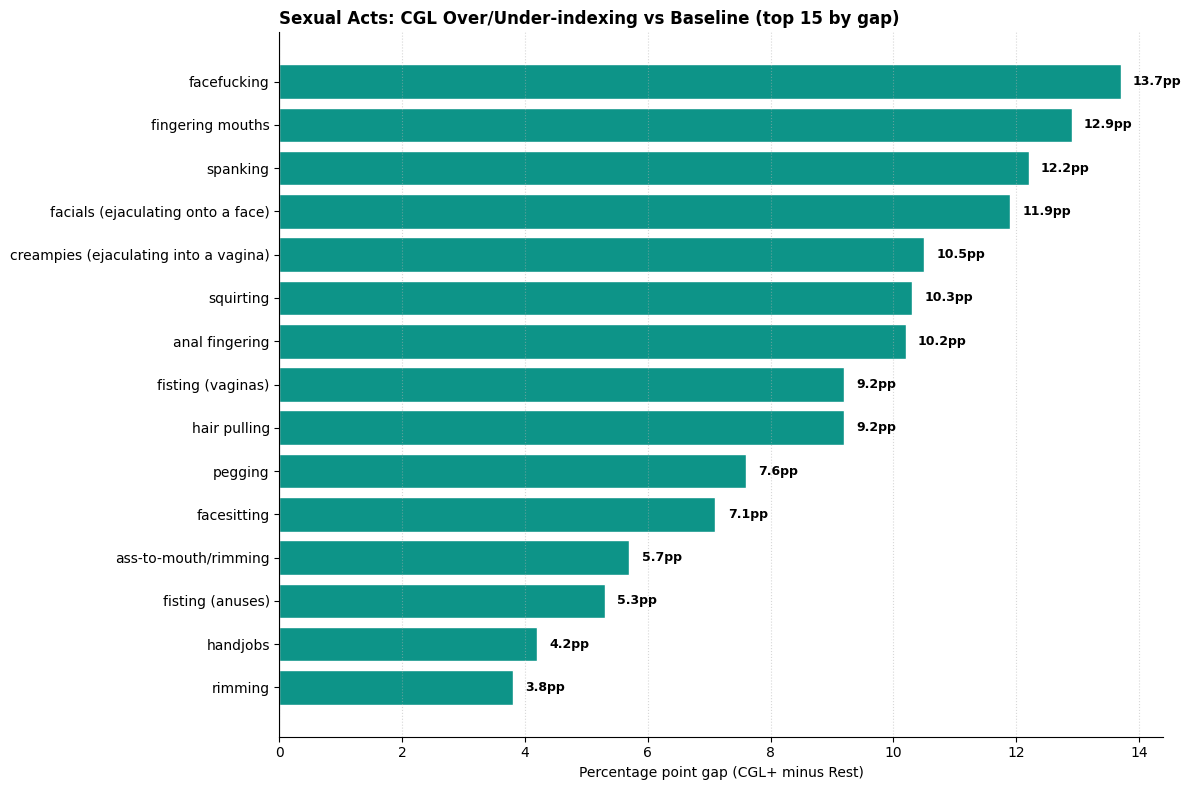

In [138]:
# Visualize top acts by gap
fig, ax = plt.subplots(figsize=(12, 8))

top_n = 15
plot_data = acts_df.sort_values('Δ (CGL+ - Rest)').tail(top_n)
colors = ['#0d9488' if x > 0 else '#f97316' for x in plot_data['Δ (CGL+ - Rest)']]

bars = ax.barh(plot_data['variable'], plot_data['Δ (CGL+ - Rest)'], color=colors, edgecolor='white', linewidth=1)
ax.axvline(0, color='#444', linestyle='-', linewidth=1.5)

# Add value labels
for i, (_, row) in enumerate(plot_data.iterrows()):
    offset = 0.2 if row['Δ (CGL+ - Rest)'] > 0 else -0.2
    ha = 'left' if row['Δ (CGL+ - Rest)'] > 0 else 'right'
    ax.text(
        row['Δ (CGL+ - Rest)'] + offset, i,
        f'{row["Δ (CGL+ - Rest)"]:.1f}pp',
        va='center', ha=ha, fontsize=9, fontweight='bold'
    )

ax.set_xlabel('Percentage point gap (CGL+ minus Rest)')
ax.set_title(f'Sexual Acts: CGL Over/Under-indexing vs Baseline (top {top_n} by gap)', fontweight='bold', fontsize=12, loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Common Preferences

In [139]:
common_df = analyze_nsfw_variable(nsfw_df, common_cols)
print(f'Common preferences by CGL gap:')
print(common_df.to_string(index=False))

Common preferences by CGL gap:
                       variable  CGL+ %  Rest %  Δ (CGL+ - Rest)  Cohen's h
                     nonconsent    61.6    30.4             31.2      0.637
                          roles    61.5    39.4             22.2      0.447
              multiple partners    57.6    36.5             21.0      0.425
        exhibitionism/voyeurism    59.2    39.8             19.4      0.390
           power dynamics & d/s    71.9    53.3             18.6      0.387
                    humiliation    37.2    19.7             17.5      0.393
                  sadomasochism    46.9    30.7             16.3      0.335
   mythical/fictional creatures    36.9    21.8             15.1      0.334
                           toys    64.0    52.0             11.9      0.242
                        bondage    65.3    54.0             11.3      0.230
                       clothing    61.1    51.5              9.6      0.193
                      eagerness    83.4    74.1          

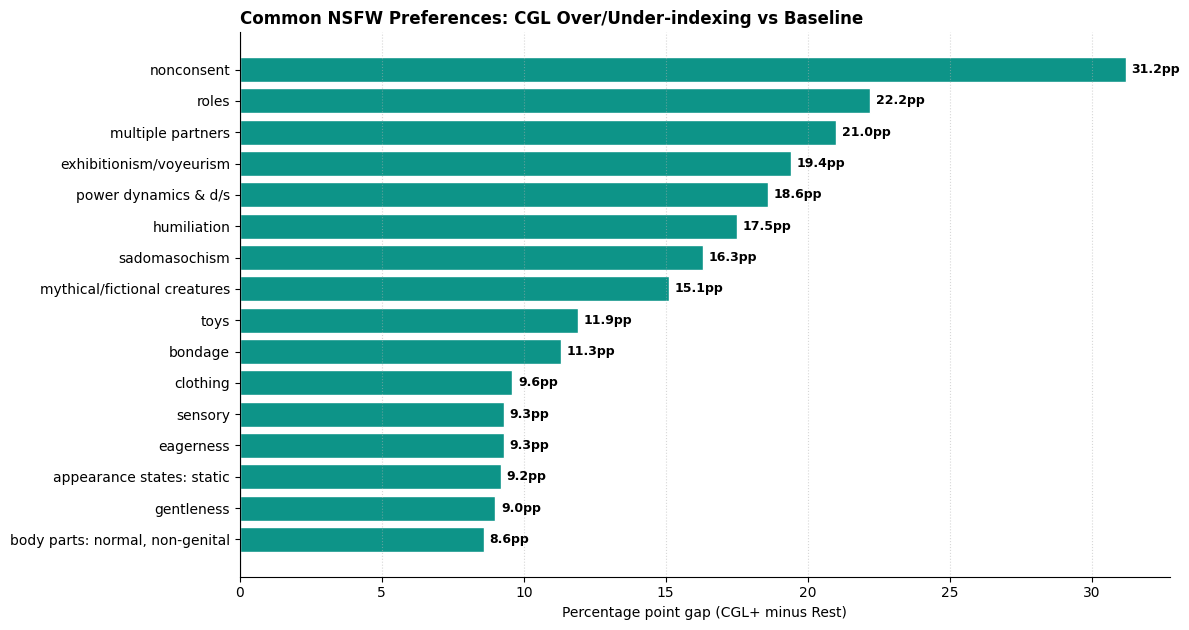

In [140]:
fig, ax = plt.subplots(figsize=(12, max(6, 0.4 * len(common_df))))

plot_data = common_df.sort_values('Δ (CGL+ - Rest)')
colors = ['#0d9488' if x > 0 else '#f97316' for x in plot_data['Δ (CGL+ - Rest)']]

bars = ax.barh(plot_data['variable'], plot_data['Δ (CGL+ - Rest)'], color=colors, edgecolor='white', linewidth=1)
ax.axvline(0, color='#444', linestyle='-', linewidth=1.5)

for i, (_, row) in enumerate(plot_data.iterrows()):
    offset = 0.2 if row['Δ (CGL+ - Rest)'] > 0 else -0.2
    ha = 'left' if row['Δ (CGL+ - Rest)'] > 0 else 'right'
    ax.text(
        row['Δ (CGL+ - Rest)'] + offset, i,
        f'{row["Δ (CGL+ - Rest)"]:.1f}pp',
        va='center', ha=ha, fontsize=9, fontweight='bold'
    )

ax.set_xlabel('Percentage point gap (CGL+ minus Rest)')
ax.set_title('Common NSFW Preferences: CGL Over/Under-indexing vs Baseline', fontweight='bold', fontsize=12, loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Uncommon/Extreme Preferences

In [141]:
uncommon_df = analyze_nsfw_variable(nsfw_df, uncommon_cols)
print(f'Uncommon preferences by CGL gap:')
print(uncommon_df.to_string(index=False))

Uncommon preferences by CGL gap:
                      variable  CGL+ %  Rest %  Δ (CGL+ - Rest)  Cohen's h
              age: nonstandard   100.0    10.9             89.1      2.433
                  reproduction    36.6    16.5             20.2      0.464
             mental alteration    34.1    16.2             17.9      0.419
             bodily secretions    33.6    17.5             16.1      0.375
          objects: nonstandard    34.0    17.9             16.1      0.371
          bestiality/creatures    21.1     7.2             13.8      0.409
abnormal bodies and body parts    25.4    12.9             12.4      0.320
                    genderplay    27.9    16.1             11.8      0.287
               transformations    19.9    10.3              9.6      0.273
                brutal/violent    11.7     4.1              7.6      0.291
                 creepy/horror    10.2     3.1              7.1      0.295
   dirtiness/disgust/messiness     7.3     2.2              5.1    

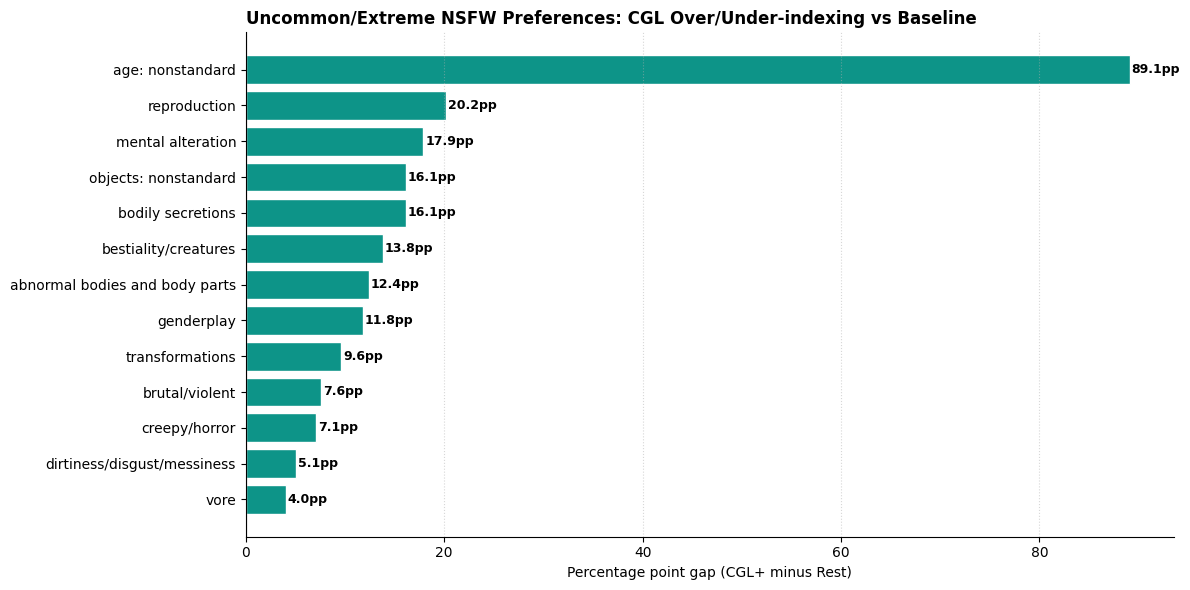

In [142]:
fig, ax = plt.subplots(figsize=(12, max(6, 0.4 * len(uncommon_df))))

plot_data = uncommon_df.sort_values('Δ (CGL+ - Rest)')
colors = ['#0d9488' if x > 0 else '#f97316' for x in plot_data['Δ (CGL+ - Rest)']]

bars = ax.barh(plot_data['variable'], plot_data['Δ (CGL+ - Rest)'], color=colors, edgecolor='white', linewidth=1)
ax.axvline(0, color='#444', linestyle='-', linewidth=1.5)

for i, (_, row) in enumerate(plot_data.iterrows()):
    offset = 0.2 if row['Δ (CGL+ - Rest)'] > 0 else -0.2
    ha = 'left' if row['Δ (CGL+ - Rest)'] > 0 else 'right'
    ax.text(
        row['Δ (CGL+ - Rest)'] + offset, i,
        f'{row["Δ (CGL+ - Rest)"]:.1f}pp',
        va='center', ha=ha, fontsize=9, fontweight='bold'
    )

ax.set_xlabel('Percentage point gap (CGL+ minus Rest)')
ax.set_title('Uncommon/Extreme NSFW Preferences: CGL Over/Under-indexing vs Baseline', fontweight='bold', fontsize=12, loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Positions

In [143]:
pos_df = analyze_nsfw_variable(nsfw_df, pos_cols)
print(f'Sexual positions by CGL gap:')
print(pos_df.to_string(index=False))

Sexual positions by CGL gap:
       variable  CGL+ %  Rest %  Δ (CGL+ - Rest)  Cohen's h
    standing up    54.9    49.7              5.2      0.104
             69    53.0    48.0              5.1      0.102
reverse cowgirl    54.5    49.6              4.9      0.098
       spooning    57.6    53.2              4.5      0.090
     doggystyle    82.4    78.1              4.2      0.107
        cowgirl    72.1    69.7              2.4      0.053
     missionary    76.2    74.4              1.8      0.042
       cow-girl     0.0     0.0             -0.0     -0.018


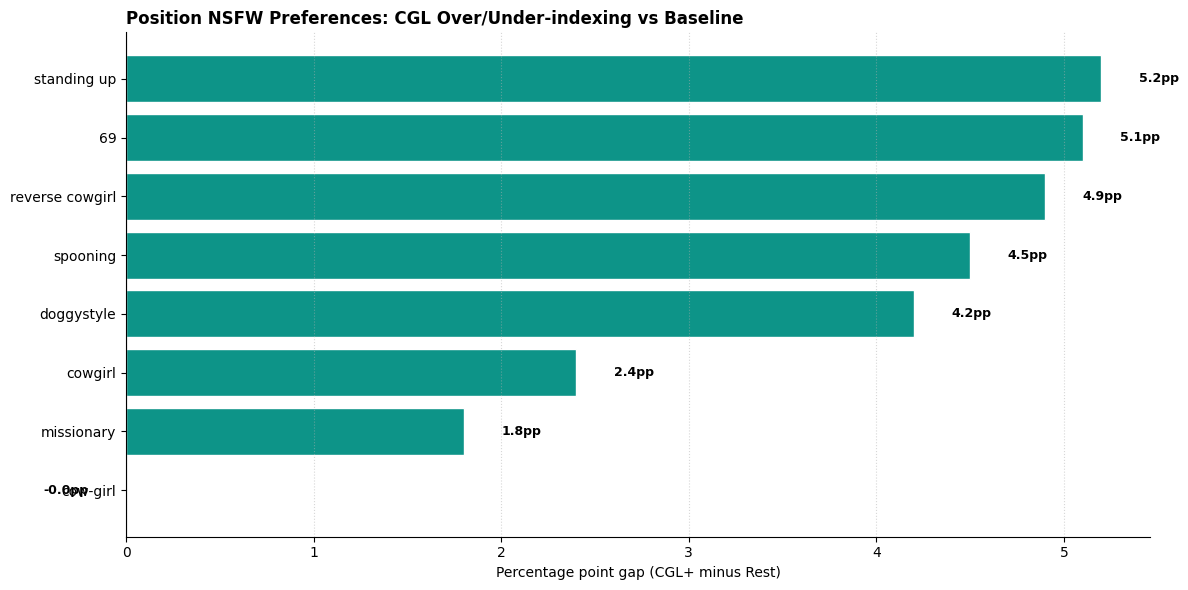

In [144]:
fig, ax = plt.subplots(figsize=(12, max(6, 0.4 * len(uncommon_df))))

plot_data = pos_df.sort_values('Δ (CGL+ - Rest)')
colors = ['#0d9488' if x > 0 else '#f97316' for x in plot_data['Δ (CGL+ - Rest)']]

bars = ax.barh(plot_data['variable'], plot_data['Δ (CGL+ - Rest)'], color=colors, edgecolor='white', linewidth=1)
ax.axvline(0, color='#444', linestyle='-', linewidth=1.5)

for i, (_, row) in enumerate(plot_data.iterrows()):
    offset = 0.2 if row['Δ (CGL+ - Rest)'] > 0 else -0.2
    ha = 'left' if row['Δ (CGL+ - Rest)'] > 0 else 'right'
    ax.text(
        row['Δ (CGL+ - Rest)'] + offset, i,
        f'{row["Δ (CGL+ - Rest)"]:.1f}pp',
        va='center', ha=ha, fontsize=9, fontweight='bold'
    )

ax.set_xlabel('Percentage point gap (CGL+ minus Rest)')
ax.set_title('Position NSFW Preferences: CGL Over/Under-indexing vs Baseline', fontweight='bold', fontsize=12, loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Endorsement rate by CGL flag (acts / common / uncommon / positions)

**Why this section was redone:** an earlier version showed CGL+ over-endorsing
almost everything. Two artefacts inflate that effect, both fixed here:

1. **NaN-as-0 trap.** The data has many non-responses per item. Treating NaN as
   "did not endorse" mixes "skipped the question" with "answered no". Rest has
   a much higher skip rate than CGL+ (≈ 47% vs 28% on the kink arousal block),
   so Rest's rates were systematically pulled down. **Fix:** drop NaN per item,
   per group — rates are now "% of users who *answered the question* and said
   yes". See the engagement check for whether this fully closes the gap.
2. **Unknown-as-a-separate-dot.** That made the visual noisier without adding
   signal. **Fix:** third dot is now the full-sample baseline (`All
   respondents`) — the rate to beat for CGL+ over-endorsement to be real
   instead of "everyone answers that way."

Three dots per item:

- 🟢 **CGL = True** — among CGL+ respondents who answered the item
- 🔴 **CGL = False** — among CGL− respondents who answered the item
- ⚫ **All respondents** — full-sample rate (everyone who answered, regardless of CGL flag)

Right column: **`True − False` pp gap** and **`True/False` lift ratio**. Items
where the green dot sits clearly to the right of the black dot are the real
CGL+ signals.


In [145]:
# === Engagement check: does any group endorse MORE on average (responders-only)? ===
def engagement_check(df, families, cgl_flag_col="cgl_flag"):
    """For each user-family pair, compute the % of items they ANSWERED that they
    ALSO ENDORSED. NaN dropped per user (denominator = items they answered).
    Then summarise by group. This is the responders-only engagement rate;
    contrast with the per-item rates in the dumbbell below."""
    flag = df[cgl_flag_col].astype(str)
    rows = []
    for fam_name, cols in families.items():
        block = df[cols]
        per_user_answered = block.notna().sum(axis=1)
        per_user_endorsed = (block == 1).sum(axis=1)
        # Responders-only rate per user; users who answered nothing in this family are dropped
        rate = per_user_endorsed.where(per_user_answered > 0) / per_user_answered.replace(0, np.nan) * 100
        for g in ("True", "False", "Unknown"):
            mask = flag == g
            vals = rate[mask].dropna()
            if vals.empty: continue
            rows.append({
                "family": fam_name, "cgl_flag": g, "n_users_with_data": int(len(vals)),
                "mean_pct_endorsed_of_answered": round(float(vals.mean()), 1),
                "median_pct_endorsed_of_answered": round(float(vals.median()), 1),
                "n_items_in_family": len(cols),
            })
        # Combined: all respondents who answered something in the family
        vals_all = rate.dropna()
        rows.append({
            "family": fam_name, "cgl_flag": "All", "n_users_with_data": int(len(vals_all)),
            "mean_pct_endorsed_of_answered": round(float(vals_all.mean()), 1),
            "median_pct_endorsed_of_answered": round(float(vals_all.median()), 1),
            "n_items_in_family": len(cols),
        })
    return pd.DataFrame(rows)


FAMILIES = {
    "acts": act_cols, "common": common_cols,
    "uncommon": uncommon_cols, "positions": pos_cols,
}
eng = engagement_check(nsfw_df, FAMILIES)

print("Engagement check — mean % of ANSWERED items that each user endorsed, by group:")
pivot = eng.pivot_table(index="family", columns="cgl_flag",
                        values="mean_pct_endorsed_of_answered")
pivot = pivot[["True", "False", "Unknown", "All"]]
print(pivot.round(1))

print("\nLift ratio (True / False):")
lift = (pivot["True"] / pivot["False"]).round(2).rename("True/False")
print(lift)

print(
    "\nReading this:"
    "\n  - Lift ≈ 1.0   per-family means CGL+ and Rest endorse similar fractions of"
    "\n                  what they answered; per-item dumbbell gaps are preference signal."
    "\n  - Lift > 1.2   CGL+ clicks more boxes generally; treat per-item gaps as"
    "\n                  'CGL+ over-endorses this AT MORE THAN the baseline rate'."
    "\n  - Compare any single-item True/False lift in the dumbbell to this baseline lift."
)


Engagement check — mean % of ANSWERED items that each user endorsed, by group:
cgl_flag   True  False  Unknown   All
family                               
acts       41.0   37.9     33.7  35.4
common     57.7   50.4     41.9  45.5
positions  56.3   54.1     52.7  53.5
uncommon   28.4   22.7      9.2  13.9

Lift ratio (True / False):
family
acts         1.08
common       1.14
positions    1.04
uncommon     1.25
Name: True/False, dtype: float64

Reading this:
  - Lift ≈ 1.0   per-family means CGL+ and Rest endorse similar fractions of
                  what they answered; per-item dumbbell gaps are preference signal.
  - Lift > 1.2   CGL+ clicks more boxes generally; treat per-item gaps as
                  'CGL+ over-endorses this AT MORE THAN the baseline rate'.
  - Compare any single-item True/False lift in the dumbbell to this baseline lift.


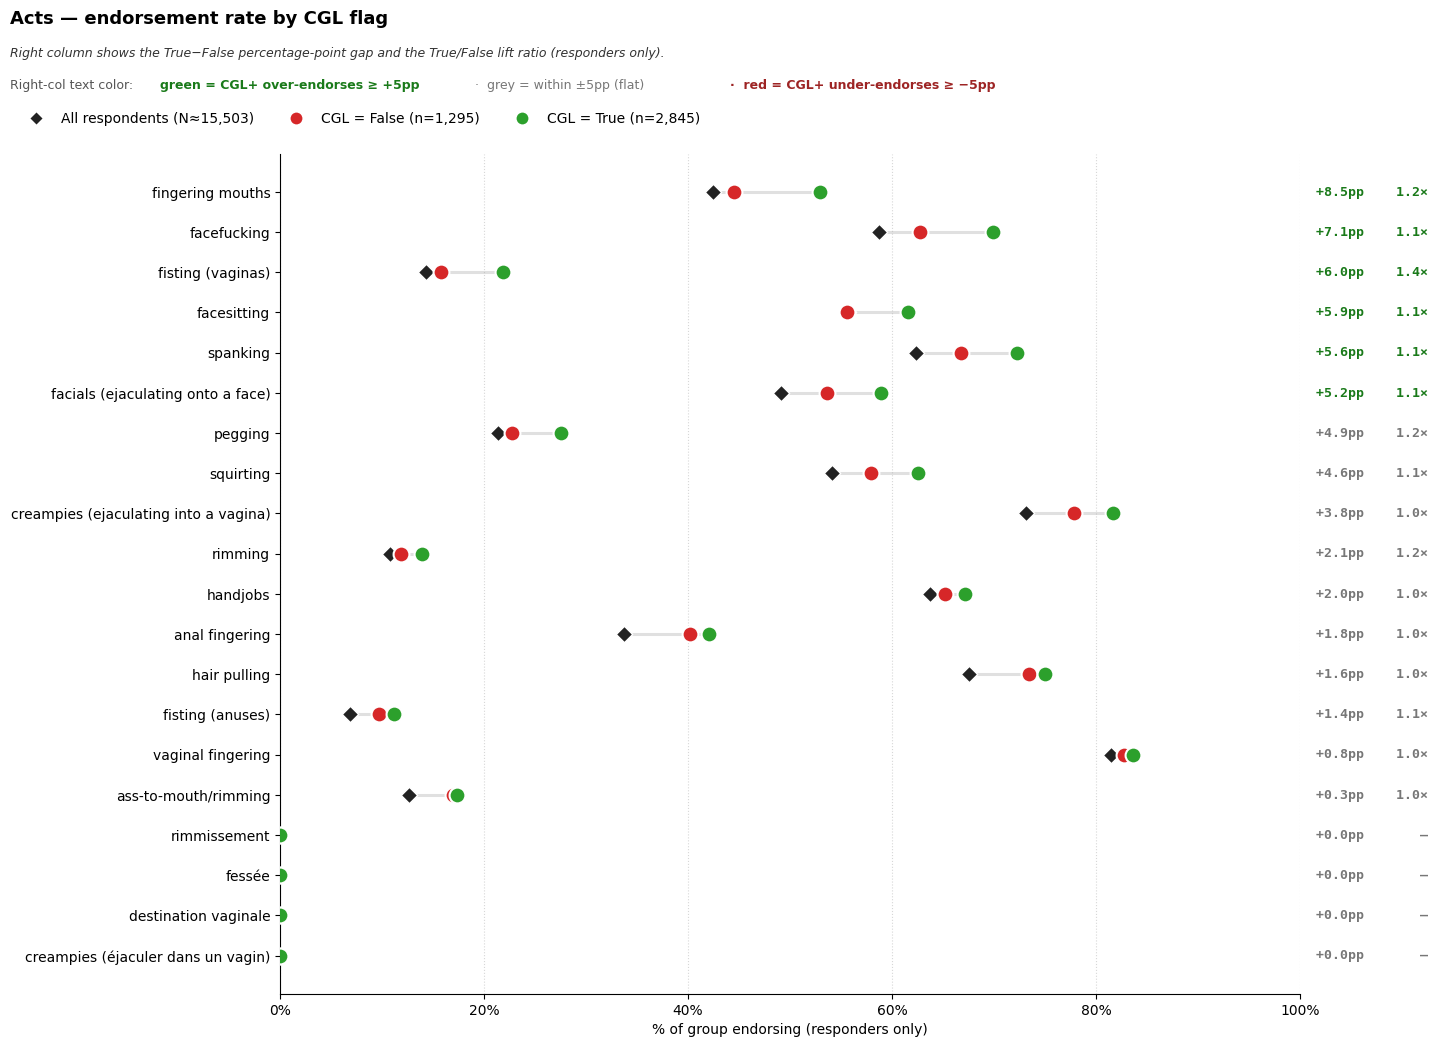

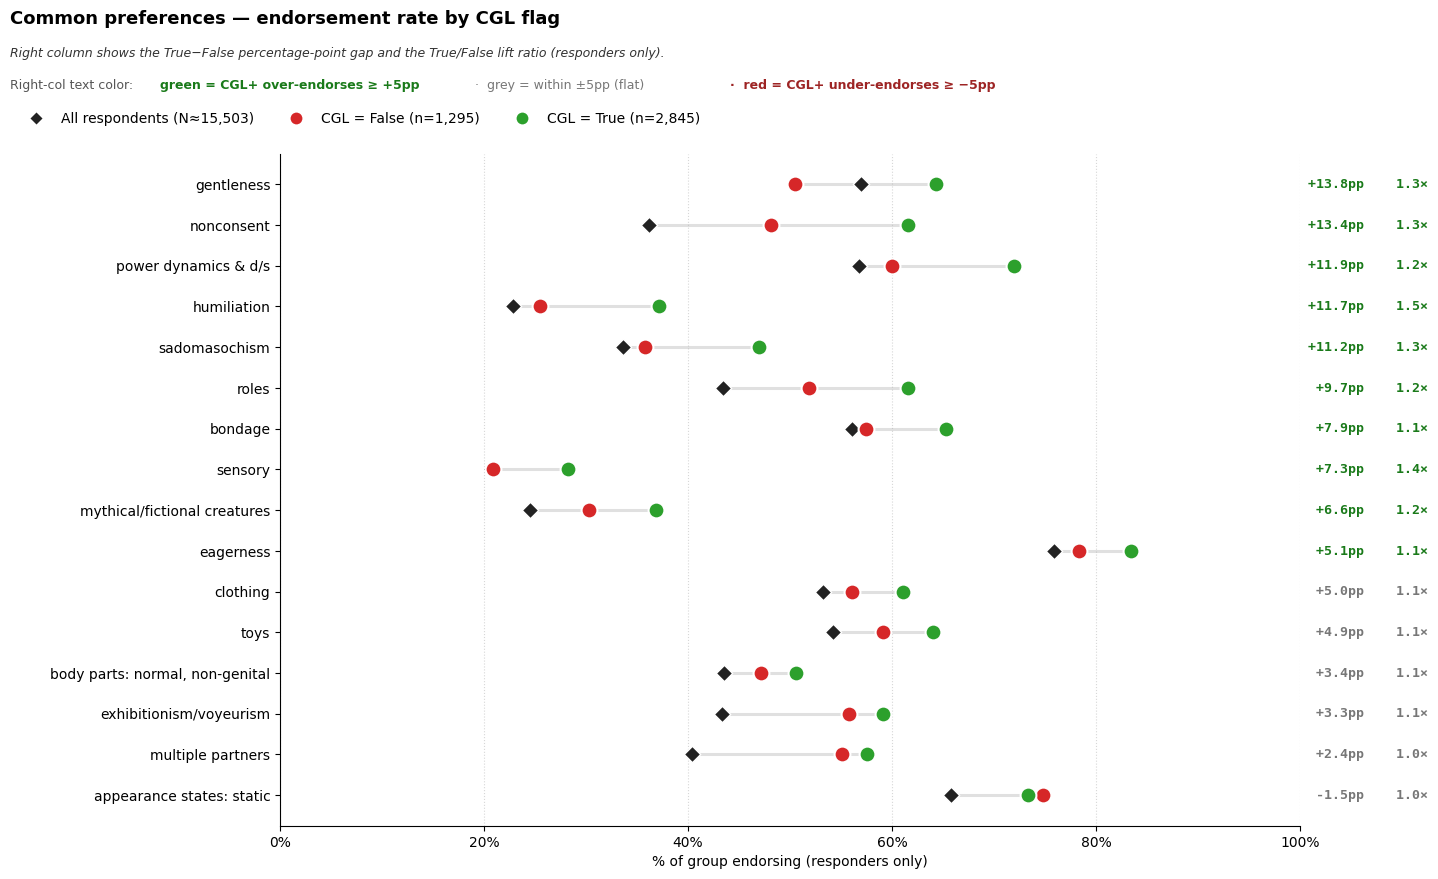

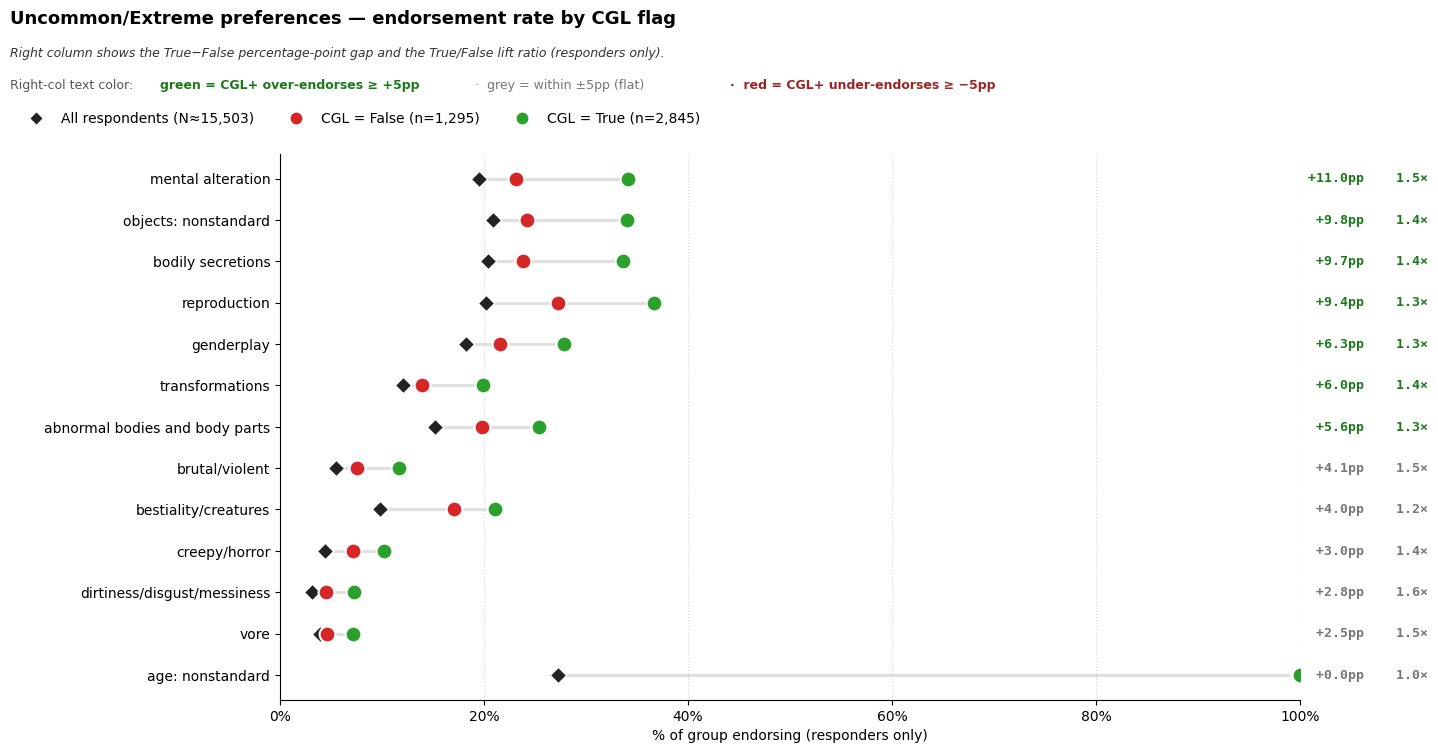

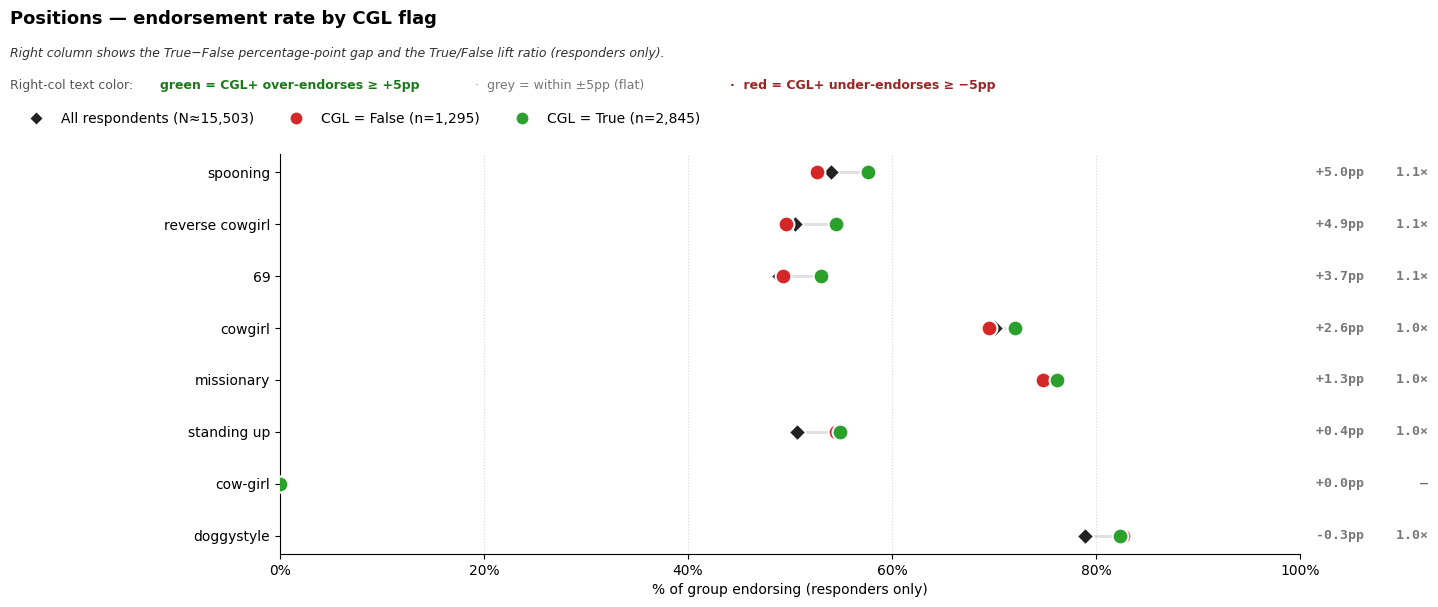

In [146]:
# === 3-way dumbbell: CGL = True / False / All respondents (responders-only) ===
from matplotlib.lines import Line2D

def plot_nsfw_dumbbell_3way(df, var_cols, cgl_flag_col="cgl_flag",
                            title=None, min_pp_for_color=5):
    """Three dots per item: CGL=True (green), CGL=False (red), All respondents (black diamond).
    Rates are responders-only: NaN dropped per item, per group.
    Sorted by signed True − False gap; right column shows pp gap and lift ratio.
    Header (title + description + color key + legend) sits in a fixed-inches band
    at the top of the figure, so the layout is consistent across families.
    """
    flag = df[cgl_flag_col].astype(str)
    masks = {
        "True":  flag == "True",
        "False": flag == "False",
        "All":   pd.Series(True, index=df.index),
    }
    n_total = {g: int(m.sum()) for g, m in masks.items()}

    rows = []
    for col in var_cols:
        x = df[col]
        rates, n_resp = {}, {}
        for g, m in masks.items():
            xg = x[m].dropna()
            n_resp[g] = len(xg)
            rates[g] = (100.0 * int((xg == 1).sum()) / len(xg)) if len(xg) else 0.0
        rows.append({
            "variable": col,
            "pct_true":  rates["True"],
            "pct_false": rates["False"],
            "pct_all":   rates["All"],
            "gap_tf":  rates["True"] - rates["False"],
            "lift_tf": (rates["True"] / rates["False"]) if rates["False"] > 0 else float("inf"),
        })
    data = pd.DataFrame(rows)
    data["display_name"] = data["variable"].str.replace(
        r"^(act|pos|common|uncommon|soft_erotic)_", "", regex=True
    )
    data = data.sort_values("gap_tf", ascending=True).reset_index(drop=True)

    # ---- Figure sizing: chart area + fixed header band ----
    n = len(data)
    chart_h_in  = max(4.0, 0.42 * n)
    header_h_in = 1.6
    bottom_pad_in = 0.5
    fig_h = chart_h_in + header_h_in + bottom_pad_in
    fig, ax = plt.subplots(figsize=(15, fig_h))

    # Reserve top band for header by anchoring axes between fixed inch positions
    plt.subplots_adjust(
        top    = 1 - header_h_in / fig_h,
        bottom = bottom_pad_in / fig_h,
        left   = 0.22, right = 0.90,
    )

    y = np.arange(n)

    # Connecting line spans the min and max of the three rates
    for i, row in data.iterrows():
        vals = [row["pct_true"], row["pct_false"], row["pct_all"]]
        ax.plot([min(vals), max(vals)], [i, i],
                color="#cccccc", lw=2.2, alpha=0.6, zorder=1)

    # Dots
    ax.scatter(data["pct_all"], y, s=70, color="#222222", marker="D",
               edgecolor="white", linewidth=1.0, zorder=2)
    ax.scatter(data["pct_false"], y, s=130, color="#d62728",
               edgecolor="white", linewidth=1.5, zorder=3)
    ax.scatter(data["pct_true"],  y, s=130, color="#2ca02c",
               edgecolor="white", linewidth=1.5, zorder=3)

    # X axis capped at 100%; annotations sit past the axis via clip_on=False
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
    ax.set_xlabel("% of group endorsing (responders only)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.5)

    for i, row in data.iterrows():
        gap = row["gap_tf"]
        if   gap >=  min_pp_for_color: c = "#1a7a1a"
        elif gap <= -min_pp_for_color: c = "#9d2424"
        else:                          c = "#777"
        lift = "—" if (not np.isfinite(row["lift_tf"]) or row["pct_false"] < 0.5) \
               else f"{row['lift_tf']:.1f}×"
        ax.annotate(
            f"{gap:+5.1f}pp   {lift:>5}",
            xy=(100, i), xycoords=("data", "data"),
            xytext=(6, 0), textcoords="offset points",
            ha="left", va="center", fontsize=9.5, fontweight="bold",
            color=c, family="monospace", clip_on=False,
        )

    ax.set_yticks(y); ax.set_yticklabels(data["display_name"])

    # ---- Header band: every row at fixed inches from the figure top ----
    def y_at(inches_from_top):
        return 1.0 - inches_from_top / fig_h

    LEFT = 0.04   # left edge of header text in figure coords
    Y_TITLE    = y_at(0.25)
    Y_SUBTITLE = y_at(0.60)
    Y_COLORKEY = y_at(0.92)
    Y_LEGEND   = y_at(1.25)

    fig.text(LEFT, Y_TITLE,
             title or "Endorsement rate by CGL flag",
             fontsize=13, fontweight="bold", ha="left", va="center")

    fig.text(LEFT, Y_SUBTITLE,
             "Right column shows the True−False percentage-point gap and the True/False lift ratio (responders only).",
             fontsize=9, style="italic", color="#333", ha="left", va="center")

    fig.text(LEFT,        Y_COLORKEY, "Right-col text color:",
             fontsize=9, color="#555", ha="left", va="center")
    fig.text(LEFT + 0.10, Y_COLORKEY, "green = CGL+ over-endorses ≥ +5pp",
             fontsize=9, color="#1a7a1a", fontweight="bold", ha="left", va="center")
    fig.text(LEFT + 0.31, Y_COLORKEY, "·  grey = within ±5pp (flat)",
             fontsize=9, color="#777", ha="left", va="center")
    fig.text(LEFT + 0.48, Y_COLORKEY, "·  red = CGL+ under-endorses ≥ −5pp",
             fontsize=9, color="#9d2424", fontweight="bold", ha="left", va="center")

    legend_handles = [
        Line2D([0], [0], marker="D", color="#222222", lw=0, ms=7, mec="white", mew=1.0,
               label=f"All respondents (N≈{n_total['All']:,})"),
        Line2D([0], [0], marker="o", color="#d62728", lw=0, ms=10, mec="white", mew=1.5,
               label=f"CGL = False (n={n_total['False']:,})"),
        Line2D([0], [0], marker="o", color="#2ca02c", lw=0, ms=10, mec="white", mew=1.5,
               label=f"CGL = True (n={n_total['True']:,})"),
    ]
    fig.legend(handles=legend_handles, loc="center left",
               bbox_to_anchor=(LEFT, Y_LEGEND),
               ncol=3, frameon=False, fontsize=10)

    return fig


plot_nsfw_dumbbell_3way(nsfw_df, act_cols,      title="Acts — endorsement rate by CGL flag")
plt.show()
plot_nsfw_dumbbell_3way(nsfw_df, common_cols,   title="Common preferences — endorsement rate by CGL flag")
plt.show()
plot_nsfw_dumbbell_3way(nsfw_df, uncommon_cols, title="Uncommon/Extreme preferences — endorsement rate by CGL flag")
plt.show()
plot_nsfw_dumbbell_3way(nsfw_df, pos_cols,      title="Positions — endorsement rate by CGL flag")
plt.show()


## Arousal Scale

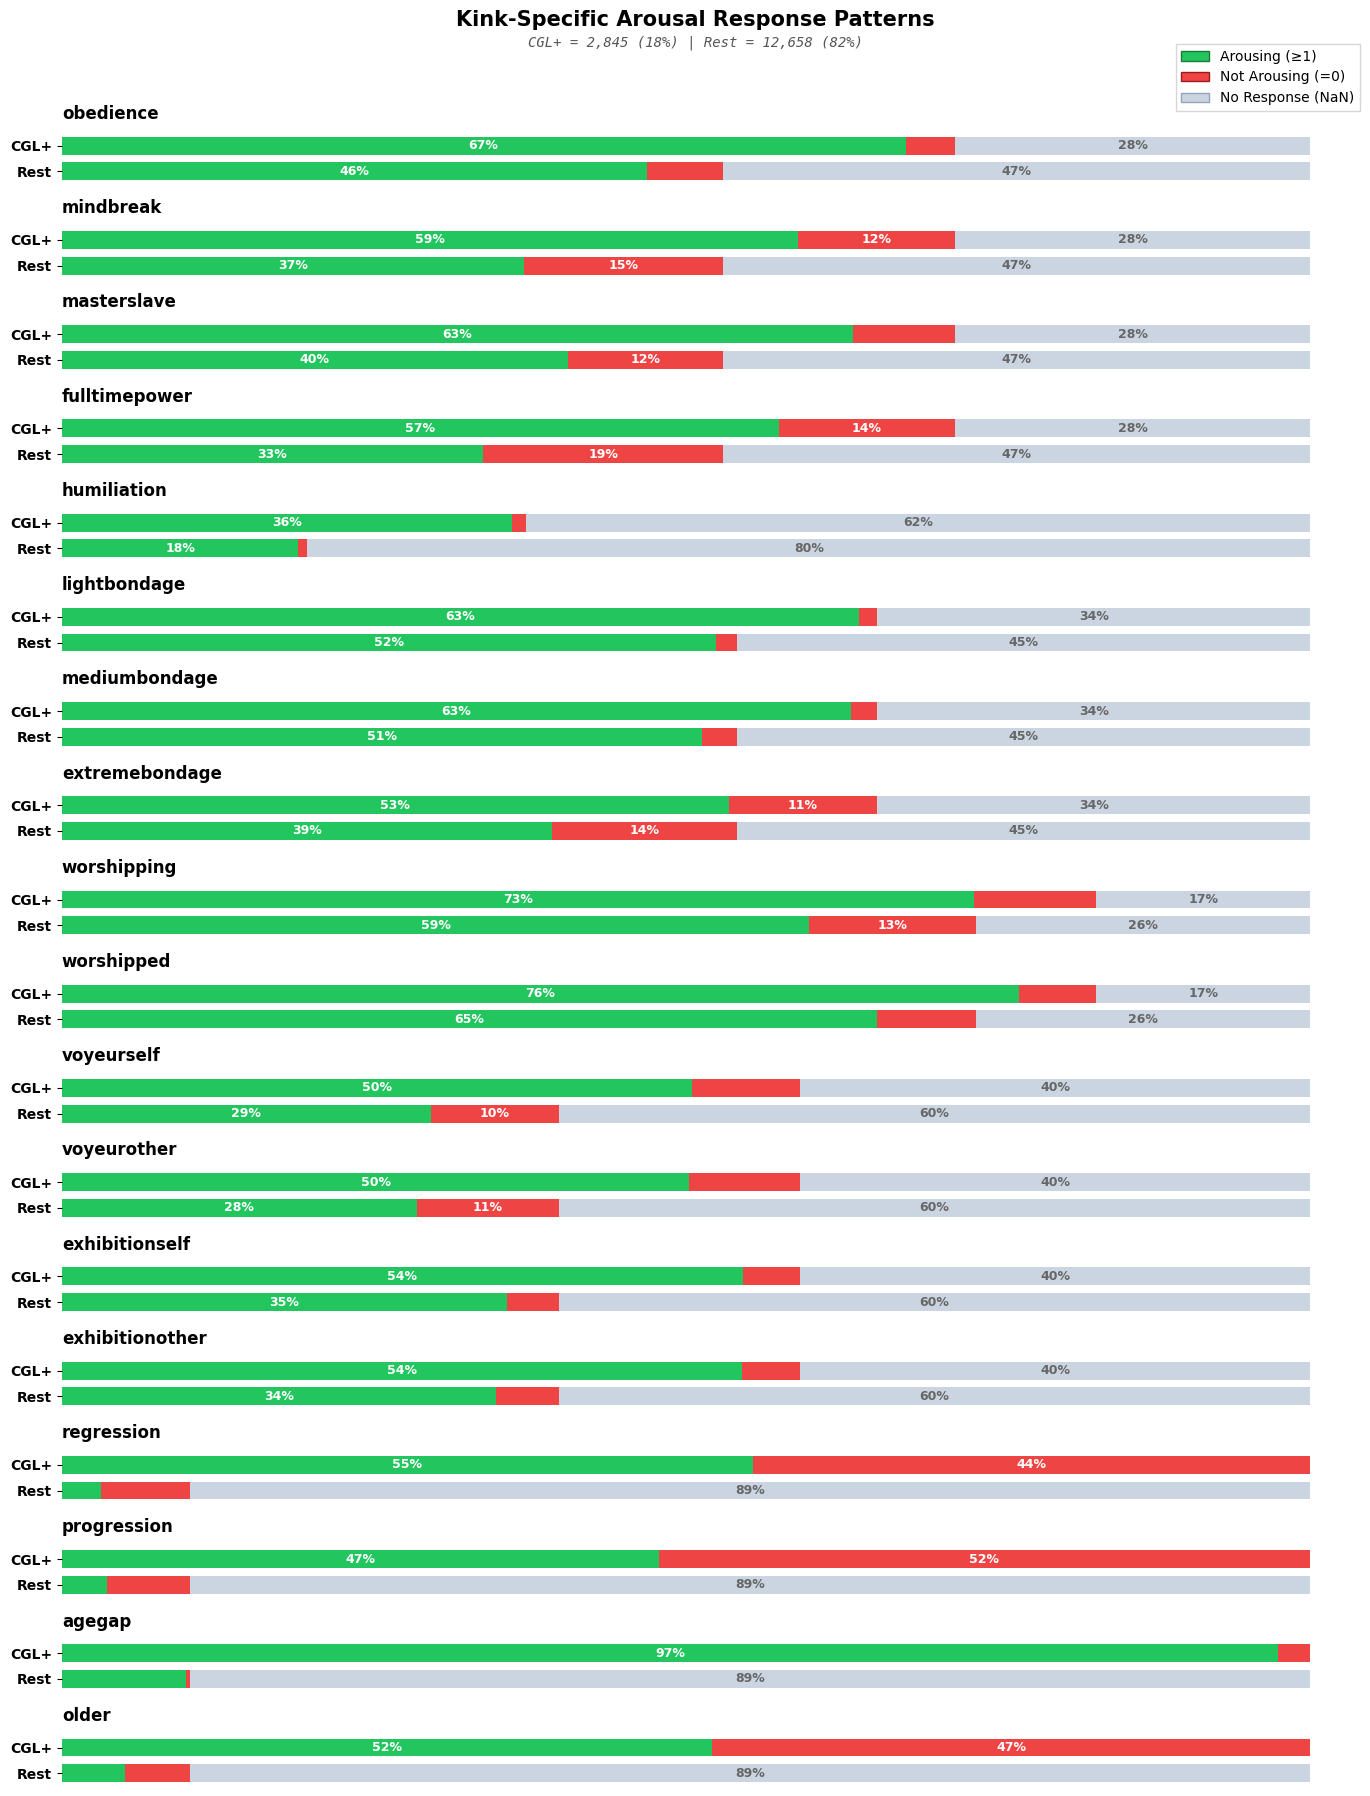

In [147]:
# Arousal Scale
# ============================================================================

kink_arousal_fields = [
    "obedience",
    "mindbreak",
    "masterslave",
    "fulltimepower",
    "humiliation",
    "lightbondage",
    "mediumbondage",
    "extremebondage",
    "worshipping",
    "worshipped",
    "voyeurself",
    "voyeurother",
    "exhibitionself",
    "exhibitionother",
    "regression",
    "progression",
    "agegap",
    "older",
]

plot_arousal_categories_bar_horizontal(nsfw_df, kink_arousal_fields)
plt.show()

/tmp/ipykernel_1244724/4009151909.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_1244724/4009151909.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_1244724/4009151909.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_1244724/4009151909.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_1244724/4009151909.py:31: MatplotlibDeprecationWarning: The 'labels' 

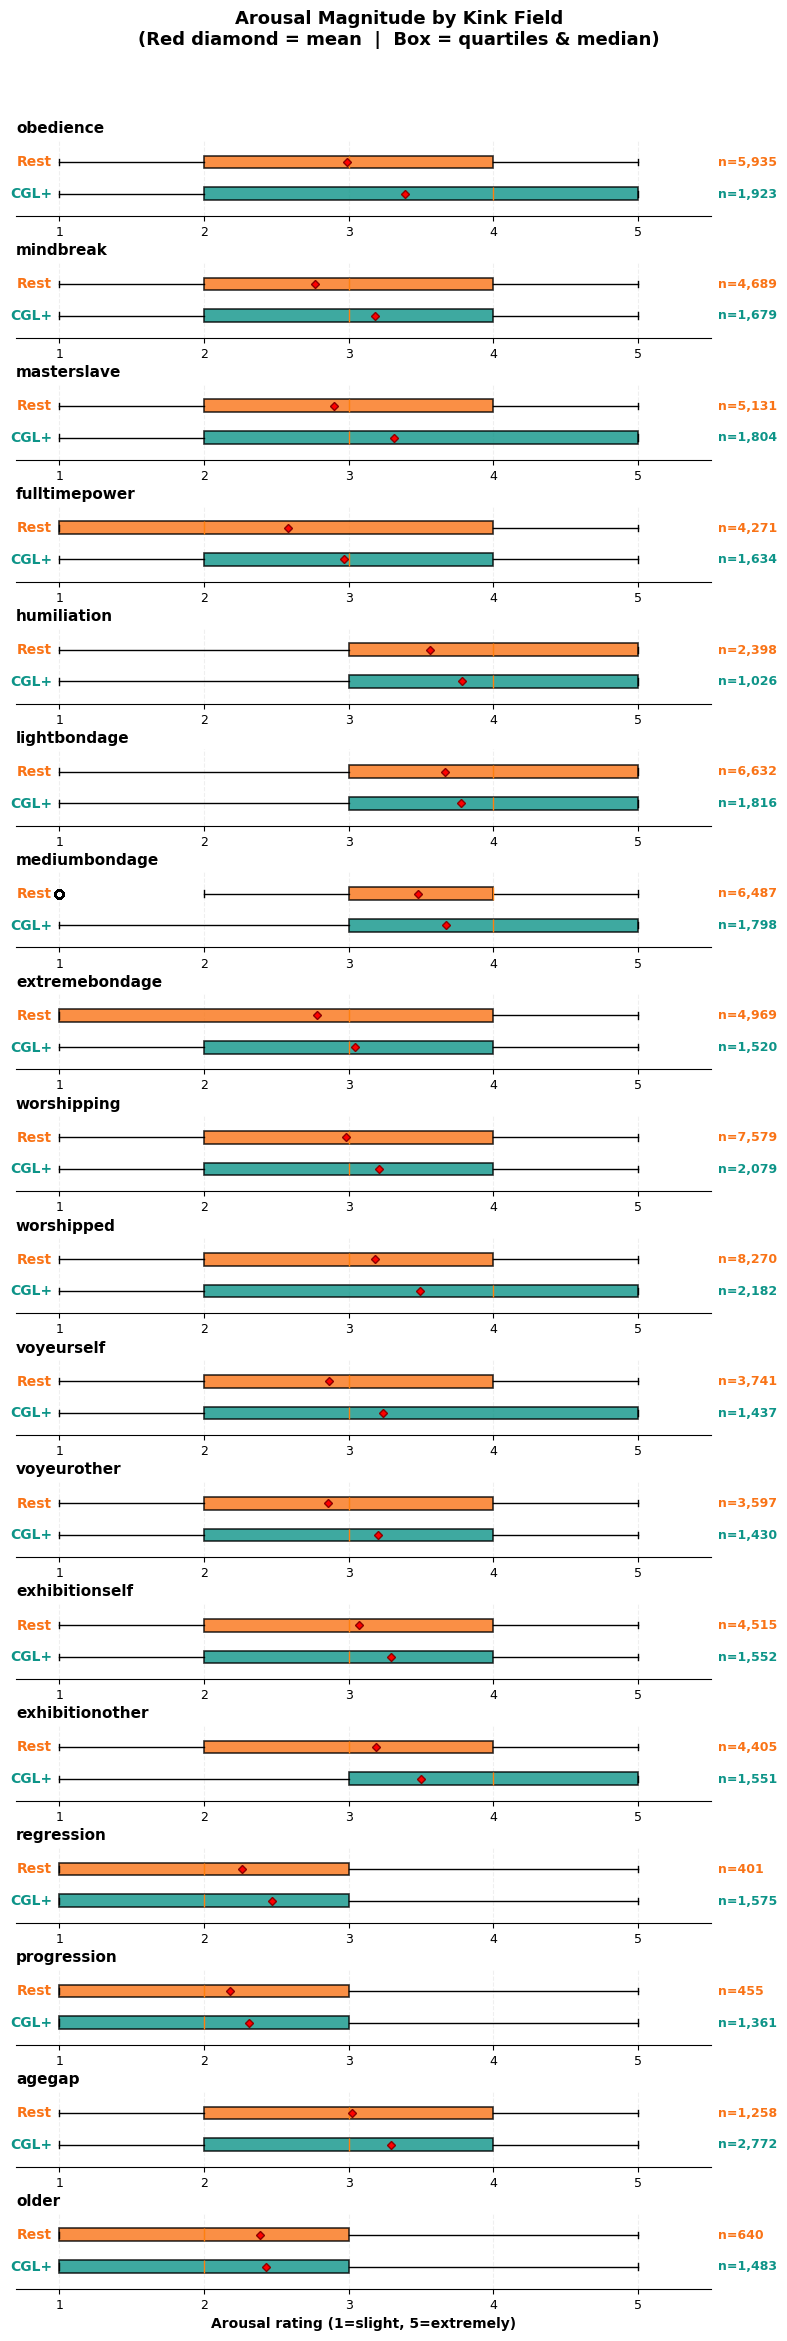

In [148]:
# Usage:
plot_kink_arousal_boxplots_clean(nsfw_df, kink_arousal_fields)
plt.show()

In [149]:

kink_arousal_df = analyze_arousal_response(
    nsfw_df, kink_arousal_fields, arousal_threshold=3
)
print(f"Kink-specific arousal fields by CGL gap:")
print(kink_arousal_df.to_string(index=False))

Kink-specific arousal fields by CGL gap:
       variable  CGL+ arousing %  CGL+ not arousing %  CGL+ unknown %  Rest arousing %  Rest not arousing %  Rest unknown %  Δ (arousing %)
  fulltimepower             34.4                 37.2            28.4             16.3                 36.7            47.0            17.3
      mindbreak             39.4                 32.2            28.4             20.1                 32.9            47.0            17.2
    masterslave             44.0                 27.5            28.4             23.8                 29.2            47.0            16.6
    voyeurother             33.4                 25.8            40.8             16.2                 23.6            60.2            15.7
     voyeurself             34.1                 25.0            40.8             16.9                 22.9            60.2            15.3
     regression             24.4                 75.6             0.0              1.1                  9.1            

## Binary Endorsement Test (0 vs 1–5, NA dropped per variable)

Reframes the question as: **does CGL+ vs Rest differ on whether the kink is arousing at all?**
For each variable, NA is dropped, then a 2×2 table (group × {not arousing=0, arousing=1–5}) is
tested with **chi-square** (Fisher's exact when any cell is sparse). Effect size = **Cohen's h**
and **odds ratio with 95% CI**. p-values are **BH-FDR adjusted** across the 18 fields.

**Signal tiers:** |h| ≥ 0.20 + FDR p < 0.05 = **strong**; |h| ≥ 0.10 + FDR p < 0.05 = **directional**; else **noise**.


In [150]:
# === Master function: binary endorsement test (0 vs 1-5, NA dropped) ===
from scipy.stats import chi2_contingency, fisher_exact


def _bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg adjusted p-values (q-values), returned in original order.
    `alpha` is accepted for API symmetry but unused — BH q-values are
    threshold-agnostic; compare to your chosen alpha downstream."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranks = np.arange(1, n + 1)
    q_sorted = pvals[order] * n / ranks
    # Enforce monotonicity (walk from largest p down, take running min)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)
    out = np.empty(n, dtype=float)
    out[order] = q_sorted
    return out


def _or_with_ci(a, b, c, d, z=1.96):
    """Odds ratio for 2x2 [[a,b],[c,d]] with Wald CI on log scale.
    Haldane (+0.5) correction applied when any cell is 0."""
    a_, b_, c_, d_ = (a, b, c, d) if min(a, b, c, d) > 0 else (a + 0.5, b + 0.5, c + 0.5, d + 0.5)
    or_ = (a_ * d_) / (b_ * c_)
    se = np.sqrt(1 / a_ + 1 / b_ + 1 / c_ + 1 / d_)
    log_or = np.log(or_)
    return or_, float(np.exp(log_or - z * se)), float(np.exp(log_or + z * se))


def analyze_arousal_binary(
    df, var_cols, group_col="cgl_flag", group_pos="True",
    alpha=0.05, min_expected_for_chi2=5,
):
    """Binary-endorsement test for each variable: CGL+ vs Rest, NaN dropped per item.

    NaN handling: NaN means "did not answer", which is NOT the same as 0
    ("answered: not arousing"). NaN is dropped per item; endorsement % is
    therefore conditional on having responded. Use `missingness_audit` to
    document the response-rate gap separately.

    Output columns:
      n_pos, n_rest                       sample size after dropping NaN
      n_endorse_pos, n_endorse_rest       count with score >= 1
      pct_endorse_pos / pct_endorse_rest  endorsement %
      endorse_gap_pp                      percentage-point gap (pos minus rest)
      cohens_h                            effect size (base-rate normalized)
      odds_ratio, or_ci_lo, or_ci_hi      OR with 95% CI
      test                                "chi2" or "fisher"
      test_stat, p_raw, p_fdr             chi-square stat, raw p, BH-FDR p
      signal                              strong / directional / noise
    """
    rows = []
    for col in var_cols:
        pos = df.loc[df[group_col].astype(str) == str(group_pos), col].dropna()
        rest = df.loc[df[group_col].astype(str) != str(group_pos), col].dropna()

        a = int((pos >= 1).sum())   # CGL+ arousing
        b = int((pos == 0).sum())   # CGL+ not arousing
        c = int((rest >= 1).sum())  # Rest arousing
        d = int((rest == 0).sum())  # Rest not arousing
        n_pos = a + b
        n_rest = c + d
        p_pos = a / n_pos if n_pos else np.nan
        p_rest = c / n_rest if n_rest else np.nan

        table = [[a, b], [c, d]]
        if n_pos == 0 or n_rest == 0 or a + c == 0 or b + d == 0:
            test_used, chi2_stat, p_test = "skipped", np.nan, np.nan
        else:
            # Expected counts to decide chi-square vs fisher
            row_tot = np.array([a + b, c + d])
            col_tot = np.array([a + c, b + d])
            n = row_tot.sum()
            expected = np.outer(row_tot, col_tot) / n
            if expected.min() < min_expected_for_chi2:
                _, p_test = fisher_exact(table)
                test_used, chi2_stat = "fisher", np.nan
            else:
                chi2_stat, p_test, _, _ = chi2_contingency(table, correction=True)
                test_used = "chi2"

        or_, or_lo, or_hi = _or_with_ci(a, b, c, d)
        h = cohens_h(p_pos, p_rest)

        rows.append({
            "variable": col,
            "n_pos": n_pos, "n_rest": n_rest,
            "n_endorse_pos": a, "n_endorse_rest": c,
            "pct_endorse_pos": round(100 * p_pos, 2),
            "pct_endorse_rest": round(100 * p_rest, 2),
            "endorse_gap_pp": round(100 * (p_pos - p_rest), 2),
            "cohens_h": round(h, 3),
            "odds_ratio": round(or_, 3),
            "or_ci_lo": round(or_lo, 3), "or_ci_hi": round(or_hi, 3),
            "test": test_used,
            "test_stat": round(chi2_stat, 3) if not np.isnan(chi2_stat) else np.nan,
            "p_raw": p_test,
        })

    out = pd.DataFrame(rows)
    valid = out["p_raw"].notna()
    out["p_fdr"] = np.nan
    out.loc[valid, "p_fdr"] = _bh_fdr(out.loc[valid, "p_raw"].values, alpha=alpha)

    abs_h = out["cohens_h"].abs()
    out["signal"] = np.where(
        (abs_h >= 0.20) & (out["p_fdr"] < alpha), "strong",
        np.where((abs_h >= 0.10) & (out["p_fdr"] < alpha), "directional", "noise"),
    )
    return out.sort_values("cohens_h", ascending=False).reset_index(drop=True)


def filter_binary_results(
    results, min_abs_h=None, max_p=None, direction=None, signal=None,
    sort_by="cohens_h", abs_sort=True, top_n=None,
):
    """Slice the binary-endorsement results.

    direction: "pos_stronger" (CGL+ over-endorses), "pos_weaker", or None.
    signal:    "strong" / "directional" / "noise" / list / None.
    """
    out = results.copy()
    if min_abs_h is not None:
        out = out[out["cohens_h"].abs() >= min_abs_h]
    if max_p is not None:
        out = out[out["p_fdr"] <= max_p]
    if direction == "pos_stronger":
        out = out[out["cohens_h"] > 0]
    elif direction == "pos_weaker":
        out = out[out["cohens_h"] < 0]
    if signal is not None:
        sig = [signal] if isinstance(signal, str) else list(signal)
        out = out[out["signal"].isin(sig)]
    key = out[sort_by].abs() if abs_sort else out[sort_by]
    out = (
        out.assign(_k=key).sort_values("_k", ascending=False)
        .drop(columns="_k").reset_index(drop=True)
    )
    if top_n:
        out = out.head(top_n)
    return out


In [151]:
# === Visualization: grouped bar of endorsement %, sorted by Cohen's h ===
def plot_endorsement_grouped_bar(results, group_pos_label="CGL+", rest_label="Rest", figsize=None):
    """Two bars per kink (CGL+ vs Rest endorsement %), sorted by Cohen's h.
    Significance stars + Cohen's h printed beside each row.
    Headline subtitle names the strongest signal.
    """
    df_plot = results.sort_values("cohens_h", ascending=True).reset_index(drop=True)
    n = len(df_plot)
    if figsize is None:
        figsize = (13, max(5, 0.5 * n))
    fig, ax = plt.subplots(figsize=figsize)

    y = np.arange(n)
    bar_h = 0.38
    ax.barh(y - bar_h / 2, df_plot["pct_endorse_pos"], height=bar_h,
            color="#0d9488", label=group_pos_label, edgecolor="white")
    ax.barh(y + bar_h / 2, df_plot["pct_endorse_rest"], height=bar_h,
            color="#f97316", label=rest_label, edgecolor="white")

    # In-bar % labels
    for i, row in df_plot.iterrows():
        ax.text(row["pct_endorse_pos"] + 0.5, i - bar_h / 2,
                f"{row['pct_endorse_pos']:.1f}%", va="center", fontsize=8, color="#0d9488", fontweight="bold")
        ax.text(row["pct_endorse_rest"] + 0.5, i + bar_h / 2,
                f"{row['pct_endorse_rest']:.1f}%", va="center", fontsize=8, color="#f97316", fontweight="bold")

    # Right annotation: gap, h, OR, stars
    xmax = float(df_plot[["pct_endorse_pos", "pct_endorse_rest"]].values.max())
    for i, row in df_plot.iterrows():
        p = row["p_fdr"]
        stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        h = row["cohens_h"]
        color = "#0d9488" if h > 0 else "#f97316" if h < 0 else "#888"
        ax.text(
            xmax + 8, i,
            f"Δ={row['endorse_gap_pp']:+.1f}pp  h={h:+.2f}  OR={row['odds_ratio']:.2f}  {stars}",
            va="center", fontsize=9, color=color, fontweight="bold", family="monospace",
        )

    ax.set_yticks(y)
    ax.set_yticklabels(df_plot["variable"], fontweight="bold")
    ax.set_xlim(0, xmax * 1.05)
    ax.set_xlabel("% endorsing as arousing (score ≥ 1)")
    ax.legend(loc="lower right", frameon=False, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.25)

    top = results.iloc[results["cohens_h"].abs().argmax()]
    direction_word = "MORE likely to find arousing" if top["cohens_h"] > 0 else "LESS likely to find arousing"
    headline = (
        f"Headline: {group_pos_label} is {direction_word} \"{top['variable']}\" "
        f"({top['pct_endorse_pos']:.0f}% vs {top['pct_endorse_rest']:.0f}%, "
        f"OR={top['odds_ratio']:.2f}, h={top['cohens_h']:+.2f}, FDR p={top['p_fdr']:.1e})"
    )
    ax.set_title(
        f"Binary endorsement (0 vs 1–5) by group · NA dropped · sorted by Cohen's h\n{headline}",
        fontweight="bold", fontsize=12, loc="left",
    )
    plt.tight_layout()
    return fig


### Run & Review (binary)

In [152]:
# === Run binary analysis ===
binary_df = analyze_arousal_binary(nsfw_df, kink_arousal_fields)

print(f"Fields analyzed: {len(binary_df)}  |  signal tiers: {binary_df['signal'].value_counts().to_dict()}")
print(f"Tests used: {binary_df['test'].value_counts().to_dict()}")
print(f"NA dropped per variable: n_pos range {binary_df['n_pos'].min()}-{binary_df['n_pos'].max()}, "
      f"n_rest range {binary_df['n_rest'].min()}-{binary_df['n_rest'].max()}")

display_cols = [
    "variable", "n_pos", "n_rest",
    "pct_endorse_pos", "pct_endorse_rest", "endorse_gap_pp",
    "cohens_h", "odds_ratio", "or_ci_lo", "or_ci_hi",
    "test", "p_raw", "p_fdr", "signal",
]
(
    binary_df.assign(_a=binary_df["cohens_h"].abs())
    .sort_values("_a", ascending=False)
    .drop(columns="_a")[display_cols]
)


Fields analyzed: 18  |  signal tiers: {'strong': 9, 'noise': 6, 'directional': 3}
Tests used: {'chi2': 18}
NA dropped per variable: n_pos range 1058-2845, n_rest range 1295-9275


,variable,n_pos,n_rest,pct_endorse_pos,pct_endorse_rest,endorse_gap_pp,cohens_h,odds_ratio,or_ci_lo,or_ci_hi,test,p_raw,p_fdr,signal
0,regression,2845,1295,55.36,30.97,24.40,0.498,2.765,2.406,3.177,chi2,7.133953e-48,1.284112e-46,strong
1,fulltimepower,2036,6707,80.26,63.68,16.58,0.373,2.318,2.056,2.614,chi2,2.598315e-44,2.338483e-43,strong
2,voyeurother,1683,5040,84.97,71.37,13.60,0.333,2.267,1.958,2.626,chi2,1.420526e-28,5.113894e-28,strong
3,masterslave,2036,6707,88.61,76.50,12.10,0.323,2.388,2.060,2.769,chi2,5.019242e-32,3.011545e-31,strong
4,mindbreak,2036,6707,82.47,69.91,12.55,0.297,2.024,1.785,2.295,chi2,9.456536e-29,4.255441e-28,strong
5,voyeurself,1683,5040,85.38,74.23,11.16,0.280,2.028,1.747,2.355,chi2,6.210214e-21,1.863064e-20,strong
6,progression,2845,1295,47.84,35.14,12.70,0.259,1.693,1.478,1.939,chi2,2.892459e-14,5.784918e-14,strong
7,extremebondage,1859,6842,81.76,72.62,9.14,0.219,1.690,1.485,1.923,chi2,1.294493e-15,3.328696e-15,strong
8,obedience,2036,6707,94.45,88.49,5.96,0.217,2.214,1.805,2.715,chi2,8.003939e-15,1.800886e-14,strong
9,worshipping,2358,9275,88.17,81.71,6.45,0.181,1.667,1.456,1.910,chi2,1.147879e-13,2.066182e-13,directional


In [153]:
def _resolve_name(row, name_col):
    # explicit column wins
    if name_col and name_col in row.index:
        return str(row[name_col])
    # try common column names
    for c in ("item", "feature", "variable", "name", "kink", "label", "question"):
        if c in row.index:
            return str(row[c])
    # fall back to the Series' index label (set by iterrows / .loc)
    return str(row.name) if row.name is not None else "<unnamed>"


def _pct_scale(*vals):
    # if anything exceeds 1.5, assume values are already 0-100
    return 1.0 if max(abs(v) for v in vals) > 1.5 else 100.0


def summarize_row(row, name_col=None):
    name = _resolve_name(row, name_col)
    pos, rest = row["pct_endorse_pos"], row["pct_endorse_rest"]
    gap, h    = row["endorse_gap_pp"], row["cohens_h"]
    orr       = row["odds_ratio"]
    lo, hi    = row["or_ci_lo"], row["or_ci_hi"]
    test      = row["test"]
    p_raw, p_fdr = row["p_raw"], row["p_fdr"]

    k = _pct_scale(pos, rest)  # 100 if already-0-1, else 1

    sig_fdr  = p_fdr < 0.05
    sig_raw  = p_raw < 0.05
    ci_clean = (lo > 1) or (hi < 1)
    mag      = abs(h)

    if   sig_fdr and ci_clean and mag >= 0.5: tier = "STRONG SIGNAL"
    elif sig_fdr and ci_clean and mag >= 0.2: tier = "MODERATE SIGNAL"
    elif sig_fdr and ci_clean:                tier = "WEAK SIGNAL (sig but tiny effect)"
    elif sig_raw and not sig_fdr:             tier = "MARGINAL (lost to FDR — likely noise)"
    else:                                     tier = "NOT SIGNIFICANT"

    arrow = "↑" if gap > 0 else ("↓" if gap < 0 else "·")
    direction = "higher in target" if gap > 0 else "lower in target"
    eff_word = ("negligible" if mag < 0.2 else
                "small"      if mag < 0.5 else
                "medium"     if mag < 0.8 else "large")
    or_phrase = (f"target has {orr:.2f}× the odds of endorsing"
                 if orr >= 1 else
                 f"target has {1/orr:.2f}× LOWER odds (OR={orr:.2f})")

    print(f"[{tier} {arrow}] {name}")
    print(f"  Rates    : target {pos*k:.1f}%  vs  rest {rest*k:.1f}%   "
          f"(gap = {gap:+.1f}pp, {direction})")
    print(f"  Effect   : Cohen's h = {h:+.2f}  ({eff_word})")
    print(f"  Odds     : {or_phrase}   95% CI [{lo:.2f}, {hi:.2f}]"
          + ("  ✓ excludes 1" if ci_clean else "  ✗ crosses 1"))
    print(f"  Test     : {test}   p_raw = {p_raw:.2e}   p_fdr = {p_fdr:.2e}")
    print()


def summarize_top(df, n=10, sort_by="cohens_h", name_col=None, only_sig=True):
    d = df.copy()
    if only_sig:
        d = d[d["p_fdr"] < 0.05]
    d = d.reindex(d[sort_by].abs().sort_values(ascending=False).index).head(n)
    for _, row in d.iterrows():   # row.name carries the index label
        summarize_row(row, name_col=name_col)


# usage:
summarize_row(binary_df.iloc[0])
summarize_top(binary_df, n=15)


[MODERATE SIGNAL ↑] regression
  Rates    : target 55.4%  vs  rest 31.0%   (gap = +24.4pp, higher in target)
  Effect   : Cohen's h = +0.50  (small)
  Odds     : target has 2.77× the odds of endorsing   95% CI [2.41, 3.18]  ✓ excludes 1
  Test     : chi2   p_raw = 7.13e-48   p_fdr = 1.28e-46

[MODERATE SIGNAL ↑] regression
  Rates    : target 55.4%  vs  rest 31.0%   (gap = +24.4pp, higher in target)
  Effect   : Cohen's h = +0.50  (small)
  Odds     : target has 2.77× the odds of endorsing   95% CI [2.41, 3.18]  ✓ excludes 1
  Test     : chi2   p_raw = 7.13e-48   p_fdr = 1.28e-46

[MODERATE SIGNAL ↑] fulltimepower
  Rates    : target 80.3%  vs  rest 63.7%   (gap = +16.6pp, higher in target)
  Effect   : Cohen's h = +0.37  (small)
  Odds     : target has 2.32× the odds of endorsing   95% CI [2.06, 2.61]  ✓ excludes 1
  Test     : chi2   p_raw = 2.60e-44   p_fdr = 2.34e-43

[MODERATE SIGNAL ↑] voyeurother
  Rates    : target 85.0%  vs  rest 71.4%   (gap = +13.6pp, higher in target)
  Eff

### Dual-panel: response distribution + forest plot

Pairs the stacked-bar arousal distribution (preserves the No-Response story) with a
forest plot of the odds ratio. Sorted by `|Cohen's h|`. Items are tagged with a
tier badge (★★★ strong, ★★ moderate, ★ weak, blank = n.s. after FDR).
A full reading guide for `OR`, `h`, `p` and the forest plot prints in the cell output below.


/tmp/ipykernel_1244724/676229720.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.86])


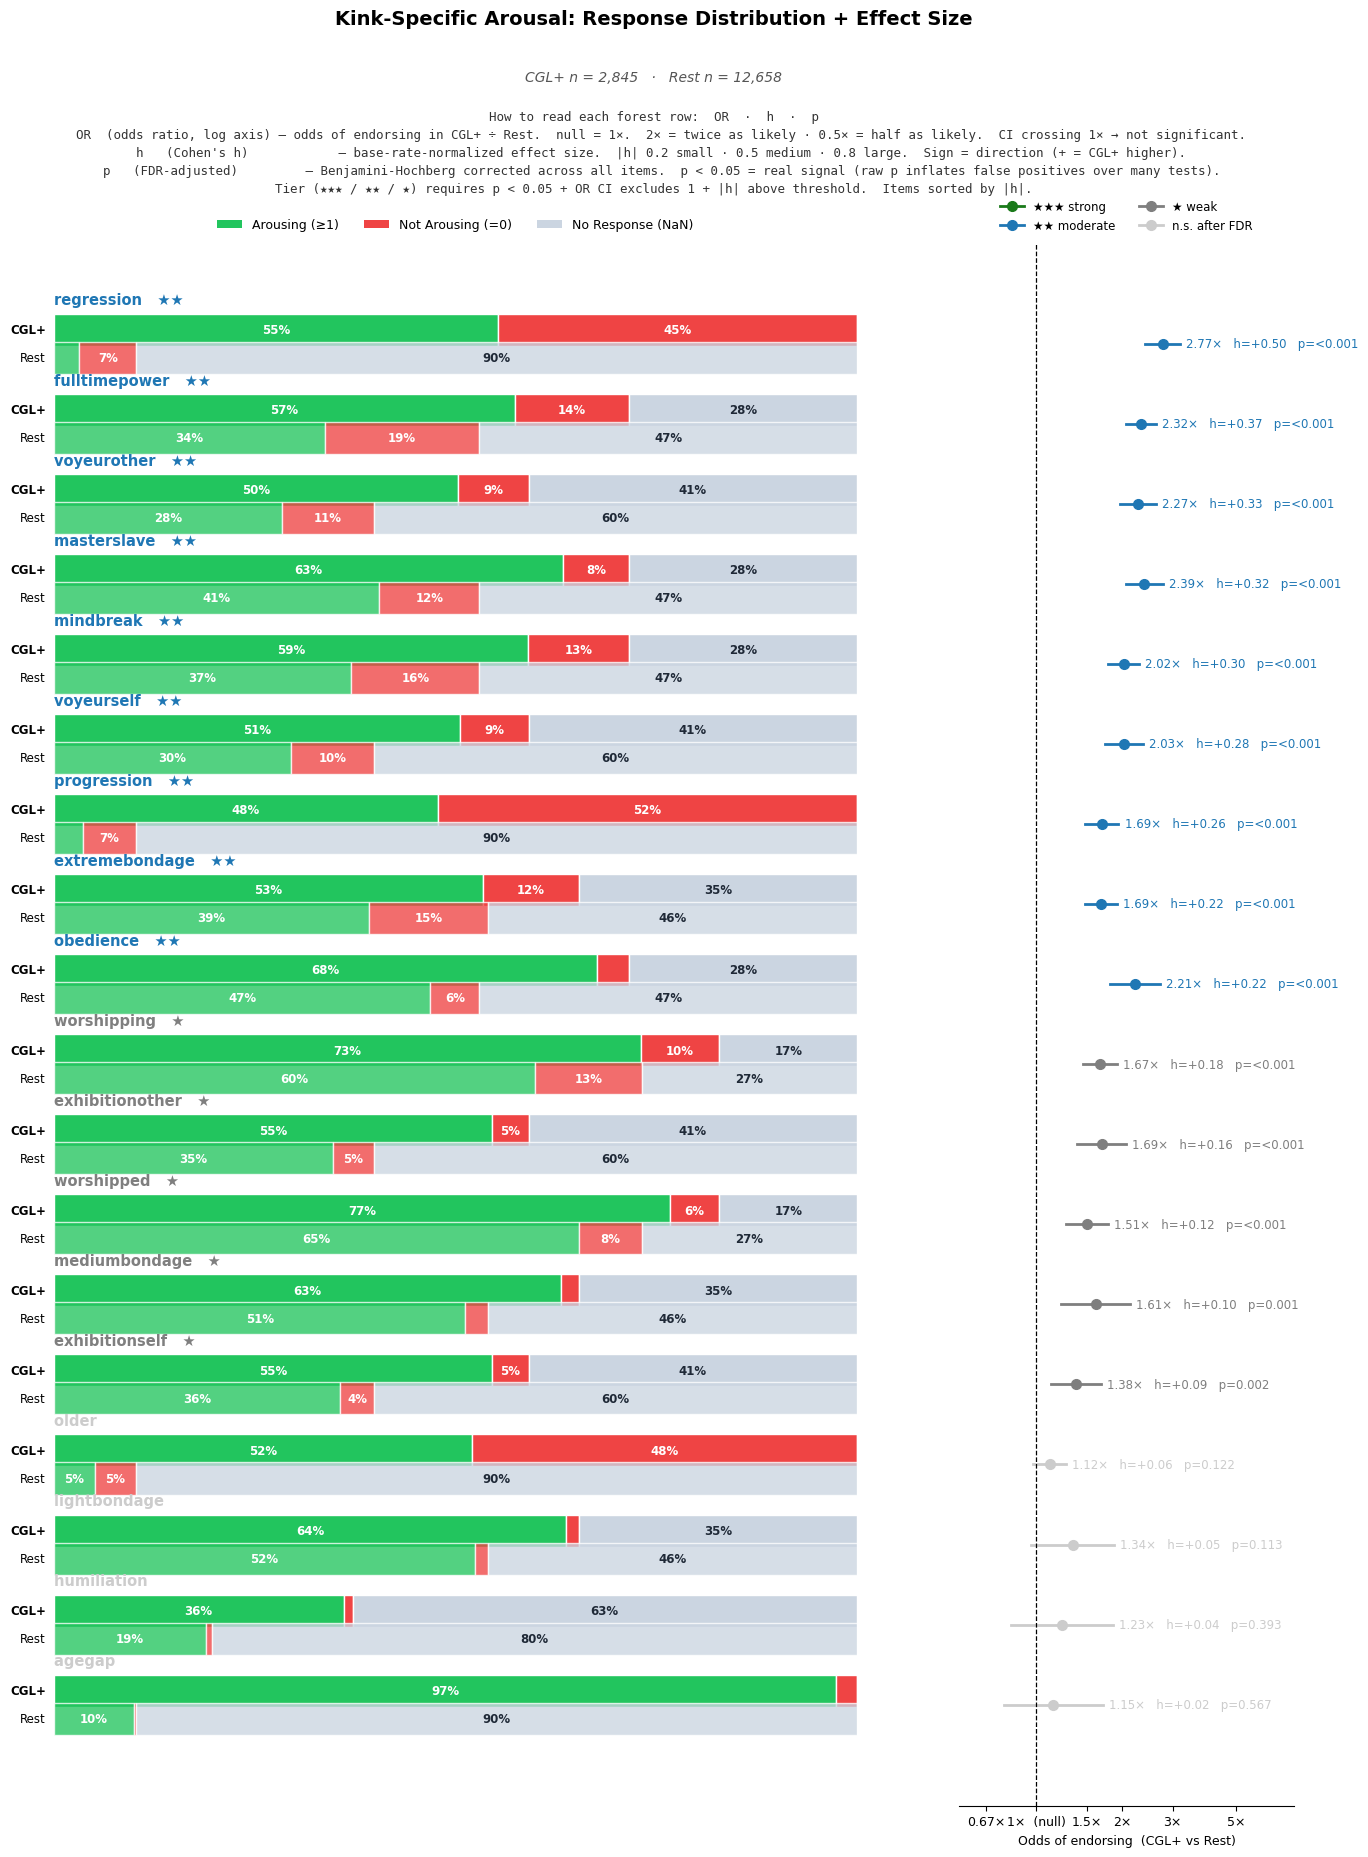

In [154]:
# === Dual-panel: stacked bars (Yes/No/NaN) + forest plot (OR with CI) ===
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, FixedFormatter

TIER_COLORS = {"strong": "#1a7a1a", "moderate": "#1f77b4",
               "weak": "#7f7f7f", "ns": "#cccccc"}
TIER_BADGE  = {"strong": "★★★", "moderate": "★★", "weak": "★", "ns": ""}
TIER_LABEL  = {"strong": "★★★ strong", "moderate": "★★ moderate",
               "weak": "★ weak", "ns": "n.s. after FDR"}

# Compact caption rendered under the chart title (plain text so it stays with the figure on export).
INTERP_CAPTION = (
    "How to read each forest row:  OR  ·  h  ·  p\n"
    "  OR  (odds ratio, log axis) — odds of endorsing in CGL+ ÷ Rest.  null = 1×.  "
    "2× = twice as likely · 0.5× = half as likely.  CI crossing 1× → not significant.\n"
    "  h   (Cohen's h)            — base-rate-normalized effect size.  "
    "|h| 0.2 small · 0.5 medium · 0.8 large.  Sign = direction (+ = CGL+ higher).\n"
    "  p   (FDR-adjusted)         — Benjamini-Hochberg corrected across all items.  "
    "p < 0.05 = real signal (raw p inflates false positives over many tests).\n"
    "Tier (★★★ / ★★ / ★) requires p < 0.05 + OR CI excludes 1 + |h| above threshold.  "
    "Items sorted by |h|."
)





def _fmt_p(p):
    """Decimal p-value: 3 dp when readable, '<0.001' for very small values."""
    if p is None or (isinstance(p, float) and (p != p)):
        return "n/a"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

def _label_tier(row):
    """Stricter than the `signal` column: also requires OR CI to exclude 1 and
    splits strong/moderate at |h|=0.5 so the top tier matches Cohen's medium+ convention."""
    sig = row["p_fdr"] < 0.05
    ci_clean = (row["or_ci_lo"] > 1) or (row["or_ci_hi"] < 1)
    m = abs(row["cohens_h"])
    if sig and ci_clean and m >= 0.5: return "strong"
    if sig and ci_clean and m >= 0.2: return "moderate"
    if sig and ci_clean:              return "weak"
    return "ns"


def _build_rates_from_raw(df, var_cols, group_col="cgl_flag", group_pos="True"):
    """Yes / No / NaN as fractions of each group's total (denominator includes NaN)."""
    pos_mask = df[group_col].astype(str) == str(group_pos)
    n_pos, n_rest = int(pos_mask.sum()), int((~pos_mask).sum())
    rows = []
    for it in var_cols:
        x = df[it]
        rows.append(dict(
            variable=it,
            pos_yes =((x >= 1) &  pos_mask).sum() / n_pos,
            pos_no  =((x == 0) &  pos_mask).sum() / n_pos,
            pos_nan = (x.isna()  &  pos_mask).sum() / n_pos,
            rest_yes=((x >= 1) & ~pos_mask).sum() / n_rest,
            rest_no =((x == 0) & ~pos_mask).sum() / n_rest,
            rest_nan= (x.isna()  & ~pos_mask).sum() / n_rest,
        ))
    return pd.DataFrame(rows).set_index("variable"), n_pos, n_rest


def _or_axis_ticks(or_min, or_max):
    """Pick a clean set of OR ticks within [or_min, or_max] using "×" labels.
    Always includes 1 (null). Log-spaced anchors below and above 1."""
    candidates = [0.2, 0.33, 0.5, 0.67, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0, 20.0]
    ticks = [t for t in candidates if or_min <= t <= or_max]
    if 1.0 not in ticks and or_min <= 1.0 <= or_max:
        ticks.append(1.0); ticks.sort()
    def fmt(t):
        if t == 1.0:        return "1×  (null)"
        if t >= 1.0:        return f"{t:g}×"
        return f"{t:.2f}×".rstrip("0").rstrip(".") + "×" if False else f"{t:g}×"
    return ticks, [fmt(t) for t in ticks]


def plot_kink_dual_panel(df, stats_df, var_cols=None, group_col="cgl_flag",
                         group_pos="True", pos_label="CGL+", rest_label="Rest",
                         sort_by="cohens_h", top_n=None,
                         title="Kink-Specific Arousal: Response Distribution + Effect Size"):
    """Left: stacked bars (Yes/No/NaN) per group, with % labels on every wide segment.
    Right: forest plot of OR on log scale with 95% CI. Items sorted by |sort_by|."""
    s = stats_df.copy()
    if "variable" in s.columns:
        s = s.set_index("variable")
    if var_cols is not None:
        s = s.loc[[c for c in var_cols if c in s.index]]
    s["tier"] = s.apply(_label_tier, axis=1)
    s = s.reindex(s[sort_by].abs().sort_values(ascending=False).index)
    if top_n: s = s.head(top_n)

    rates, n_pos, n_rest = _build_rates_from_raw(df, s.index.tolist(), group_col, group_pos)

    n = len(s)
    # Extra top padding so the caption fits between title and chart
    fig = plt.figure(figsize=(16, 0.95 * n + 3.2))
    gs = gridspec.GridSpec(1, 2, width_ratios=[2.4, 1.0], wspace=0.18)
    axL, axR = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    C_YES, C_NO, C_NAN = "#22c55e", "#ef4444", "#cbd5e1"
    MIN_LABEL_FRAC = 0.04

    def _put_pct_label(ax, x_center, y, frac, on_dark=True):
        if frac < MIN_LABEL_FRAC:
            return
        ax.text(x_center, y, f"{frac*100:.0f}%",
                ha="center", va="center", fontsize=8.5, fontweight="bold",
                color="white" if on_dark else "#1f2937")

    for i, k in enumerate(s.index):
        row = s.loc[k]
        c_tier = TIER_COLORS[row["tier"]]
        y_top, y_bot = i * 2 + 0.4, i * 2 + 1.1

        for y, prefix, alpha in [(y_top, "pos", 1.0), (y_bot, "rest", 0.78)]:
            yes  = rates.loc[k, f"{prefix}_yes"]
            no_  = rates.loc[k, f"{prefix}_no"]
            nan_ = rates.loc[k, f"{prefix}_nan"]
            axL.barh(y, yes, color=C_YES, alpha=alpha, edgecolor="white")
            axL.barh(y, no_, left=yes, color=C_NO, alpha=alpha, edgecolor="white")
            axL.barh(y, nan_, left=yes + no_, color=C_NAN, alpha=alpha, edgecolor="white")
            _put_pct_label(axL, yes / 2, y, yes, on_dark=True)
            _put_pct_label(axL, yes + no_ / 2, y, no_, on_dark=True)
            _put_pct_label(axL, yes + no_ + nan_ / 2, y, nan_, on_dark=False)

        axL.text(-0.01, y_top, pos_label,  ha="right", va="center", fontsize=8.5, fontweight="bold")
        axL.text(-0.01, y_bot, rest_label, ha="right", va="center", fontsize=8.5)
        axL.text(0, y_top - 0.55, f"{k}   {TIER_BADGE[row['tier']]}",
                 ha="left", va="bottom", fontsize=10.5, fontweight="bold", color=c_tier)

        # Forest: dot + CI bar
        y_mid = (y_top + y_bot) / 2
        axR.plot([row["or_ci_lo"], row["or_ci_hi"]], [y_mid, y_mid], color=c_tier, lw=2)
        axR.plot(row["odds_ratio"], y_mid, "o", color=c_tier, ms=7)
        # Row annotation: friendlier than "OR=2.77 h=+0.50 p=1e-46"
        axR.text(row["or_ci_hi"] * 1.05, y_mid,
                 f"{row['odds_ratio']:.2f}×   h={row['cohens_h']:+.2f}   p={_fmt_p(row['p_fdr'])}",
                 va="center", fontsize=8.5, color=c_tier)

    # Left-panel cosmetics: no x-axis
    axL.set_xlim(0, 1); axL.invert_yaxis(); axL.set_yticks([])
    axL.set_xticks([])
    axL.spines[["top", "right", "left", "bottom"]].set_visible(False)

    # Right-panel: log scale with clean × ticks at meaningful multipliers
    axR.set_xscale("log"); axR.axvline(1, color="black", lw=0.9, ls="--")
    axR.set_ylim(axL.get_ylim()); axR.set_yticks([])
    or_lo_lim = max(0.1, s["or_ci_lo"].min() * 0.7)
    or_hi_lim = s["or_ci_hi"].max() * 2.5
    axR.set_xlim(or_lo_lim, or_hi_lim)
    ticks, labels = _or_axis_ticks(or_lo_lim, or_hi_lim)
    axR.xaxis.set_major_locator(FixedLocator(ticks))
    axR.xaxis.set_major_formatter(FixedFormatter(labels))
    # Suppress matplotlib's automatic minor ticks (the messy 0.2-spaced ones on a log axis)
    axR.xaxis.set_minor_locator(FixedLocator([]))
    axR.tick_params(axis="x", labelsize=9)
    axR.set_xlabel(f"Odds of endorsing  ({pos_label} vs {rest_label})", fontsize=9)
    axR.spines[["top", "right", "left"]].set_visible(False)

    # Header: title + sample sizes + caption, all stacked at the top
    fig.suptitle(title, fontsize=14, fontweight="bold", y=0.995)
    fig.text(0.5, 0.965,
             f"{pos_label} n = {n_pos:,}   ·   {rest_label} n = {n_rest:,}",
             ha="center", va="top", fontsize=10, style="italic", color="#555")
    fig.text(0.5, 0.945, INTERP_CAPTION,
             ha="center", va="top", fontsize=9, color="#333", linespacing=1.5,
             family="monospace")

    # Legends sit below the caption, above the chart
    response_handles = [
        Patch(facecolor=C_YES, label="Arousing (≥1)"),
        Patch(facecolor=C_NO,  label="Not Arousing (=0)"),
        Patch(facecolor=C_NAN, label="No Response (NaN)"),
    ]
    axL.legend(handles=response_handles, loc="lower center",
               bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False, fontsize=9)

    tier_handles = [
        Line2D([0], [0], marker="o", color=TIER_COLORS[t], lw=2, ms=7,
               label=TIER_LABEL[t])
        for t in ["strong", "moderate", "weak", "ns"]
    ]
    axR.legend(handles=tier_handles, loc="lower center",
               bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, fontsize=8.5)

    # Leave room for the suptitle + sample size + caption block
    plt.tight_layout(rect=[0, 0, 1, 0.86])
    return fig


plot_kink_dual_panel(nsfw_df, binary_df, var_cols=kink_arousal_fields)
plt.show()


### Missingness audit: response-rate gap between groups

NaN means "did not answer" — it is NOT the same as 0 ("answered: not arousing"),
so we never impute. The binary endorsement test above drops NaN per item, which
makes endorsement % *conditional on responding*. If response rates differ between
CGL+ and Rest, the OR can be biased even when the underlying preferences are
identical.

This cell quantifies that risk per item: NaN rate by group, the response-rate
gap in percentage points, and the count of usable rows entering each 2×2 test.
A large gap doesn't invalidate the finding for that item — it just means the
finding is "among respondents", not "in the population".


In [155]:
# === Missingness audit: how much NaN per item, per group ===
def missingness_audit(df, var_cols, group_col="cgl_flag", group_pos="True",
                      pos_label="CGL+", rest_label="Rest"):
    pos_mask = df[group_col].astype(str) == str(group_pos)
    n_pos, n_rest = int(pos_mask.sum()), int((~pos_mask).sum())

    rows = []
    for col in var_cols:
        nan_pos  = df.loc[pos_mask, col].isna().sum()
        nan_rest = df.loc[~pos_mask, col].isna().sum()
        pct_nan_pos  = nan_pos / n_pos * 100
        pct_nan_rest = nan_rest / n_rest * 100
        rows.append({
            "variable": col,
            f"{pos_label}_nan_pct":  round(pct_nan_pos, 1),
            f"{rest_label}_nan_pct": round(pct_nan_rest, 1),
            "nan_gap_pp":            round(pct_nan_pos - pct_nan_rest, 1),
            f"{pos_label}_n_resp":   n_pos - int(nan_pos),
            f"{rest_label}_n_resp":  n_rest - int(nan_rest),
        })

    out = pd.DataFrame(rows)
    out = out.reindex(out["nan_gap_pp"].abs().sort_values(ascending=False).index)
    return out.reset_index(drop=True)


miss = missingness_audit(nsfw_df, kink_arousal_fields)
print("Per-item NaN rate by group (sorted by |gap|):")
print(miss.to_string(index=False))

avg_pos_nan  = miss["CGL+_nan_pct"].mean()
avg_rest_nan = miss["Rest_nan_pct"].mean()
print(
    f"\nMean NaN rate across the {len(miss)} items: "
    f"CGL+ = {avg_pos_nan:.1f}%   Rest = {avg_rest_nan:.1f}%   "
    f"gap = {avg_pos_nan - avg_rest_nan:+.1f}pp"
)
print(
    "Interpretation: Rest skips items more often than CGL+. "
    "Endorsement % above are conditional on responding, so leans for items "
    "with a large NaN gap should be read as 'among those who answered'."
)


Per-item NaN rate by group (sorted by |gap|):
       variable  CGL+_nan_pct  Rest_nan_pct  nan_gap_pp  CGL+_n_resp  Rest_n_resp
    progression           0.0          89.8       -89.8         2845         1295
     regression           0.0          89.8       -89.8         2845         1295
         agegap           0.0          89.8       -89.8         2845         1296
          older           0.0          89.8       -89.8         2845         1296
     voyeurself          40.8          60.2       -19.3         1683         5040
    voyeurother          40.8          60.2       -19.3         1683         5040
 exhibitionself          40.8          60.2       -19.3         1683         5040
exhibitionother          40.8          60.2       -19.3         1683         5040
      mindbreak          28.4          47.0       -18.6         2036         6707
      obedience          28.4          47.0       -18.6         2036         6707
  fulltimepower          28.4          47.0       -1

In [156]:
# === Filter slices ===
def _show_bin(name, df_):
    print(f"\n--- {name}  (n={len(df_)}) ---")
    if len(df_) == 0:
        print("  (no fields matched)")
        return
    cols = ["variable", "pct_endorse_pos", "pct_endorse_rest", "endorse_gap_pp",
            "cohens_h", "odds_ratio", "or_ci_lo", "or_ci_hi", "p_fdr", "signal"]
    print(df_[cols].to_string(index=False))


_show_bin("Strong signals (|h| ≥ 0.20, FDR p < 0.05)",
          filter_binary_results(binary_df, signal="strong"))

_show_bin("CGL+ over-endorses (top 8 by |h|)",
          filter_binary_results(binary_df, direction="pos_stronger", top_n=8))

_show_bin("CGL+ under-endorses (top 8 by |h|)",
          filter_binary_results(binary_df, direction="pos_weaker", top_n=8))

_show_bin("Non-significant after FDR",
          binary_df[binary_df["p_fdr"] >= 0.05])



--- Strong signals (|h| ≥ 0.20, FDR p < 0.05)  (n=9) ---
      variable  pct_endorse_pos  pct_endorse_rest  endorse_gap_pp  cohens_h  odds_ratio  or_ci_lo  or_ci_hi        p_fdr signal
    regression            55.36             30.97           24.40     0.498       2.765     2.406     3.177 1.284112e-46 strong
 fulltimepower            80.26             63.68           16.58     0.373       2.318     2.056     2.614 2.338483e-43 strong
   voyeurother            84.97             71.37           13.60     0.333       2.267     1.958     2.626 5.113894e-28 strong
   masterslave            88.61             76.50           12.10     0.323       2.388     2.060     2.769 3.011545e-31 strong
     mindbreak            82.47             69.91           12.55     0.297       2.024     1.785     2.295 4.255441e-28 strong
    voyeurself            85.38             74.23           11.16     0.280       2.028     1.747     2.355 1.863064e-20 strong
   progression            47.84             35

## Phase 1 Summary: Does CGL predict NSFW preferences?

**Comparison framework:** CGL+ vs Rest (CGL- + Unknown combined as the baseline kink-survey population)

**Key findings to look for:**

- **Acts**: If most gaps are <3pp, acts are too universal to discriminate CGL. If gaps >5pp on specific acts (e.g., creampies, certain positions), that's a signal.
- **Common preferences**: Most likely to show meaningful gaps. Look for clusters:
  - CGL+ over-indexes on `common_gentleness`, `common_power dynamics`, `common_humiliation` → suggests a distinct preference constellation
  - CGL+ under-indexes on `common_sadomasochism`, `common_brutal/violent` → might suggest CGL folks prefer less extreme power exchange
- **Uncommon preferences**: CGL respondents may actively *avoid* certain extreme acts. Negative gaps here would be the story.
- **Positions**: Likely similar to acts — too universal. But if there's a pattern (e.g., CGL avoids certain positions), that's notable.

**Interpretation thresholds:**
- |gap| > 5pp + Cohen's h > 0.20 → likely meaningful signal
- |gap| 3–5pp → possible signal, but modest
- |gap| < 3pp → probably noise; too universal to discriminate CGL

**Next step:**
- If common preferences show consistent >5pp gaps with moderate Cohen's h, proceed to **Phase 2** (interaction analysis with D/S preference to isolate the CGL signal).
- If gaps are <3pp across the board, NSFW is too granular to add distinct insights. The story is already captured in "CGL respondents have broader role interests and tend toward caretaker/caretakee dynamics."

**Note on Unknown:** The "Rest" category combines CGL- (explicit non-CGL) and Unknown (no response). This combined baseline represents "the broader kink-survey respondent population" and is more interpretable than treating Unknown as a separate group.

In [157]:
# Generate findings summary markdown file if SHOW_SUMMARY is True
if SHOW_SUMMARY:
    summary_content = """
# CGL EDA Findings

## Overview
This document contains the key findings from the exploratory data analysis of the CGL dataset.

## Key Metrics
- Total records: {}
- CGL participants: {}
- Non-CGL participants: {}
""".format(
        len(df),
        (df['cgl_flag'] == True).sum(),
        (df['cgl_flag'] == False).sum()
    )
    
    with open('1a_CGL_EDA_Findings.md', 'w') as f:
        f.write(summary_content)
    print('✓ Findings summary saved to 1a_CGL_EDA_Findings.md')
else:
    print('Summary generation skipped (SHOW_SUMMARY = False)')

Summary generation skipped (SHOW_SUMMARY = False)
